# GreenSQL — TPC-H query timing & energy

Pulls the benchmark CSVs from `user01@192.168.1.42` over SSH/SFTP and
analyses them. Queries now run in **batches** — `batchnum` copies inside a
single `psql` call — which is what lets us separate one-time (cold-cache)
cost from steady-state (warm) cost:

| File | Contents |
|---|---|
| `query_timing_tpch.csv`  | one row per **batch** — wall time, energy, client overhead (`phase`, `batch_index`, `batchnum`) |
| `query_samples_tpch.csv` | one row per **copy** — server planning/execution, buffers, and workload counters |
| `query_slope_tpch.csv`   | one row per query — small-vs-large batch linear fit: `slope` (warm marginal cost) and `intercept` (fixed/cold cost) |
| `query_catalog_tpch.csv` | one row per relation — table/index sizes |

Everything is reported as a **per-copy average** (per single execution), only
the `measured` phase is used, and negative RAPL readings (counter overflow)
are treated as N/A. All files are **cached locally** on every successful
fetch, so the notebook still runs when the server is unreachable.

## 0. Dependencies

In [1]:
pip install paramiko pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 KB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.9 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 82.4 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 KB 24.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 KB 43.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 59.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.5 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 46.3 MB/s et

## 1. Fetch the CSVs over SSH (with a local cache)

Each **database size** is a separate file pair on the server —
`query_timing_tpch.csv`, `query_timing_tpch2.csv` (2 GB),
`query_timing_tpch5.csv` (5 GB) and their `query_samples_*` counterparts.
Every complete pair matching that pattern is discovered and loaded
automatically, and each row is tagged with the size it came from, so a new
size file needs no code change.

The host occasionally refuses a connection, so the fetch retries a few
times. The cache makes that failure non-fatal:

1. try SSH (`RETRIES` attempts);
2. **on success** → overwrite `CACHE_DIR/*.csv` with the fresh copies and
   use them;
3. **on failure** → fall back to whatever complete pairs are cached and
   report how old they are.

The cache is only written once *every* file has downloaded, so a failure
half-way through can never leave a mismatched set on disk.

**`RUN_IDS`** (top of the next cell) selects which benchmark runs to
analyse — a list of run ids, or `None` for all of them. Ids that are not
in the CSVs yet are reported and skipped. Whether the selected runs are
then pooled or kept apart is decided in section 1b.

In [1]:
import io
import re
import time
from pathlib import Path

import paramiko
import numpy as np
import pandas as pd

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_DIR = "/home/user01/GreenSQL"
# the CSVs may sit at the top level or under logs/; search both and let the
# later directory (logs/) win when a filename appears in more than one.
REMOTE_DIRS = [REMOTE_DIR, REMOTE_DIR + "/logs"]

RETRIES = 5
CACHE_DIR = Path("RealDataCSV/logs")        # next to this notebook

# Datasets are one file pair per database size, named by suffix:
#   query_timing_tpch.csv / query_timing_tpch2.csv / query_timing_tpch5.csv
# Any pair matching this pattern is discovered automatically.
DATASET_RE = re.compile(r"^query_(timing|samples)_(estat|warehouse)\.csv$")

# Database size behind each suffix. The plain 'tpch' file predates the
# sized ones; adjust if its real size is not 1 GB.
#SIZE_LABELS = {"tpch": "1 GB", "tpch2": "2 GB", "tpch5": "5 GB"}


# def size_label(tag):
#     if tag in SIZE_LABELS:
#         return SIZE_LABELS[tag]
#     digits = tag[len("tpch"):]
#     return f"{digits} GB" if digits.isdigit() else tag


# the per-relation catalog (table/index sizes), one file per dataset size
CATALOG_RE = re.compile(r"(^query_catalog_(estat|warehouse)\.csv$)") 
# the batch-slope file (caching / amortisation fits), one per dataset size
SLOPE_RE = re.compile(r"^query_slope_(estat|warehouse)\.csv$")
# the COLD file: one row per single cold execution (no batching). Warm =
# every other file above; cold lives only in these query_cold_* files.
COLD_RE = re.compile(r"^query_cold_(estat|warehouse)\.csv$")
# the INDEXED cold variant: same cold format, but with the extra indexes built
# (index_schema_*.sql). Same shape, different INDEX STATUS.
#COLD_IDX_RE = re.compile(r"^query_cold_(tpch\d*)_idx\.csv$")


def discover(names):
    """filename list -> {tag: {'timing': fn, 'samples': fn}} for complete pairs."""
    found = {}
    for fn in names:
        m = DATASET_RE.match(fn)
        if m:
            found.setdefault(m.group(2), {})[m.group(1)] = fn
    return {t: d for t, d in sorted(found.items())
            if {"timing", "samples"} <= set(d)}


def discover_catalog(names):
    """filename list -> {tag: catalog_fn} (optional, may be empty)."""
    return {m.group(1): fn for fn in names
            for m in [CATALOG_RE.match(fn)] if m}


def discover_slope(names):
    """filename list -> {tag: slope_fn} (optional, may be empty)."""
    return {m.group(1): fn for fn in names
            for m in [SLOPE_RE.match(fn)] if m}


def discover_cold(names):
    """filename list -> {tag: cold_fn} (optional, may be empty)."""
    return {m.group(1): fn for fn in names
            for m in [COLD_RE.match(fn)] if m}


# def discover_cold_idx(names):
#     """filename list -> {tag: indexed_cold_fn} (optional, may be empty)."""
#     return {m.group(1): fn for fn in names
#             for m in [COLD_IDX_RE.match(fn)] if m}

# ---------------------------------------------------------------------
# Which benchmark runs to analyse. Every run gets a fresh id, so the
# default is None = analyse every run present in the CSVs. Pin a list of
# run ids here to compare only specific runs.
# ---------------------------------------------------------------------
RUN_IDS = None


def fetch_over_ssh():
    """Discover and download every dataset pair. Raises if all attempts fail."""
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            client = paramiko.SSHClient()
            client.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            client.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                           timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with client.open_sftp() as sftp:
                    remote = {}                 # filename -> full remote path
                    for d in REMOTE_DIRS:
                        try:
                            for fn in sftp.listdir(d):
                                remote[fn] = f"{d}/{fn}"
                        except IOError:
                            pass                # dir may not exist; skip
                    names = list(remote)
                    sets = discover(names)
                    if not sets:
                        raise RuntimeError(f"no dataset pairs in {REMOTE_DIRS}")
                    cats = discover_catalog(names)
                    slopes = discover_slope(names)
                    colds = discover_cold(names)
                    #colds_idx = discover_cold_idx(names)
                    blobs = {}
                    wanted = [fn for pair in sets.values() for fn in pair.values()]
                    wanted += list(cats.values()) + list(slopes.values())
                    wanted += list(colds.values()) + list(colds_idx.values())
                    for fn in wanted:
                        blobs[fn] = sftp.open(remote[fn]).read()
                    return sets, cats, slopes, colds, blobs # removed cold_idx
            finally:
                client.close()
        except Exception as exc:                      # transient network issue
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load_csvs():
    """Fetch from the server and refresh the cache; fall back to the cache."""
    try:
        sets, cats, slopes, colds, blobs = fetch_over_ssh()
    except Exception as exc:
        names = [p.name for p in CACHE_DIR.glob("*.csv")] if CACHE_DIR.exists() else []
        cached = discover(names)
        if not cached:
            raise RuntimeError(
                f"{exc}\nNo usable local cache in '{CACHE_DIR}/' - "
                f"cannot continue.") from exc
        cats = discover_catalog(names)
        slopes = discover_slope(names)
        colds = discover_cold(names)
        #colds_idx = discover_cold_idx(names)
        files = [CACHE_DIR / fn for p in cached.values() for fn in p.values()]
        files += [CACHE_DIR / fn for fn in cats.values()]
        files += [CACHE_DIR / fn for fn in slopes.values()]
        files += [CACHE_DIR / fn for fn in colds.values()]
        #files += [CACHE_DIR / fn for fn in colds_idx.values()]
        age_h = (time.time() - max(f.stat().st_mtime for f in files)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to the local cache in '{CACHE_DIR}/' "
              f"({age_h:.1f} h old) - data may be stale.\n")
        blobs = {f.name: f.read_bytes() for f in files}
        return cached, cats, slopes, colds, blobs, "cache"

    # every download succeeded -> refresh the cache
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for name, rawbytes in blobs.items():
        (CACHE_DIR / name).write_bytes(rawbytes)
    print(f"Fetched from {SSH_HOST}; local cache in '{CACHE_DIR}/' updated.")
    return sets, cats, slopes, colds, blobs, "server"


def filter_runs(df, label):
    """Keep only the requested run ids (RUN_IDS = None keeps everything)."""
    if RUN_IDS is None:
        return df
    kept = df[df["run_id"].isin(RUN_IDS)].copy()
    print(f"  {label:<8}: {len(kept):>5}/{len(df):<5} rows kept")
    return kept


DATASETS, CATALOGS, SLOPES, COLDS, blobs, SOURCE = load_csvs()


def build(kind):
    """Concatenate one kind ('timing'/'samples') across all dataset sizes."""
    parts = []
    for tag, pair in DATASETS.items():
        df = pd.read_csv(io.BytesIO(blobs[pair[kind]]))
        df["dataset"] = tag
        #df["db_size"] = size_label(tag)
        parts.append(df)
    return pd.concat(parts, ignore_index=True)


def build_aux(mapping):
    """Concatenate an auxiliary file set (catalog/slope), or None if empty."""
    if not mapping:
        return None
    parts = []
    for tag, fn in mapping.items():
        df = pd.read_csv(io.BytesIO(blobs[fn]))
        df["dataset"] = tag
        #df["db_size"] = size_label(tag)
        parts.append(df)
    return pd.concat(parts, ignore_index=True)


timing_all = build("timing")
samples_all = build("samples")
catalog_all = build_aux(CATALOGS)
slope_all = build_aux(SLOPES)
cold_all = build_aux(COLDS)          # cold runs, base schema (no extra indexes)
#cold_idx_all = build_aux(COLDS_IDX)  # cold runs with extra indexes built

print(f"source : {SOURCE}")
print(f"datasets found ({len(DATASETS)}):")
for tag, pair in DATASETS.items():
    n = int((timing_all["dataset"] == tag).sum())
    print(f"   {tag:<10} {n:>5} timing rows  ({pair['timing']})")
print(f"timing : {timing_all.shape[0]:>5} rows x {timing_all.shape[1]} cols")
print(f"samples: {samples_all.shape[0]:>5} rows x {samples_all.shape[1]} cols")
if catalog_all is not None:
    print(f"catalog: {catalog_all.shape[0]:>5} rows x {catalog_all.shape[1]} cols "
          f"({', '.join(CATALOGS.values())})")
else:
    print("catalog: none found")
if slope_all is not None:
    print(f"slope  : {slope_all.shape[0]:>5} rows x {slope_all.shape[1]} cols "
          f"({', '.join(SLOPES.values())})")
else:
    print("slope  : none found")
if cold_all is not None:
    print(f"COLD   : {cold_all.shape[0]:>5} rows x {cold_all.shape[1]} cols "
          f"({', '.join(COLDS.values())})  <- cold runs (base)")
else:
    print("COLD   : none found")
# if cold_idx_all is not None:
#     print(f"COLD+idx:{cold_idx_all.shape[0]:>5} rows x {cold_idx_all.shape[1]} cols "
#           f"({', '.join(COLDS_IDX.values())})  <- cold runs (indexed)")
# else:
#     print("COLD+idx: none found")

available = sorted(set(timing_all["run_id"]) | set(samples_all["run_id"]))
print(f"\nrun ids present in the data ({len(available)}):")
for rid in available:
    sub = timing_all[timing_all["run_id"] == rid]
    n_q = sub["query"].nunique()
    when = sub["timestamp_utc"].min()[:10] if len(sub) else "-"
    ds = "/".join(sorted(set(sub["dataset"].astype(str))))
    #sz = "/".join(sorted(set(sub["db_size"].astype(str))))
    mark = "*" if RUN_IDS is None or rid in RUN_IDS else " "
    print(f"  {mark} {rid}  {n_q:>4} queries  {when}  {ds}")

if RUN_IDS is not None:
    print(f"\nRUN_IDS filter -> {RUN_IDS}")
    missing = [r for r in RUN_IDS if r not in available]
    if missing:
        print(f"  !! not present in the data (ignored): {missing}")

timing = filter_runs(timing_all, "timing")
samples = filter_runs(samples_all, "samples")

if timing.empty:
    raise ValueError(
        f"RUN_IDS {RUN_IDS} matched no rows. Available: {available}")

print(f"\nanalysing {timing['run_id'].nunique()} run(s), "
      f"{len(timing)} timed queries")
samples.head(3)

  attempt 1/5 failed: TimeoutError
  attempt 2/5 failed: TimeoutError
  attempt 3/5 failed: TimeoutError
  attempt 4/5 failed: TimeoutError
  attempt 5/5 failed: TimeoutError

!! SSH failed after 5 attempts: timed out
!! Falling back to the local cache in 'RealDataCSV/logs/' (140.6 h old) - data may be stale.

source : cache
datasets found (2):
   estat         55 timing rows  (query_timing_estat.csv)
   warehouse     85 timing rows  (query_timing_warehouse.csv)
timing :   140 rows x 22 cols
samples:   476 rows x 28 cols
catalog:    34 rows x 13 cols (query_catalog_warehouse.csv, query_catalog_estat.csv)
slope  :    28 rows x 21 cols (query_slope_estat.csv, query_slope_warehouse.csv)
COLD   :    95 rows x 34 cols (query_cold_warehouse.csv, query_cold_estat.csv)  <- cold runs (base)

run ids present in the data (2):
  * E10DBED08E2A894C    11 queries  2026-08-10  estat
  * F0835FB40824C98A    17 queries  2026-08-10  warehouse

analysing 2 run(s), 140 timed queries


,timestamp_utc,run_id,pg_version,query,phase,batch_index,copy_index,batchnum,runs,server_planning_ms,...,workers_launched,relations,shared_hit_blks,shared_read_blks,shared_dirtied_blks,shared_written_blks,temp_read_blks,temp_written_blks,failed,dataset
0,2026-08-10T15:15:02Z,E10DBED08E2A894C,16.14,queries/estat/01_scan_access/index_scan.sql,warmup,1,1,1,3,2.665,...,0,fact_capital_stock,55798,6239432,0,0,0,0,0,estat
1,2026-08-10T15:15:19Z,E10DBED08E2A894C,16.14,queries/estat/01_scan_access/index_scan.sql,warmup,2,1,1,3,0.405,...,0,fact_capital_stock,55888,6239342,0,0,0,0,0,estat
2,2026-08-10T15:16:41Z,E10DBED08E2A894C,16.14,queries/estat/01_scan_access/index_scan.sql,measured,1,1,5,3,0.416,...,0,fact_capital_stock,55888,6239342,0,0,0,0,0,estat


## 1b. Cohorts — which runs may be pooled?

Two runs may only be averaged together if they measured the *same thing*.
Two attributes decide that:

| attribute | source |
|---|---|
| **Postgres version** | `pg_version` column |
| **database size** | which dataset file the row came from (`tpch` / `tpch2` / `tpch5`) |

* If **both match** across the selected run ids, the runs are pooled into
  one cohort and analysed together — even if they used a different number
  of runs (those simply add to the pooled batch count).
* If **either differs**, the runs are kept apart and every label carries the
  attribute(s) that differ — so a Postgres 16 result is never averaged
  into a Postgres 18 one.

Everything downstream is keyed on `(cohort, query)`, so pooling and
separation both fall out of that single decision.

In [2]:
# cohorts are split only by dataset (estat v warehouse)
# there is no pg version and no scaling, so these attributes have been removed.
ATTR_SPECS = [
    #("pg version",    "pg_version", lambda v: f"pg {v}"),
    #("database size", "db_size",    lambda v: f"{v}"),
    ("dataset", "dataset", lambda v: f"{v}"),
]
attrs = [(n, c, f) for n, c, f in ATTR_SPECS if c in timing.columns]
missing_attrs = [n for n, c, _ in ATTR_SPECS if c not in timing.columns]

# ---- profile every selected run -------------------------------------
prof = pd.DataFrame(index=sorted(timing["run_id"].unique()))
prof.index.name = "run_id"
for name, col, _ in attrs:
    vals = timing.groupby("run_id")[col].agg(lambda s: sorted(set(s.dropna())))
    bad = vals[vals.map(len) > 1]
    for rid, lst in bad.items():
        print(f"  !! run {rid} has several '{name}' values {lst}; using {lst[0]}")
    prof[name] = vals.map(lambda L: L[0] if L else None)
prof["queries"] = timing.groupby("run_id")["query"].nunique()

print("run profiles")
print(prof.to_string(), "\n")
if missing_attrs:
    print(f"!! not recorded in the CSVs, so it cannot be compared: "
          f"{missing_attrs}")
    print("   -> runs are assumed to share it; add the column to split on it.\n")

# ---- which attributes actually differ? ------------------------------
attr_names = [n for n, _, _ in attrs]
varying = [n for n in attr_names if prof[n].nunique(dropna=False) > 1]
fmt_of = {n: f for n, _, f in attrs}


def cohort_label(rid):
    if not varying:
        return "all runs"
    return " | ".join(fmt_of[n](prof.loc[rid, n]) for n in varying)


run2cohort = {rid: cohort_label(rid) for rid in prof.index}
timing["cohort"] = timing["run_id"].map(run2cohort)
samples["cohort"] = samples["run_id"].map(run2cohort)

KEY = ["cohort", "query"]
MULTI_COHORT = len(set(run2cohort.values())) > 1

if varying:
    print(f"differing attribute(s): {varying}  ->  runs are NOT pooled")
else:
    print(f"all of {attr_names} match  ->  runs are pooled into one cohort")

print("\ncohorts")
for coh in sorted(set(run2cohort.values())):
    members = [r for r, c in run2cohort.items() if c == coh]
    print(f"  {coh:<28} {len(members)} run(s): {', '.join(members)}")

run profiles
                    dataset  queries
run_id                              
E10DBED08E2A894C      estat       11
F0835FB40824C98A  warehouse       17 

differing attribute(s): ['dataset']  ->  runs are NOT pooled

cohorts
  estat                        1 run(s): E10DBED08E2A894C
  warehouse                    1 run(s): F0835FB40824C98A


## 1c. Failed queries

Every query that recorded a failure, with its Postgres version and dataset
size, and how many runs failed (split into warmup / measured batches).
These are excluded from the timing analysis in section 2.

In [3]:
if "failed" not in timing.columns:
    print("The timing CSV has no 'failed' column.")
else:
    tf = timing.copy()
    tf["failed"] = pd.to_numeric(tf["failed"], errors="coerce").fillna(0)
    fails = tf[tf["failed"] > 0].copy()
    if fails.empty:
        print("No failed queries across the analysed runs.")
    else:
        fails["sql_file"] = fails["query"].astype(str).str.split("/").str[-1]
        rep = (fails.groupby(["sql_file", "dataset"])
               .agg(failed_runs=("failed", "size"),
                    warmup=("phase", lambda s: int((s == "warmup").sum())),
                    measured=("phase", lambda s: int((s == "measured").sum())))
               .reset_index()
               .sort_values(["failed_runs", "sql_file"], ascending=[False, True]))
        print(f"{int(len(fails))} failed run(s) across "
              f"{fails['sql_file'].nunique()} quer(y/ies), "
              f"{rep[['sql_file']].drop_duplicates().shape[0]} "
              f"(query, dataset) combinations:\n")
        print(rep.to_string(index=False))

No failed queries across the analysed runs.


## 2. Timing CSV → per-copy averages

The runner now executes each query as a **batch** of `batchnum` copies
inside one `psql` call, and the timing CSV has one row per batch
(`phase`, `batch_index`). The `measured` phase runs 3 batches of 10
copies; `elapsed_sec` and `rapl_*` are for the whole batch, and
`avg_copy_elapsed_sec` is the per-copy wall time. So the per-**execution**
numbers that the old plots used become:

* `avg_time_s`  = mean over measured batches of `avg_copy_elapsed_sec`
* `avg_pkg_j`   = mean over measured batches of `rapl_pkg_j / batchnum`
* `overhead_s`  = mean of `client_overhead_sec / batchnum`

The std across the 3 measured batches gives the whiskers. A rare RAPL
overflow makes a batch's energy negative → that batch is dropped (N/A);
the remaining batches still give a value.

In [4]:
def query_group(series):
    """'queries/Core/00_baseline/x.sql' -> 'Core/00_baseline'"""
    return (series.astype(str)
            .str.replace(r"^queries/", "", regex=True)
            .str.rsplit("/", n=1).str[0])


mt = timing[timing["phase"] == "measured"].copy()
num = ["batchnum", "runs", "elapsed_sec", "avg_copy_elapsed_sec",
       "server_sum_ms", "client_overhead_sec", "client_user_cpu_sec",
       "client_sys_cpu_sec", "rapl_pkg_j", "rapl_core_j", "failed"]
for c in num:
    mt[c] = pd.to_numeric(mt[c], errors="coerce")
mt = mt[mt["failed"].fillna(0) == 0]

# reduce every batch to per-copy quantities
bn = mt["batchnum"].replace(0, np.nan)
mt["copy_time"] = mt["avg_copy_elapsed_sec"]
mt["copy_pkg"] = mt["rapl_pkg_j"] / bn
mt["copy_core"] = mt["rapl_core_j"] / bn
mt["copy_overhead"] = mt["client_overhead_sec"] / bn
mt["copy_server"] = (mt["server_sum_ms"] / 1000.0) / bn
mt["copy_user_cpu"] = mt["client_user_cpu_sec"] / bn
mt["copy_sys_cpu"] = mt["client_sys_cpu_sec"] / bn

# RAPL overflow -> drop that batch's energy (mean below skips NaN)
rapl_cols = ["copy_pkg", "copy_core"]
n_overflow = int((mt[rapl_cols] < 0).to_numpy().sum())
mt[rapl_cols] = mt[rapl_cols].mask(mt[rapl_cols] < 0)

tim = mt.groupby(KEY, as_index=False).agg(
    n_batches=("batch_index", "size"),
    n_runids=("run_id", "nunique"),
    batchnum=("batchnum", "max"),
    avg_time_s=("copy_time", "mean"),
    time_std=("copy_time", "std"),
    time_min=("copy_time", "min"),
    time_max=("copy_time", "max"),
    avg_pkg_j=("copy_pkg", "mean"),
    pkg_j_std=("copy_pkg", "std"),
    avg_core_j=("copy_core", "mean"),
    core_j_std=("copy_core", "std"),
    server_s=("copy_server", "mean"),
    overhead_s=("copy_overhead", "mean"),
    user_cpu_s=("copy_user_cpu", "mean"),
    sys_cpu_s=("copy_sys_cpu", "mean"),
)
tim["time_mean"] = tim["avg_time_s"]
tim["sql_file"] = tim["query"].astype(str).str.split("/").str[-1]
tim["group"] = query_group(tim["query"])

pooled = int((tim["n_runids"] > 1).sum())
print(f"{len(mt)} measured batches -> {len(tim)} (cohort, query) entries, "
      f"{tim['group'].nunique()} groups")
print(f"batch size (copies per measured batch): {sorted(tim['batchnum'].unique())}")
print(f"entries pooled from more than one run id: {pooled}")
print(f"RAPL-overflow batches dropped: {n_overflow}")
tim[["cohort", "sql_file", "n_batches", "avg_time_s", "avg_pkg_j",
     "server_s", "overhead_s"]].head()

84 measured batches -> 28 (cohort, query) entries, 13 groups
batch size (copies per measured batch): [np.int64(5)]
entries pooled from more than one run id: 0
RAPL-overflow batches dropped: 0


,cohort,sql_file,n_batches,avg_time_s,avg_pkg_j,server_s,overhead_s
0,estat,index_scan.sql,3,16.453911,168.470756,16.445054,0.008857
1,estat,seq_scan.sql,3,1.555944,18.290328,1.539875,0.016068
2,estat,high_selectivity.sql,3,0.013566,0.160518,0.004877,0.008689
3,estat,low_selectivity.sql,3,2.029523,24.279993,2.014183,0.015341
4,estat,large_hash.sql,3,2.905146,35.758598,2.892458,0.012688


## 3. Samples CSV → per-copy server-side details

The samples CSV now holds one row per **copy** (`copy_index`) and carries
only the *server-side* details — `server_planning_ms`,
`server_execution_ms`, the buffer/temp counters, and the workload columns
(rows/bytes processed, plan shape, relations). Wall time, client overhead
and energy live in the timing CSV (section 2).

`server_sum_ms` in the timing file is measured separately from the
per-copy `EXPLAIN` timings here and does not equal their sum, so the
server wall from timing is split into planning vs execution using the
**ratio** of these samples (section 4), which keeps the stacked bars
summing to the real elapsed time.

In [5]:
meas = samples[samples["phase"] == "measured"].copy()

srv_cols = ["server_planning_ms", "server_execution_ms",
            "shared_hit_blks", "shared_read_blks",
            "temp_read_blks", "temp_written_blks"]
work_cols = ["plan_nodes", "scan_nodes", "rows_out", "rows_processed",
             "rows_estimated", "bytes_processed", "rows_removed_filter",
             "workers_launched"]
HAS_WORKLOAD = all(c in meas.columns for c in work_cols)
for col in srv_cols + (work_cols if HAS_WORKLOAD else []):
    meas[col] = pd.to_numeric(meas[col], errors="coerce")

smp = meas.groupby(KEY).agg(
    n_copies=("copy_index", "size"),
    plan_ms=("server_planning_ms", "mean"),
    exec_ms=("server_execution_ms", "mean"),
    shared_hit=("shared_hit_blks", "mean"),
    shared_read=("shared_read_blks", "mean"),
    temp_read=("temp_read_blks", "mean"),
    temp_written=("temp_written_blks", "mean"),
)

# split of server time into planning vs execution (used in section 4)
smp["plan_ratio"] = smp["plan_ms"] / (smp["plan_ms"] + smp["exec_ms"]).replace(0, np.nan)

# workload columns (rows/bytes processed, plan shape, parallelism)
if HAS_WORKLOAD:
    wk = meas.groupby(KEY).agg(
        rows_out=("rows_out", "mean"),
        rows_processed=("rows_processed", "mean"),
        rows_estimated=("rows_estimated", "mean"),
        bytes_processed=("bytes_processed", "mean"),
        rows_removed_filter=("rows_removed_filter", "mean"),
        plan_nodes=("plan_nodes", "max"),
        scan_nodes=("scan_nodes", "max"),
        workers_launched=("workers_launched", "max"),
    )
    smp = smp.join(wk)

blks = (smp["shared_hit"] + smp["shared_read"]).replace(0, np.nan)
smp["cache_hit_pct"] = 100 * smp["shared_hit"] / blks
smp["temp_blks"] = smp["temp_read"] + smp["temp_written"]

print(f"measured copies: {len(meas)}  (warmup copies ignored: "
      f"{int((samples['phase'] == 'warmup').sum())})")
print(f"queries with measured samples: {len(smp)}")
smp[["n_copies", "plan_ms", "exec_ms", "cache_hit_pct", "temp_blks"]].head()

measured copies: 420  (warmup copies ignored: 56)
queries with measured samples: 28


n_copies   plan_ms  \
cohort query                                                                    
estat  queries/estat/01_scan_access/index_scan.sql               15  0.122667   
       queries/estat/01_scan_access/seq_scan.sql                 15  0.120600   
       queries/estat/02_filter_project/high_selectivit...        15  0.092267   
       queries/estat/02_filter_project/low_selectivity...        15  0.078933   
       queries/estat/03_join_method/large_hash.sql               15  0.217667   

                                                                exec_ms  \
cohort query                                                              
estat  queries/estat/01_scan_access/index_scan.sql         16445.054200   
       queries/estat/01_scan_access/seq_scan.sql            1539.875267   
       queries/estat/02_filter_project/high_selectivit...      4.876867   
       queries/estat/02_filter_project/low_selectivity...   2014.182600   
       queries/estat/03_join_method/large_hash.sql          2892.458333   

                                                           cache_hit_pct  \
cohort query                                                               
estat  queries/estat/01_scan_access/index_scan.sql              0.887614   
       queries/estat/01_scan_access/seq_scan.sql                9.602674   
       queries/estat/02_filter_project/high_selectivit...     100.000000   
       queries/estat/02_filter_project/low_selectivity...       9.592005   
       queries/estat/03_join_method/large_hash.sql              9.587381   

                                                           temp_blks  
cohort query                                                          
estat  queries/estat/01_scan_access/index_scan.sql               0.0  
       queries/estat/01_scan_access/seq_scan.sql                 0.0  
       queries/estat/02_filter_project/high_selectivit...        0.0  
       queries/estat/02_filter_project/low_selectivity...        0.0  
       queries/estat/03_join_method/large_hash.sql               0.0

## 4. Merge timing + samples

Timing (per-copy wall/energy/overhead) is the base; the samples aggregates
(server-time split, buffers, workload) are joined on. The server wall from
timing is split into **planning** and **execution** using the samples
ratio, so `plan_s + exec_s + overhead_s == avg_time_s` and the stacked bars
still sum to the real per-copy time.

In [6]:
data = tim.merge(smp.reset_index(), on=KEY, how="left")

# split the (real) server wall into planning vs execution by the sample
# ratio; overhead is the client side. These sum to avg_time_s.
ratio = data["plan_ratio"].fillna(0.0)
data["plan_s"] = data["server_s"] * ratio
data["exec_s"] = data["server_s"] * (1.0 - ratio)
# overhead_s already on data from timing

# run-to-run (batch-to-batch) variability, from the timing batches
data["cv_pct"] = 100 * data["time_std"] / data["avg_time_s"]
data["energy_cv_pct"] = 100 * data["pkg_j_std"] / data["avg_pkg_j"]
data["spread_pct"] = 100 * (data["time_max"] - data["time_min"]) / data["avg_time_s"]
data["n_measured"] = data["n_batches"]

# tag each entry with its dataset size and pg version (from its cohort)
#cohort_size = timing.groupby("cohort")["db_size"].first()
#cohort_pg = timing.groupby("cohort")["pg_version"].agg(
#    lambda s: sorted(set(s.dropna()))[0])
#data["db_size"] = data["cohort"].map(cohort_size)
#data["pg_version"] = data["cohort"].map(cohort_pg).astype(str)
#MULTI_SIZE = data["db_size"].nunique() > 1

# tag each entry with its dataset (estat v warehouse) from its cohort
cohort_dataset = timing.groupby("cohort")["dataset"].first()
data["dataset"] = data["cohort"].map(cohort_dataset)
MULTI_DATASET = data["dataset"].nunique() > 1

# axis label carries the cohort tag when more than one cohort is shown
data["label"] = data["sql_file"]
if MULTI_COHORT:
    data["label"] = data["sql_file"] + "  [" + data["cohort"] + "]"

have = data["avg_time_s"].notna().sum()
print(f"{have}/{len(data)} entries have measured timing data "
      f"({100*have/len(data):.1f}%)")
print()
print(data.groupby("cohort").agg(
    queries=("query", "nunique"),
    entries=("query", "size"),
    run_ids=("n_runids", "max"),
).to_string())

if MULTI_COHORT:
    shared = (data.groupby("query")["cohort"].nunique() > 1).sum()
    print(f"\nqueries present in every cohort (directly comparable): {shared}")

data[["cohort", "group", "sql_file", "avg_time_s", "plan_s", "exec_s",
      "overhead_s", "avg_pkg_j"]].head()

28/28 entries have measured timing data (100.0%)

           queries  entries  run_ids
cohort                              
estat           11       11        1
warehouse       17       17        1

queries present in every cohort (directly comparable): 0


,cohort,group,sql_file,avg_time_s,plan_s,exec_s,overhead_s,avg_pkg_j
0,estat,estat/01_scan_access,index_scan.sql,16.453911,0.000123,16.444932,0.008857,168.470756
1,estat,estat/01_scan_access,seq_scan.sql,1.555944,0.000121,1.539755,0.016068,18.290328
2,estat,estat/02_filter_project,high_selectivity.sql,0.013566,0.000091,0.004786,0.008689,0.160518
3,estat,estat/02_filter_project,low_selectivity.sql,2.029523,0.000079,2.014104,0.015341,24.279993
4,estat,estat/03_join_method,large_hash.sql,2.905146,0.000218,2.892241,0.012688,35.758598


### 4b. Consistency check — does the sub-timing split add up?

The stacked bars only make sense if `plan_s + exec_s + overhead_s` equals
the per-copy wall `avg_time_s`. Since planning + execution are a
proportional split of the *measured* server wall (`server_s`) and overhead
is added on top, this should hold to floating-point precision.

In [7]:
recon = data["plan_s"] + data["exec_s"] + data["overhead_s"]
resid = (recon - data["avg_time_s"]).abs()
rel = resid / data["avg_time_s"].replace(0, np.nan)
print(f"plan_s + exec_s + overhead_s  vs  avg_time_s over {len(data)} entries")
print(f"  max absolute residual : {resid.max():.3e} s")
print(f"  max relative residual : {rel.max():.3e}  (CSV rounding of ms fields)")
print(f"  within 1e-3 relative  : {int((rel < 1e-3).sum())}/{rel.notna().sum()}")
print("\n=> the three sub-timing components sum to the measured per-copy wall,")
print("   so the stacked bars and their whiskers are consistent.")

plan_s + exec_s + overhead_s  vs  avg_time_s over 28 entries
  max absolute residual : 4.000e-07 s
  max relative residual : 2.983e-05  (CSV rounding of ms fields)
  within 1e-3 relative  : 28/28

=> the three sub-timing components sum to the measured per-copy wall,
   so the stacked bars and their whiskers are consistent.


## 4c. Cold runs — warm vs cold

The server now also produces a **cold** file (`query_cold_tpch*.csv`): one row
per *single* cold execution (no batching, caches not pre-warmed), carrying its
own timing, server planning/execution split, and RAPL energy. **Warm** is
everything else — the batched `timing`/`samples` runs, whose measured copies
run on warm caches.

Here the cold rows are reduced to the **same per-cohort shape** as the warm
`data` (mean runtime, planning/execution/overhead split, package & core
energy, and their run-to-run std), tagged `temp = "cold"`; the warm `data` is
tagged `temp = "warm"`. Cohorts are still `(pg version, database size)`, so a
query can now appear as both a warm and a cold entry in the same cohort.

The server also produces an **indexed** cold variant
(`query_cold_tpch*_idx.csv`) — the same cold format but with the extra indexes
(`index_schema_*.sql`) built. That becomes a second cold frame `cold_idx`
tagged `index_status = "idx"`; the plain cold and warm runs are `"base"`. So
every run now has a four-part identity that the main plots label with:

> **PG version | scale factor | cache status | index status**
> (e.g. `pg 18.4 | 1 GB | cold | idx`).

> **Scope:** both cold frames are folded into the **main per-query plots
> (section 5)**, and the plain (base) cold gets its **own companion figures**
> in sections 8b/9b and 16b–22b. **Every other section uses warm data only**
> and is marked as such. This is early indexed data (a subset), so expect gaps;
> more is fetched automatically as the server finishes it.

In [8]:
data["temp"] = "warm"
data["index_status"] = "base"           # warm runs use the base schema

def _cold_cohort(r):
    # cohort label built the same way as the warm cohorts (section 1b)
    if not varying:
        return "all runs"
    parts = []
    #if "pg version" in varying:
    #    parts.append(fmt_of["pg version"](r["pg_version"]))
    #if "database size" in varying:
    #    parts.append(fmt_of["database size"](r["db_size"]))
    #return " | ".join(parts)

    if "dataset" in varying:
        parts.append(fmt_of["dataset"](r["dataset"]))
    return " | ".join(parts)

#might need to take out index_status

def reduce_cold(raw, index_status):
    """Reduce a cold file (one row per single execution) to per-run and
    per-(cohort, query) frames, tagged with its index status."""
    cr = raw.copy()
    for c in ["run_index", "runs", "elapsed_sec", "server_planning_ms",
              "server_execution_ms", "client_overhead_sec",
              "rapl_pkg_j", "rapl_core_j", "failed"]:
        if c in cr.columns:
            cr[c] = pd.to_numeric(cr[c], errors="coerce")
    if "failed" in cr.columns:
        cr = cr[cr["failed"].fillna(0) == 0]
    cr["plan_s"] = cr["server_planning_ms"] / 1000.0
    cr["exec_s"] = cr["server_execution_ms"] / 1000.0
    cr["overhead_s"] = cr["client_overhead_sec"]
    cr["server_s"] = cr["plan_s"] + cr["exec_s"]
    cr["time_s"] = cr["elapsed_sec"]
    for c in ["rapl_pkg_j", "rapl_core_j"]:          # RAPL overflow -> N/A
        cr[c] = cr[c].mask(cr[c] < 0)
    cr["pkg_j"] = cr["rapl_pkg_j"]
    cr["core_j"] = cr["rapl_core_j"]
    cr["sql_file"] = cr["query"].astype(str).str.split("/").str[-1]
    cr["group"] = query_group(cr["query"])
    #cr["pg_version"] = cr["pg_version"].astype(str)
    cr["cohort"] = cr.apply(_cold_cohort, axis=1)
    cr["temp"] = "cold"
    cr["index_status"] = index_status

    agg = cr.groupby(["cohort", "query"], as_index=False).agg(
        n_measured=("time_s", "size"),
        avg_time_s=("time_s", "mean"), time_std=("time_s", "std"),
        time_min=("time_s", "min"), time_max=("time_s", "max"),
        plan_s=("plan_s", "mean"), exec_s=("exec_s", "mean"),
        overhead_s=("overhead_s", "mean"), server_s=("server_s", "mean"),
        avg_pkg_j=("pkg_j", "mean"), pkg_j_std=("pkg_j", "std"),
        avg_core_j=("core_j", "mean"), core_j_std=("core_j", "std"),
        sql_file=("sql_file", "first"), group=("group", "first"),
        dataset=("dataset", "first"),
        #db_size=("db_size", "first"), pg_version=("pg_version", "first"),
    )
    agg["time_mean"] = agg["avg_time_s"]
    agg["cv_pct"] = 100 * agg["time_std"] / agg["avg_time_s"]
    agg["energy_cv_pct"] = 100 * agg["pkg_j_std"] / agg["avg_pkg_j"]
    agg["spread_pct"] = 100 * (agg["time_max"] - agg["time_min"]) / agg["avg_time_s"]
    agg["temp"] = "cold"
    agg["index_status"] = index_status
    agg["label"] = agg["sql_file"]
    return cr, agg


COLD_OK = cold_all is not None and len(cold_all) > 0
#COLD_IDX_OK = cold_idx_all is not None and len(cold_idx_all) > 0

if not COLD_OK:
    cold = None
    cold_runs = None
    print("No cold dataset present -> warm-only for the base-cold analyses.")
else:
    cold_runs, cold = reduce_cold(cold_all, "base")
    resid = (cold["plan_s"] + cold["exec_s"] + cold["overhead_s"]
             - cold["avg_time_s"]).abs().max()
    print(f"cold (base): {len(cold_runs)} runs -> {len(cold)} (cohort, query) "
          f"entries, {cold['group'].nunique()} groups, "
          f"{cold['cohort'].nunique()} cohort(s)")
    print(f"cold cohorts: {sorted(cold['cohort'].unique())}")
    print(f"sub-timing reconstruction max residual: {resid:.2e} s")
    print(f"queries measured both warm and cold: "
          f"{len(set(data['query']) & set(cold['query']))}")

#if not COLD_IDX_OK:
#    cold_idx = None
#    cold_idx_runs = None
#    print("No indexed-cold dataset present.")
#else:
#    cold_idx_runs, cold_idx = reduce_cold(cold_idx_all, "idx")
#    print(f"cold (indexed): {len(cold_idx_runs)} runs -> {len(cold_idx)} "
#          f"(cohort, query) entries, {cold_idx['group'].nunique()} groups, "
#         f"cohorts {sorted(cold_idx['cohort'].unique())}")

cold (base): 95 runs -> 28 (cohort, query) entries, 13 groups, 2 cohort(s)
cold cohorts: ['estat', 'warehouse']
sub-timing reconstruction max residual: 4.44e-16 s
queries measured both warm and cold: 28


## 5. Per-group plots, split by runtime bin

Back to **one figure per subfolder**, but each group is split into
**runtime bins** so a few huge queries no longer flatten the small ones —
every bin gets its own axis scaled to that magnitude.

A whole query (all its size/version cohorts) is placed in **one** bin,
chosen by `BIN_STAT` over its cohort runtimes (default `max`). This keeps
every size and version of a query in the same figure, so they stay directly
comparable — a scaled query no longer has its 1 GB and 5 GB bars split
across different plots.

Three panels per figure: stacked sub-timing (planning → execution → client
overhead), package energy, and core energy — each with ±1 std whiskers.
Bars are grouped by query with a separator between queries.

**Warm, cold and indexed-cold** are all drawn here. Every bar's label is the
full run identity **`pg version | scale factor | cache | index`**, and the
hatching encodes the last two independently:

* **cache status** — warm = solid, cold = diagonal `//`
* **index status** — base = none, indexed = crosses `xx`

so a cold indexed run shows as `//xx`. This is the only plot section that mixes
warm/cold/indexed; everything after it is warm-only (base cold has its own
companions in 8b/9b and 16b–22b).

**Edit `RUNTIME_BINS`** (a list of bin *start* values in seconds) to change
the number and size of bins; `BIN_STAT` picks how a query's bin is decided;
`GROUPS` restricts subfolders and `MAX_FIGURES` caps the total.

13 group(s) -> 14 (group x runtime-bin) figures (bin by max of each query's cohorts)
bars: 28 warm + 28 cold(base) + 0 cold(indexed)


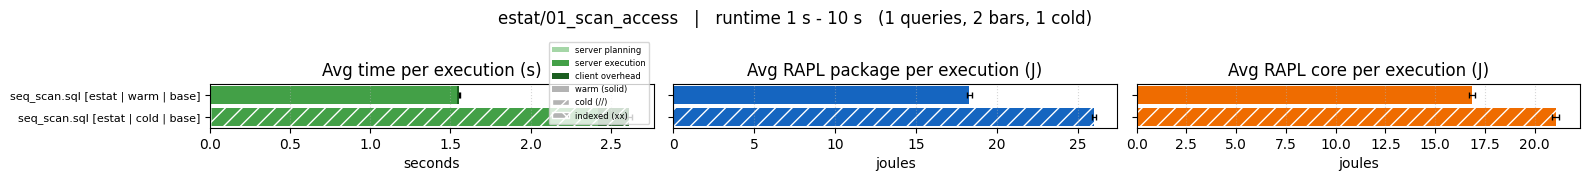

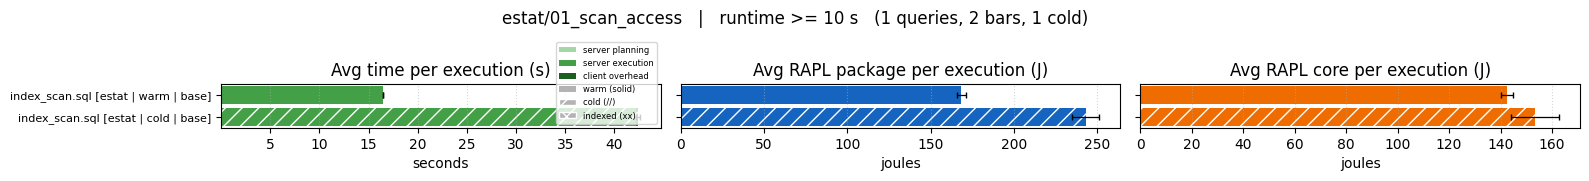

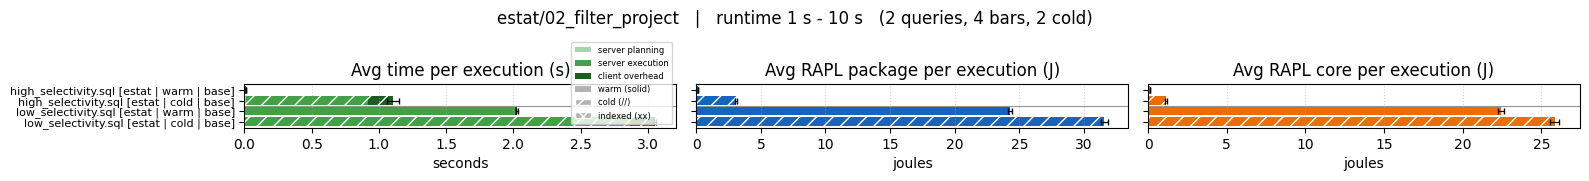

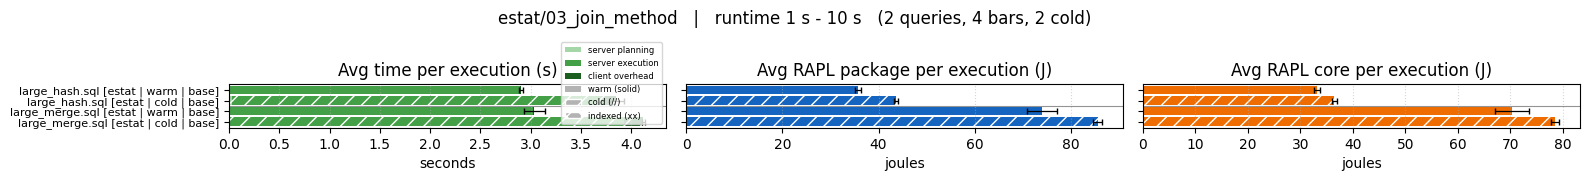

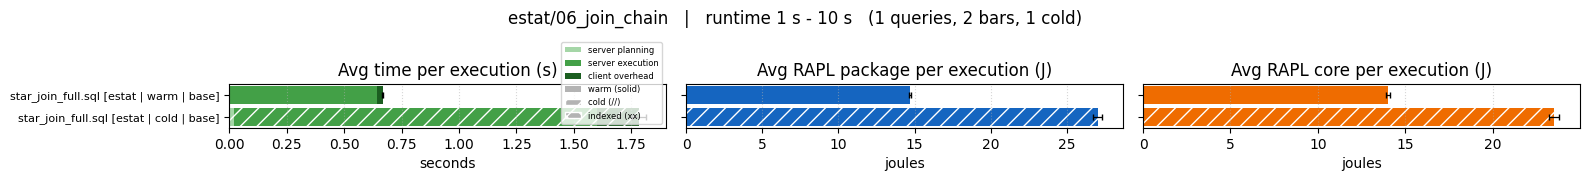

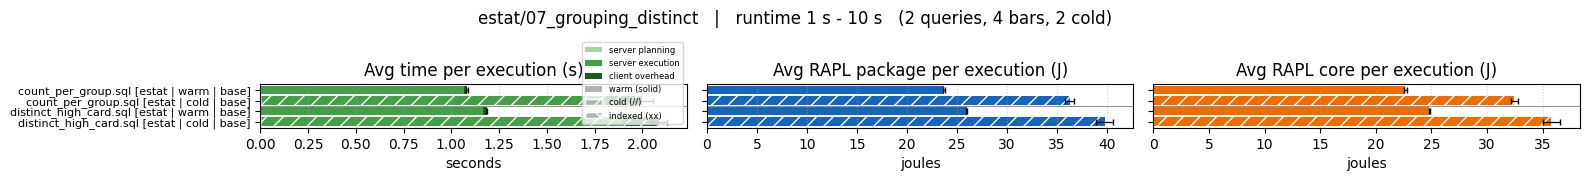

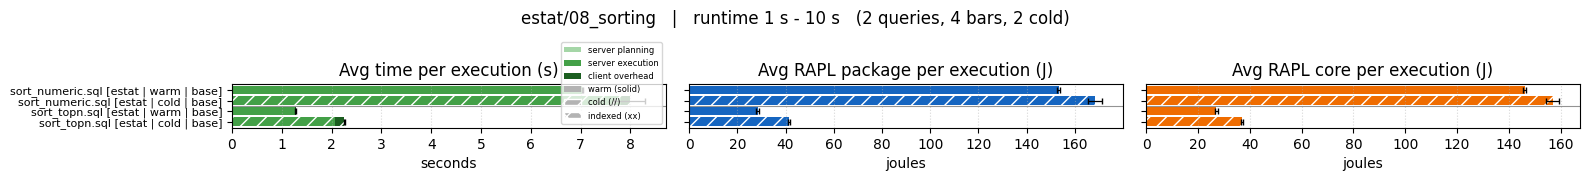

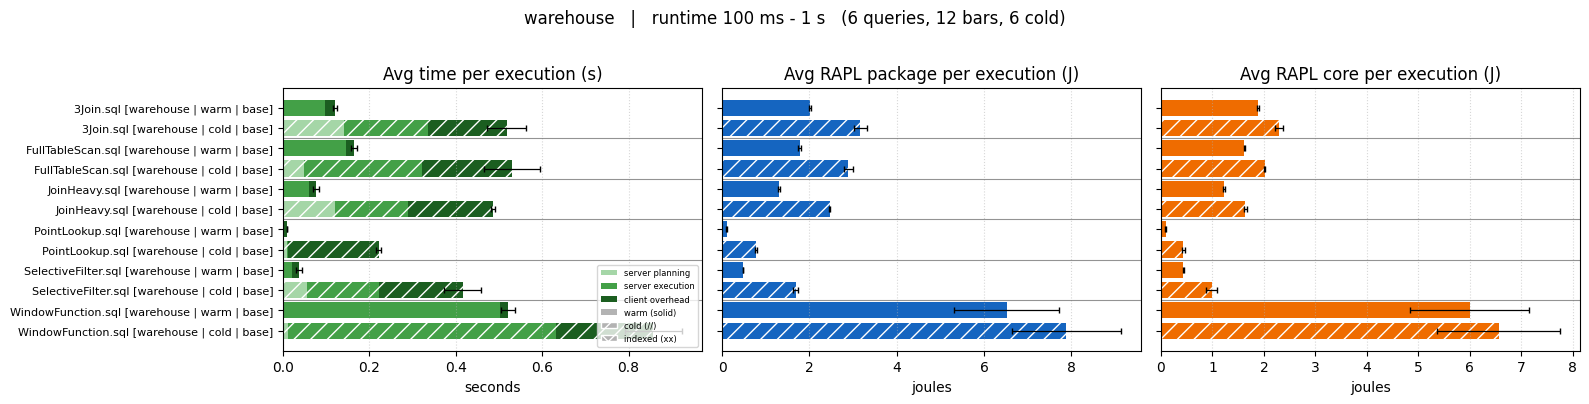

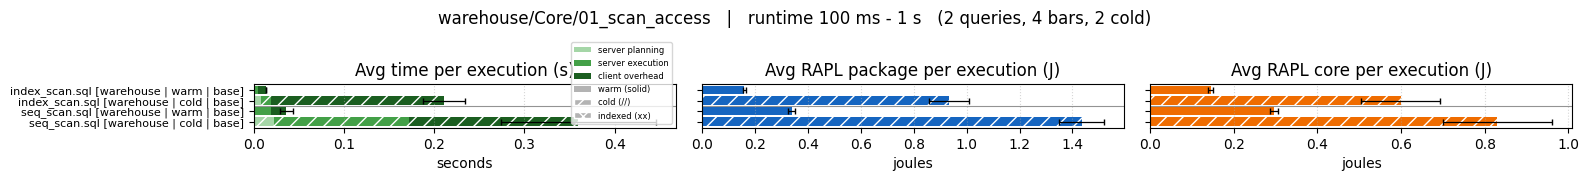

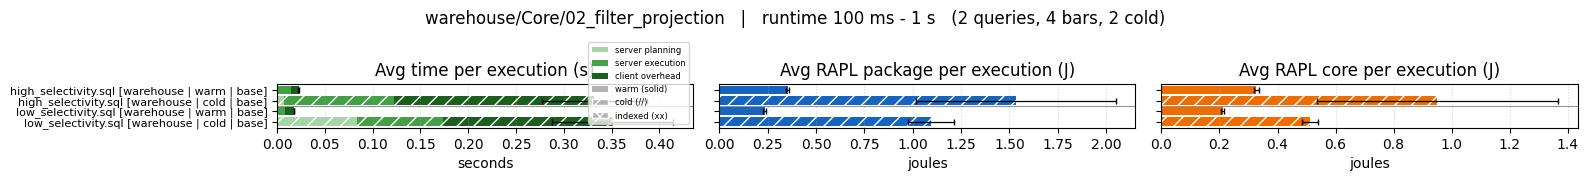

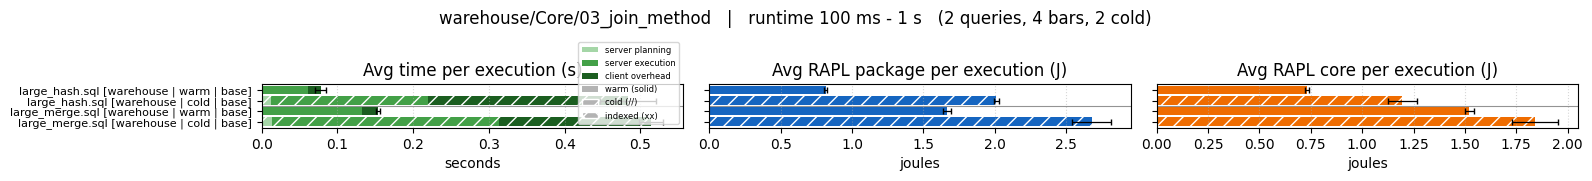

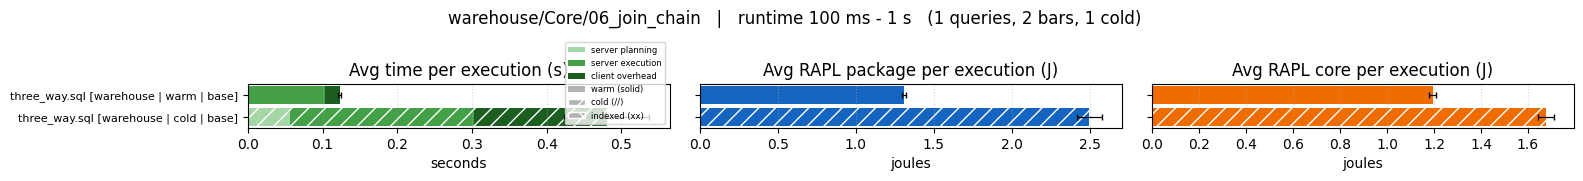

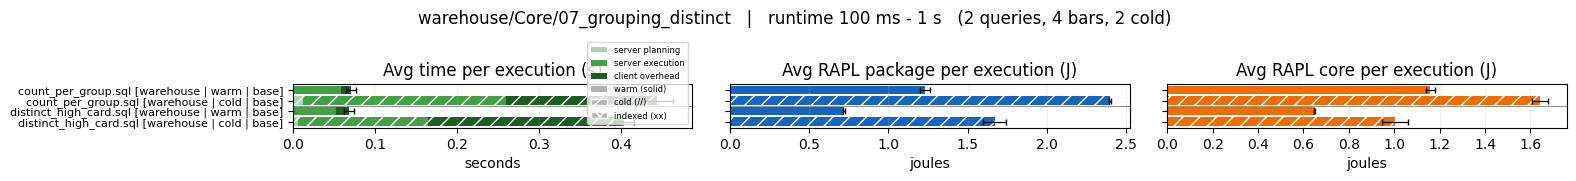

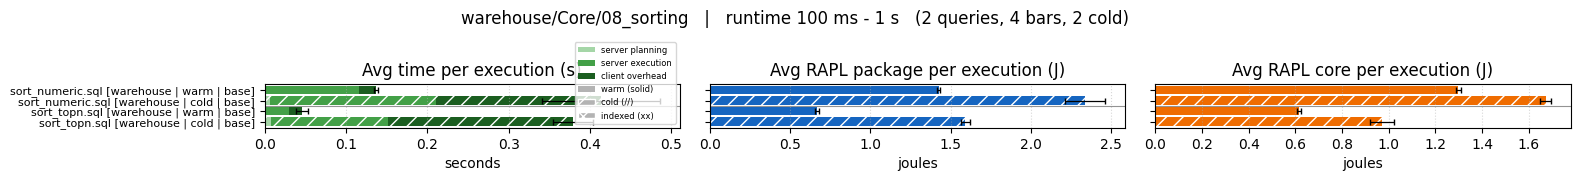

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

GROUPS = None            # subfolders to draw; None = all
# bin START values in SECONDS; add/remove entries to change the number and
# size of the runtime bins. A whole query (all its size/version cohorts) is
# placed in ONE bin so they stay together and remain comparable.
RUNTIME_BINS = [0.0, 0.01, 0.1, 1.0, 10.0]
# which cohort runtime decides a query's bin: "max" keeps every bar within
# the bin's scale; also "median" | "min" | "mean".
BIN_STAT = "max"
MAX_FIGURES = 250        # safety cap on number of figures
ALL_LABEL = "ALL queries"
COMPONENTS = [
    ("plan_s",     "#a5d6a7", "server planning"),
    ("exec_s",     "#43a047", "server execution"),
    ("overhead_s", "#1b5e20", "client overhead"),
]
CACHE_HATCH = "//"       # cold cache adds diagonal hatch (warm = none)
IDX_HATCH = "xx"         # indexed adds crosses (base = none)
edges = list(RUNTIME_BINS) + [np.inf]

# combine warm (data) + base cold + indexed cold, tagged by temp/index_status
PLOT_COLS = ["cohort", "group", "sql_file", "query", "dataset",
             "avg_time_s", "plan_s", "exec_s", "overhead_s", "time_std",
             "avg_pkg_j", "pkg_j_std", "avg_core_j", "core_j_std",
             "temp", "index_status"]


def _slice(df):
    d = df.copy()
    for c in PLOT_COLS:
        if c not in d.columns:
            d[c] = np.nan
    return d[PLOT_COLS]


plotdf = _slice(data)
if COLD_OK:
    plotdf = pd.concat([plotdf, _slice(cold)], ignore_index=True)
#if COLD_IDX_OK:
#    plotdf = pd.concat([plotdf, _slice(cold_idx)], ignore_index=True)


def size_key(lbl):
    m = re.match(r"([\d.]+)", str(lbl))
    return float(m.group(1)) if m else 0.0


def fmt_t(s):
    return f"{s * 1000:g} ms" if s < 1 else f"{s:g} s"


def bin_name(i):
    lo, hi = edges[i], edges[i + 1]
    return f">= {fmt_t(lo)}" if np.isinf(hi) else f"{fmt_t(lo)} - {fmt_t(hi)}"


def hatch_runs(container, is_cold, is_idx):
    """Hatch bars so cache (//) and index (xx) status read apart."""
    for bar, cold_bar, idx_bar in zip(container, is_cold, is_idx):
        h = (CACHE_HATCH if cold_bar else "") + (IDX_HATCH if idx_bar else "")
        if h:
            bar.set_hatch(h)
            bar.set_edgecolor("white")
            bar.set_linewidth(0.0)


all_groups = sorted(plotdf["group"].dropna().unique())
groups = all_groups if GROUPS is None else [g for g in all_groups if g in GROUPS]
groups_for_tasks = groups + [ALL_LABEL]

# one bin per QUERY (not per bar): take BIN_STAT over the query's cohort
# runtimes (all runs), so every size/version/cache/index lands in one figure.
qrep = plotdf.groupby("query")["avg_time_s"].agg(BIN_STAT)
qbin = pd.Series(np.digitize(qrep.to_numpy(), edges[1:], right=False),
                 index=qrep.index)           # 0..len(RUNTIME_BINS)-1
qbin[qrep.isna()] = -1
dq = plotdf.copy()
dq["_bin"] = dq["query"].map(qbin)
dq["_temp_ord"] = (dq["temp"] == "cold").astype(int)      # warm first
dq["_idx_ord"] = (dq["index_status"] == "idx").astype(int)  # base first
# full run identity: pg version | scale factor | cache status | index status
dq["_cache"] = dq["temp"].astype(str)
dq["_index"] = dq["index_status"].astype(str)
#dq["plab"] = (dq["sql_file"] + "  [pg " + dq["pg_version"].astype(str)
#              + " | " + dq["db_size"].astype(str)
#              + " | " + dq["_cache"] + " | " + dq["_index"] + "]")
dq["plab"] = (dq["sql_file"] + " [" + dq["dataset"].astype(str)
              + " | " + dq["_cache"] + " | " + dq["_index"] + "]")


# enumerate the (group, bin) figures that actually contain queries
tasks = []
for group in groups:
    gb = dq.loc[dq["group"] == group, "_bin"]
    for i in sorted(b for b in gb.dropna().unique() if b >= 0):
        tasks.append((group, int(i)))
n_warm = int((dq["temp"] == "warm").sum())
n_coldb = int(((dq["temp"] == "cold") & (dq["index_status"] == "base")).sum())
n_idx = int((dq["index_status"] == "idx").sum())
print(f"{len(groups)} group(s) -> {len(tasks)} (group x runtime-bin) figures "
      f"(bin by {BIN_STAT} of each query's cohorts)")
print(f"bars: {n_warm} warm + {n_coldb} cold(base) + {n_idx} cold(indexed)")
if len(tasks) > MAX_FIGURES:
    print(f"capping to {MAX_FIGURES} - widen RUNTIME_BINS or set GROUPS to see more")
    tasks = tasks[:MAX_FIGURES]

for group, i in tasks:
    if group == ALL_LABEL:
        g = dq[dq["_bin"] == i].copy()
        sort_cols = ["group", "sql_file", "_temp_ord", "_idx_ord"]
        g["plab"] = g["group"] + " / " + g["plab"]
    else:
        g = dq[(dq["group"] == group) & (dq["_bin"] == i)].copy()
        sort_cols = ["sql_file", "_temp_ord", "_idx"]
    #g["_sk"] = g["db_size"].map(size_key)
    g = g.sort_values(["sql_file", "_temp_ord", "_idx_ord"])
    y = np.arange(len(g))
    is_cold = (g["temp"] == "cold").to_numpy()
    is_idx = (g["index_status"] == "idx").to_numpy()
    height = max(1.8, len(g) * 0.34)

    fig, axes = plt.subplots(1, 3, figsize=(16, height), sharey=True)

    # --- panel 1: stacked sub-timings -------------------------------
    ax = axes[0]
    left = np.zeros(len(g))
    for col, colour, _ in COMPONENTS:
        vals = g[col].fillna(0).to_numpy(dtype=float)
        hatch_runs(ax.barh(y, vals, left=left, color=colour), is_cold, is_idx)
        left += vals
    std = g["time_std"].to_numpy(dtype=float)
    ok = ~np.isnan(std)
    if ok.any():
        ax.errorbar(left[ok], y[ok], xerr=std[ok], fmt="none",
                    ecolor="black", elinewidth=0.9, capsize=2)
    ax.set_title("Avg time per execution (s)")
    ax.set_xlabel("seconds")
    handles = [Patch(facecolor=c, label=l) for _, c, l in COMPONENTS]
    handles += [Patch(facecolor="0.7", label="warm (solid)"),
                Patch(facecolor="0.7", hatch=CACHE_HATCH, edgecolor="white",
                      label="cold (//)"),
                Patch(facecolor="0.7", hatch=IDX_HATCH, edgecolor="white",
                      label="indexed (xx)")]
    ax.legend(handles=handles, fontsize=6, loc="lower right")

    # --- panels 2 & 3: energy (with std whiskers) -------------------
    for ax, col, scol, colour, title in (
        (axes[1], "avg_pkg_j", "pkg_j_std", "#1565c0",
         "Avg RAPL package per execution (J)"),
        (axes[2], "avg_core_j", "core_j_std", "#ef6c00",
         "Avg RAPL core per execution (J)"),
    ):
        vals = g[col].to_numpy(dtype=float)
        hatch_runs(ax.barh(y, np.nan_to_num(vals), color=colour), is_cold, is_idx)
        estd = g[scol].to_numpy(dtype=float)
        eok = ~np.isnan(estd) & ~np.isnan(vals)
        if eok.any():
            ax.errorbar(vals[eok], y[eok], xerr=estd[eok], fmt="none",
                        ecolor="black", elinewidth=0.9, capsize=2)
        for yi, v in zip(y, vals):
            if np.isnan(v):
                ax.text(0, yi, " N/A", va="center", fontsize=7, color="gray")
        ax.set_title(title)
        ax.set_xlabel("joules")

    # separator between queries within the bin
    sql = g["sql_file"].to_numpy()
    bounds = [k - 0.5 for k in range(1, len(g)) if sql[k] != sql[k - 1]]
    for ax in axes:
        ax.grid(axis="x", linestyle=":", alpha=0.5)
        for yb in bounds:
            ax.axhline(yb, color="0.4", lw=0.8, alpha=0.7)

    if group == ALL_LABEL:
        cats = g["group"].to_numpy()
        cat_bounds = [k - 0.5 for k in range(1, len(g)) if cats[k] != cats[k-1]]
        for ax in axes:
            for yb in cat_bounds:
                ax.axhline(yb, color="black", lw=1.4, alpha=0.8)

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(g["plab"], fontsize=8)
    axes[0].invert_yaxis()
    nc = int((is_cold & ~is_idx).sum()); ni = int(is_idx.sum())
    parts = ([f"{nc} cold"] if nc else []) + ([f"{ni} indexed"] if ni else [])
    tag = (", " + ", ".join(parts)) if parts else ""
    fig.suptitle(f"{group}   |   runtime {bin_name(i)}   "
                 f"({g['sql_file'].nunique()} queries, {len(g)} bars{tag})",
                 fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

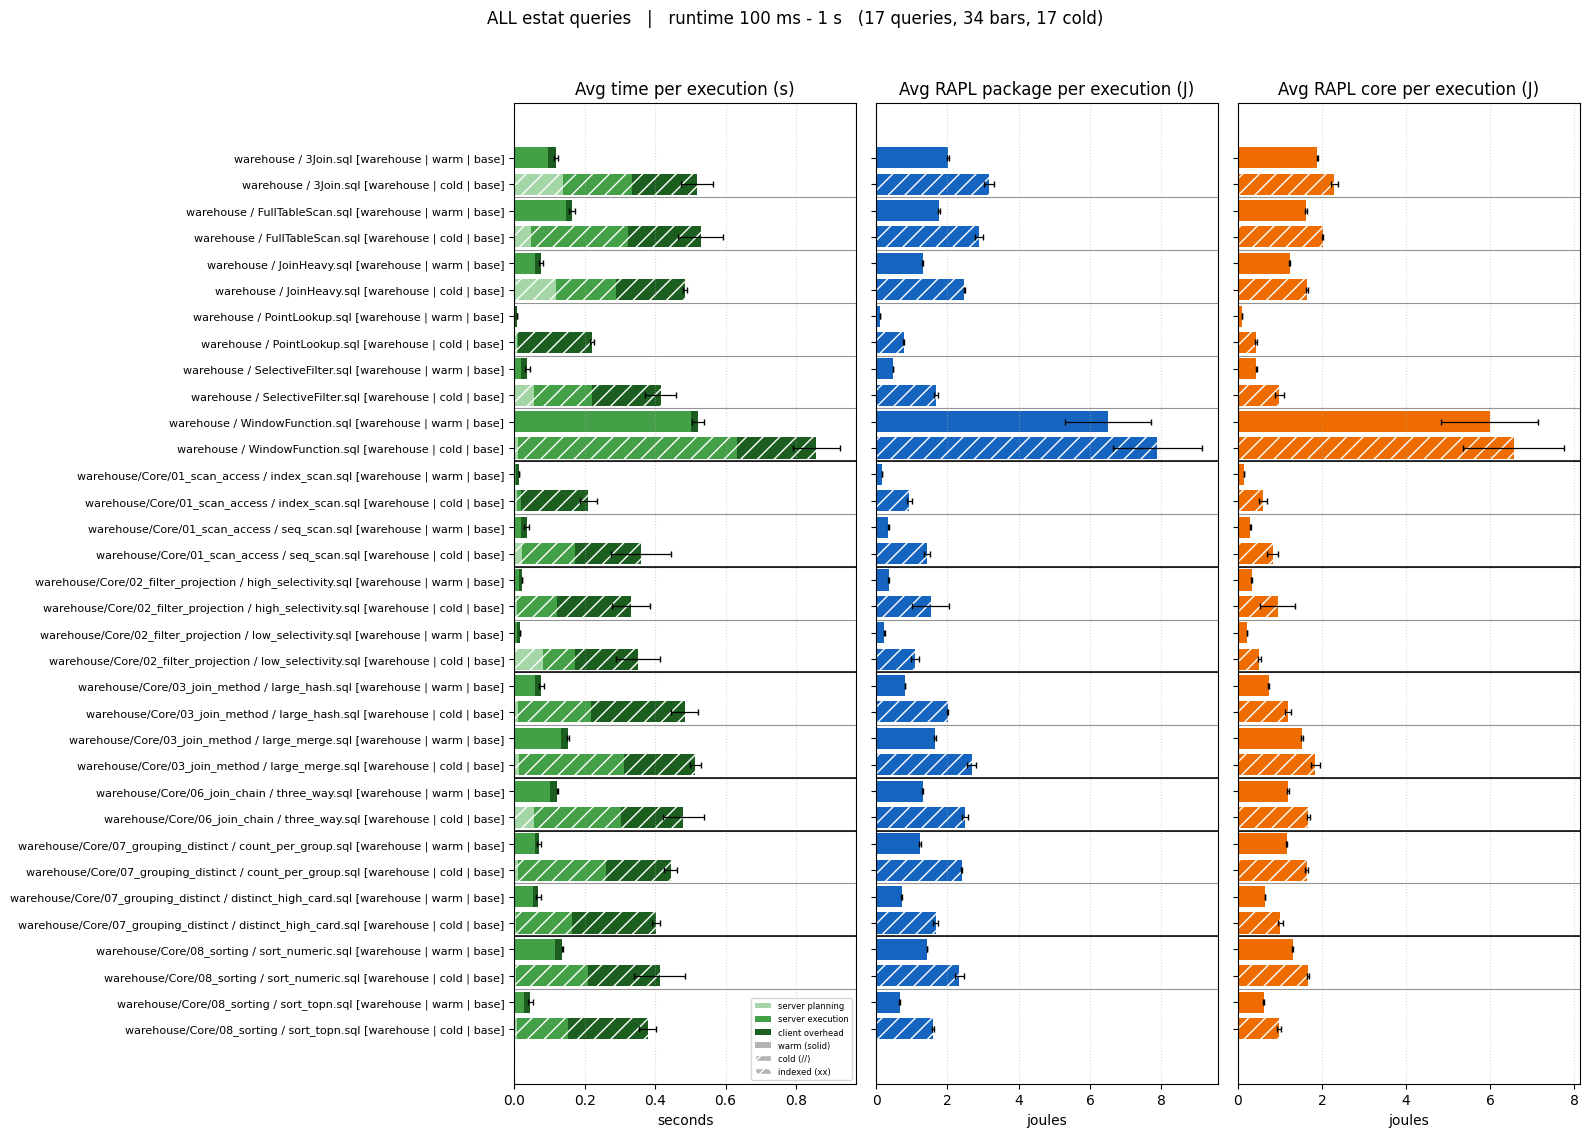

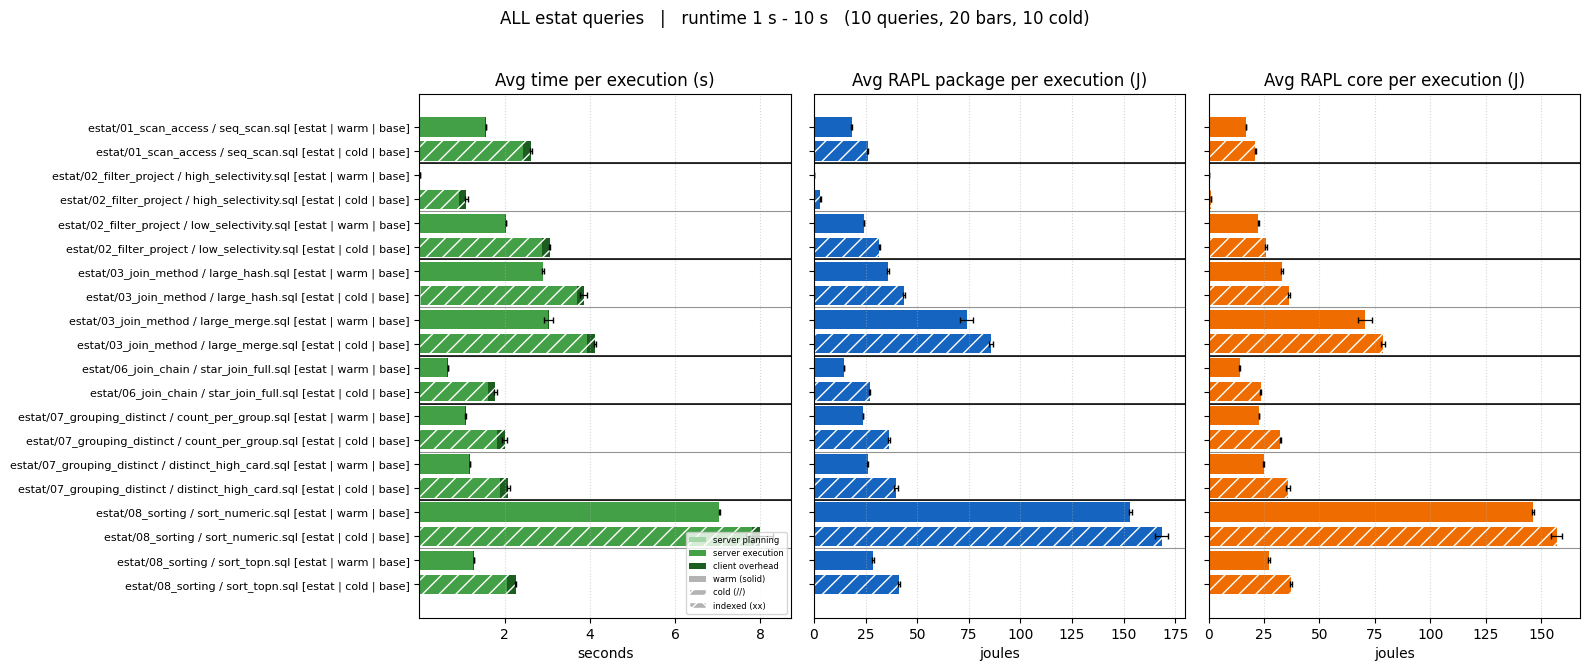

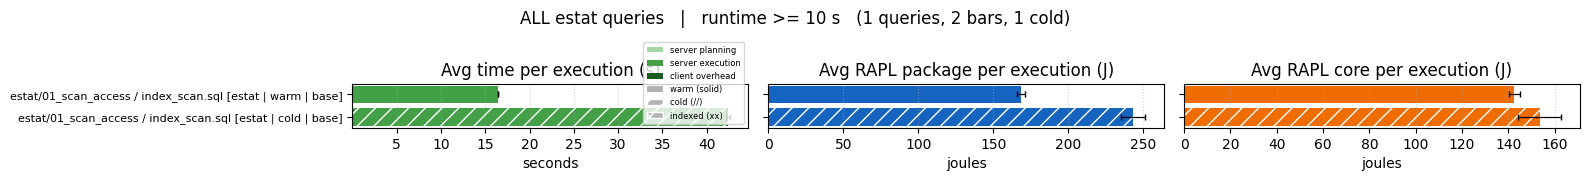

In [10]:
# ESTAT: plot ALL queries together, independent of folder/group


ALL_GROUP_LABEL = "ALL estat queries"

# Use the already-prepared dq from the previous plotting cell.
# Every query is included regardless of its group/folder.
for i in sorted(b for b in dq["_bin"].dropna().unique() if b >= 0):

    g = dq[dq["_bin"] == i].copy()

    # Prefix the label with the original group if available.
    # This is only for readability; it does NOT determine inclusion.
    g["plab"] = (
        g["group"].fillna("(no group)").astype(str)
        + " / "
        + g["plab"].astype(str)
    )
    g = g.sort_values(["group", "sql_file", "_temp_ord", "_idx_ord"])
    y = np.arange(len(g))

    is_cold = (g["temp"] == "cold").to_numpy()
    is_idx = (g["index_status"] == "idx").to_numpy()

    height = max(1.8, len(g) * 0.34)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(16, height),
        sharey=True
    )

    # Panel 1: execution time
    ax = axes[0]

    left = np.zeros(len(g))

    for col, colour, _ in COMPONENTS:
        vals = g[col].fillna(0).to_numpy(dtype=float)

        hatch_runs(
            ax.barh(y, vals, left=left, color=colour),
            is_cold,
            is_idx
        )

        left += vals

    std = g["time_std"].to_numpy(dtype=float)
    ok = ~np.isnan(std)

    if ok.any():
        ax.errorbar(
            left[ok],
            y[ok],
            xerr=std[ok],
            fmt="none",
            ecolor="black",
            elinewidth=0.9,
            capsize=2
        )

    ax.set_title("Avg time per execution (s)")
    ax.set_xlabel("seconds")

    handles = [
        Patch(facecolor=c, label=l)
        for _, c, l in COMPONENTS
    ]

    handles += [
        Patch(facecolor="0.7", label="warm (solid)"),
        Patch(
            facecolor="0.7",
            hatch=CACHE_HATCH,
            edgecolor="white",
            label="cold (//)"
        ),
        Patch(
            facecolor="0.7",
            hatch=IDX_HATCH,
            edgecolor="white",
            label="indexed (xx)"
        )
    ]

    ax.legend(handles=handles, fontsize=6, loc="lower right")

    # Panels 2 & 3: energy
    for ax, col, scol, colour, title in (
        (
            axes[1],
            "avg_pkg_j",
            "pkg_j_std",
            "#1565c0",
            "Avg RAPL package per execution (J)"
        ),
        (
            axes[2],
            "avg_core_j",
            "core_j_std",
            "#ef6c00",
            "Avg RAPL core per execution (J)"
        ),
    ):

        vals = g[col].to_numpy(dtype=float)

        hatch_runs(
            ax.barh(
                y,
                np.nan_to_num(vals),
                color=colour
            ),
            is_cold,
            is_idx
        )

        estd = g[scol].to_numpy(dtype=float)

        eok = ~np.isnan(estd) & ~np.isnan(vals)

        if eok.any():
            ax.errorbar(
                vals[eok],
                y[eok],
                xerr=estd[eok],
                fmt="none",
                ecolor="black",
                elinewidth=0.9,
                capsize=2
            )

        for yi, v in zip(y, vals):
            if np.isnan(v):
                ax.text(
                    0,
                    yi,
                    " N/A",
                    va="center",
                    fontsize=7,
                    color="gray"
                )

        ax.set_title(title)
        ax.set_xlabel("joules")

    # Separators between queries
    sql = g["sql_file"].to_numpy()

    bounds = [
        k - 0.5
        for k in range(1, len(g))
        if sql[k] != sql[k - 1]
    ]

    for ax in axes:
        ax.grid(
            axis="x",
            linestyle=":",
            alpha=0.5
        )

        for yb in bounds:
            ax.axhline(
                yb,
                color="0.4",
                lw=0.8,
                alpha=0.7
            )

    # Separator between original groups
    cats = g["group"].fillna("(no group)").to_numpy()

    cat_bounds = [
        k - 0.5
        for k in range(1, len(g))
        if cats[k] != cats[k - 1]
    ]

    for ax in axes:
        for yb in cat_bounds:
            ax.axhline(
                yb,
                color="black",
                lw=1.4,
                alpha=0.8
            )

    # Labels and title
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(
        g["plab"],
        fontsize=8
    )
    axes[0].invert_yaxis()

    nc = int((is_cold & ~is_idx).sum())
    ni = int(is_idx.sum())

    parts = (
        ([f"{nc} cold"] if nc else [])
        + ([f"{ni} indexed"] if ni else [])
    )

    tag = (
        ", " + ", ".join(parts)
        if parts else ""
    )

    fig.suptitle(
        f"{ALL_GROUP_LABEL}   |   runtime {bin_name(i)}   "
        f"({g['sql_file'].nunique()} queries, "
        f"{len(g)} bars{tag})",
        fontsize=12
    )

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()

## 6. Other sample metrics worth looking at

*(warm runs only.)*

The samples file carries several counters that explain *why* a query is
slow or power-hungry:

* **buffer cache hit %** — `shared_hit / (shared_hit + shared_read)`;
  low values mean the query is reading from disk.
* **temp blocks** — `temp_read + temp_written`; non-zero means the query
  spilled out of `work_mem` to temporary files.
* **client CPU** — user vs system CPU seconds per run.

(`shared_dirtied_blks` / `shared_written_blks` are all zero in this
dataset — read-only workload — so they are skipped.)

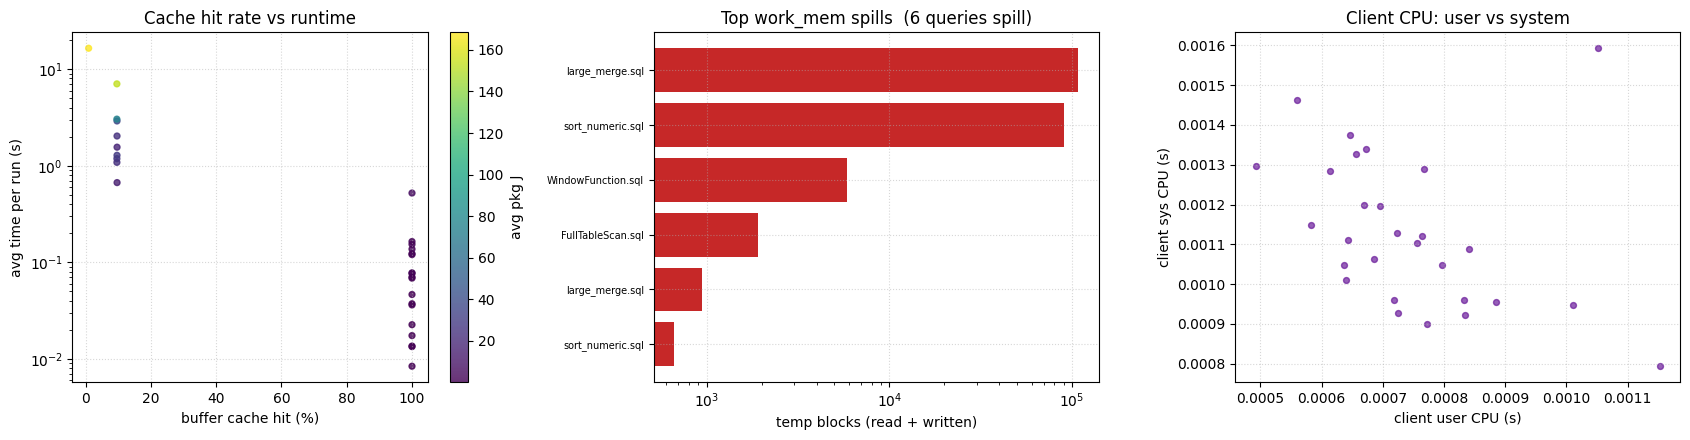

queries spilling to temp files : 6
median cache hit rate          : 100.0%
queries reading >50% from disk : 10


In [14]:
d = data.dropna(subset=["time_mean"])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# cache hit % vs time
ax = axes[0]
sc = ax.scatter(d["cache_hit_pct"], d["time_mean"], s=18,
                c=d["avg_pkg_j"], cmap="viridis", alpha=0.8)
ax.set_xlabel("buffer cache hit (%)"); ax.set_ylabel("avg time per run (s)")
ax.set_yscale("log"); ax.set_title("Cache hit rate vs runtime")
fig.colorbar(sc, ax=ax, label="avg pkg J")

# temp spill
ax = axes[1]
spill = d[d["temp_blks"] > 0].nlargest(15, "temp_blks")
if len(spill):
    ax.barh(np.arange(len(spill)), spill["temp_blks"], color="#c62828")
    ax.set_yticks(np.arange(len(spill)))
    ax.set_yticklabels(spill["sql_file"], fontsize=7)
    ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("temp blocks (read + written)")
ax.set_title(f"Top work_mem spills  ({int((d['temp_blks'] > 0).sum())} queries spill)")

# CPU split
ax = axes[2]
ax.scatter(d["user_cpu_s"], d["sys_cpu_s"], s=18, alpha=0.7, color="#6a1b9a")
ax.set_xlabel("client user CPU (s)"); ax.set_ylabel("client sys CPU (s)")
ax.set_title("Client CPU: user vs system")

for ax in axes:
    ax.grid(linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"queries spilling to temp files : {int((d['temp_blks'] > 0).sum())}")
print(f"median cache hit rate          : {d['cache_hit_pct'].median():.1f}%")
print(f"queries reading >50% from disk : "
      f"{int((d['cache_hit_pct'] < 50).sum())}")

## 7. Warmup effect — which queries need warming up?

*(This is the **warm** dataset's own internal warmup batches — not the
separate cold-run file; that lives in sections 5, 8b and 9b.)*

Each query runs `warmup` single-copy batches before the measured batches.
Comparing the **first warmup batch** (a cold single copy) against the
**measured per-copy mean** (warm-amortised over the 10-copy batches) shows
which queries start cold and only then settle:

$$\text{warmup ratio} = \frac{t_{\text{warmup batch 1}}}{\overline{t}_{\text{measured per copy}}}$$

A ratio near 1.0 means the query was already warm; a ratio of 3 means the
first execution took three times as long as the settled ones — typically
a cold buffer cache on a table scan.

17/28 queries are warmup-affected (first copy >= 1.2x the measured per-copy mean)
median warmup ratio overall: 1.594


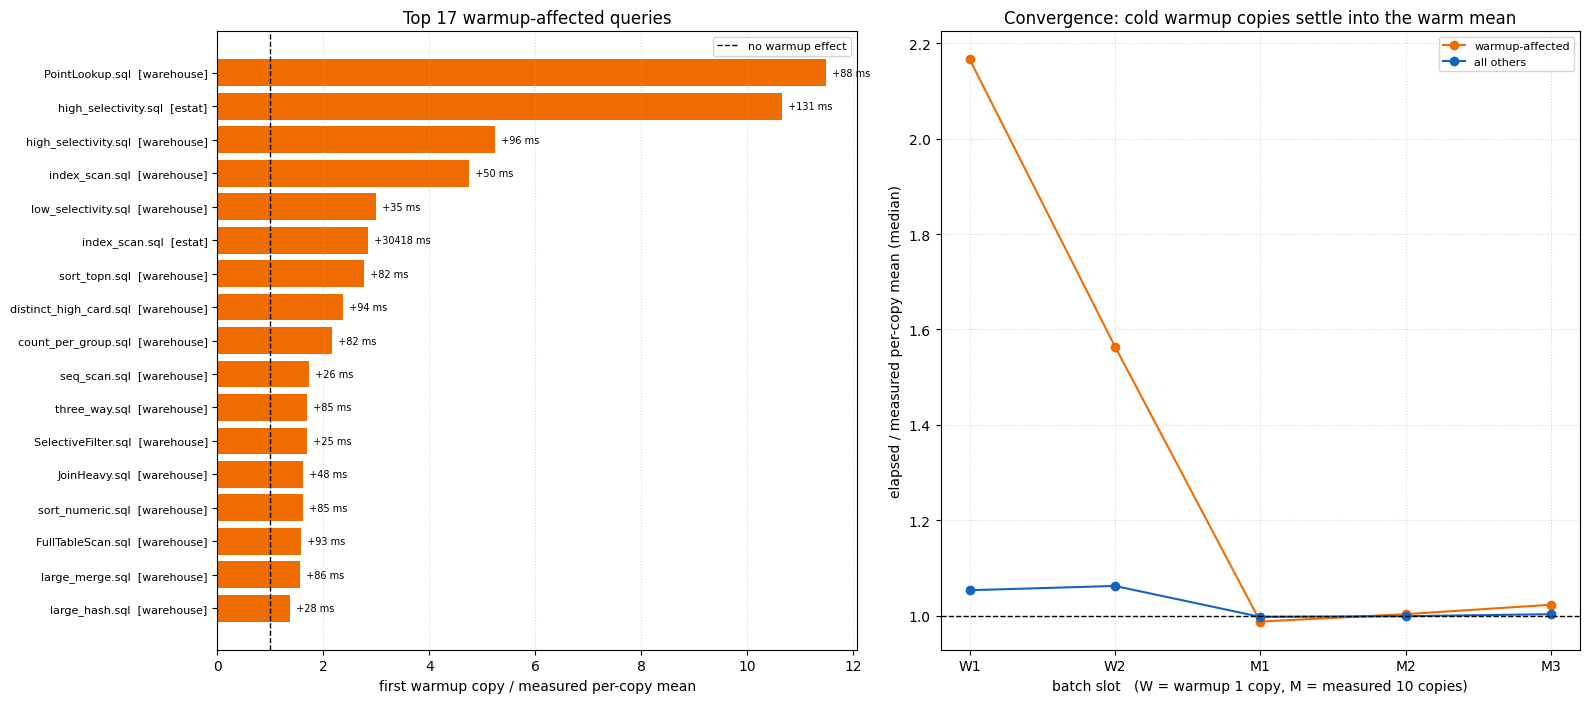


                              group               sql_file  warm1  time_mean  warm_ratio  extra_ms
                          warehouse        PointLookup.sql  0.096      0.008      11.496    88.102
            estat/02_filter_project   high_selectivity.sql  0.145      0.014      10.660   131.046
warehouse/Core/02_filter_projection   high_selectivity.sql  0.119      0.023       5.247    95.933
      warehouse/Core/01_scan_access         index_scan.sql  0.064      0.013       4.755    50.343
warehouse/Core/02_filter_projection    low_selectivity.sql  0.052      0.017       3.001    34.854
               estat/01_scan_access         index_scan.sql 46.872     16.454       2.849 30418.427
          warehouse/Core/08_sorting          sort_topn.sql  0.128      0.046       2.762    81.771
warehouse/Core/07_grouping_distinct distinct_high_card.sql  0.162      0.069       2.366    93.598
warehouse/Core/07_grouping_distinct    count_per_group.sql  0.152      0.070       2.166    82.030
      war

In [15]:
warm = timing[timing["phase"] == "warmup"].copy()
warm["elapsed_sec"] = pd.to_numeric(warm["elapsed_sec"], errors="coerce")

# first warmup batch = cold single copy (average across pooled run ids)
w1 = (warm[warm["batch_index"] == 1]
      .groupby(KEY)["elapsed_sec"].mean().rename("warm1"))
wmean = warm.groupby(KEY)["elapsed_sec"].mean().rename("warm_mean")

wdf = (data.set_index(KEY)[["group", "sql_file", "label", "time_mean"]]
       .join(w1).join(wmean).dropna(subset=["warm1", "time_mean"]))
wdf["warm_ratio"] = wdf["warm1"] / wdf["time_mean"]
wdf["extra_ms"] = 1000 * (wdf["warm1"] - wdf["time_mean"])

THRESH = 1.20          # >20% slower on the first copy = warmup-affected
affected = wdf[wdf["warm_ratio"] >= THRESH].sort_values("warm_ratio",
                                                        ascending=False)

print(f"{len(affected)}/{len(wdf)} queries are warmup-affected "
      f"(first copy >= {THRESH:g}x the measured per-copy mean)")
print(f"median warmup ratio overall: {wdf['warm_ratio'].median():.3f}")

TOP_N = 20
top = affected.head(TOP_N).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(16, max(4, 0.42 * len(top))))

# --- left: how much slower the first copy is ---
ax = axes[0]
yy = np.arange(len(top))
ax.barh(yy, top["warm_ratio"], color="#ef6c00")
ax.axvline(1.0, color="k", ls="--", lw=1, label="no warmup effect")
for i, (r, e) in enumerate(zip(top["warm_ratio"], top["extra_ms"])):
    ax.text(r, i, f"  +{e:.0f} ms", va="center", fontsize=7)
ax.set_yticks(yy); ax.set_yticklabels(top["label"], fontsize=8)
ax.set_xlabel("first warmup copy / measured per-copy mean")
ax.set_title(f"Top {len(top)} warmup-affected queries")
ax.legend(fontsize=8); ax.grid(axis="x", linestyle=":", alpha=0.5)

# --- right: convergence across the batch sequence ---
ax = axes[1]
tw = warm[["cohort", "query", "batch_index", "elapsed_sec"]].copy()
tw["slot"] = "W" + tw["batch_index"].astype(int).astype(str)
tw["value"] = tw["elapsed_sec"]
tmb = timing[timing["phase"] == "measured"][
    ["cohort", "query", "batch_index"]].copy()
tmb["value"] = pd.to_numeric(
    timing.loc[timing["phase"] == "measured", "avg_copy_elapsed_sec"],
    errors="coerce").values
tmb["slot"] = "M" + tmb["batch_index"].astype(int).astype(str)
seq = pd.concat([tw[["cohort", "query", "slot", "value"]],
                 tmb[["cohort", "query", "slot", "value"]]], ignore_index=True)
order = sorted(tw["slot"].unique()) + sorted(tmb["slot"].unique())

norm = seq.merge(wdf[["time_mean"]].reset_index(), on=KEY)
norm["rel"] = norm["value"] / norm["time_mean"]
aff_set = set(affected.index)                       # (cohort, query) tuples
is_aff = pd.Series(list(zip(norm["cohort"], norm["query"])),
                   index=norm.index).isin(aff_set)
for label, subset, colour in (
    ("warmup-affected", norm[is_aff], "#ef6c00"),
    ("all others", norm[~is_aff], "#1565c0"),
):
    prof = subset.groupby("slot")["rel"].median().reindex(order)
    ax.plot(order, prof, marker="o", color=colour, label=label)

ax.axhline(1.0, color="k", ls="--", lw=1)
ax.set_ylabel("elapsed / measured per-copy mean (median)")
ax.set_xlabel("batch slot   (W = warmup 1 copy, M = measured 10 copies)")
ax.set_title("Convergence: cold warmup copies settle into the warm mean")
ax.legend(fontsize=8); ax.grid(linestyle=":", alpha=0.5)

fig.tight_layout(); plt.show()

print()
print(affected[["group", "sql_file", "warm1", "time_mean",
                "warm_ratio", "extra_ms"]].head(15).round(3).to_string(index=False))

## 8. Where does the timing variance come from?

Total time is an exact sum of its three parts, so its variance splits
**exactly** into their contributions:

$$T = c_{plan} + c_{exec} + c_{client}
\qquad\Rightarrow\qquad
\operatorname{Var}(T) = \sum_i \operatorname{Cov}(c_i, T)$$

So each component's share of the run-to-run variance is
$\operatorname{Cov}(c_i, T) / \operatorname{Var}(T)$, and the three shares
sum to 1 by construction (a useful self-check). Shares can be slightly
negative when one component moves *against* the total.

Two different questions are answered separately:

* **relative noisiness** — each component's own CV%;
* **contribution** — how much of the *total* variance it actually causes
  (a very jittery component that is 0.01% of the runtime causes nothing).

In [16]:
comps = [("plan_s", "server planning", "#a5d6a7"),
         ("exec_s", "server execution", "#43a047"),
         ("overhead_s", "client overhead", "#1b5e20")]

# per measured batch: split the batch server wall into planning/execution
# by the query's sample ratio; overhead is the client side. plan+exec+
# overhead == elapsed_sec per batch, so variance decomposes exactly.
mb = timing[timing["phase"] == "measured"][
    ["cohort", "query", "batch_index", "elapsed_sec",
     "server_sum_ms", "client_overhead_sec"]].copy()
for c in ["elapsed_sec", "server_sum_ms", "client_overhead_sec"]:
    mb[c] = pd.to_numeric(mb[c], errors="coerce")
mb = mb.merge(data[["cohort", "query", "plan_ratio"]], on=["cohort", "query"],
              how="left")
r = mb["plan_ratio"].fillna(0.0)
mb["plan_s"] = (mb["server_sum_ms"] / 1000.0) * r
mb["exec_s"] = (mb["server_sum_ms"] / 1000.0) * (1.0 - r)
mb["overhead_s"] = mb["client_overhead_sec"]

rows = []
for (coh, q), grp_rows in mb.groupby(KEY):
    if len(grp_rows) < 2:
        continue
    T = grp_rows["elapsed_sec"].to_numpy(dtype=float)
    var_T = T.var(ddof=1)
    rec = {"cohort": coh, "query": q, "n": len(grp_rows), "mean_total": T.mean(),
           "std_total": T.std(ddof=1), "var_total": var_T}
    for col, _, _ in comps:
        x = grp_rows[col].to_numpy(dtype=float)
        cov = np.cov(x, T, ddof=1)[0, 1]
        rec[f"{col}_mean"] = x.mean()
        rec[f"{col}_std"] = x.std(ddof=1)
        rec[f"{col}_cov"] = cov
        rec[f"{col}_share"] = cov / var_T if var_T > 0 else np.nan
    rows.append(rec)

vd = pd.DataFrame(rows).set_index(KEY)
vd = vd.join(data.set_index(KEY)[["group", "sql_file", "label"]])

share_cols = [f"{c}_share" for c, _, _ in comps]
# a query whose runs are identical has zero total variance, so its shares
# are undefined (NaN) - exclude those from the share-based views
has_var = vd[share_cols].notna().any(axis=1)
n_zero_var = int((~has_var).sum())
chk = vd.loc[has_var, share_cols].sum(axis=1)
print(f"decomposition self-check: shares sum to "
      f"[{chk.min():.6f}, {chk.max():.6f}] over {int(has_var.sum())} queries"
      f"  ({n_zero_var} zero-variance queries excluded)")

print("\n{:<18}{:>12}{:>14}{:>14}{:>12}".format(
    "component", "% of time", "var share", "median CV%", "p90 CV%"))
print("-" * 70)
tot_time = vd["mean_total"].sum()
tot_var = vd["var_total"].sum()
for col, label, _ in comps:
    cv = 100 * vd[f"{col}_std"] / vd[f"{col}_mean"].replace(0, np.nan)
    print("{:<18}{:>11.2f}%{:>13.1f}%{:>14.3f}{:>12.3f}".format(
        label,
        100 * vd[f"{col}_mean"].sum() / tot_time,
        100 * vd[f"{col}_cov"].sum() / tot_var,
        cv.median(), cv.quantile(0.90)))

dom = (vd.loc[has_var, share_cols].idxmax(axis=1)
       .str.replace("_share", "", regex=False))
dom_named = dom.map({c: l for c, l, _ in comps})
print("\ndominant variance source, per query:")
print(dom_named.value_counts().to_string())

decomposition self-check: shares sum to [1.000000, 1.000000] over 28 queries  (0 zero-variance queries excluded)

component            % of time     var share    median CV%     p90 CV%
----------------------------------------------------------------------
server planning          0.02%          0.0%         0.573       3.377
server execution        98.85%         92.4%         0.573       3.377
client overhead          1.14%          7.6%        28.775      45.120

dominant variance source, per query:
client overhead     19
server execution     9


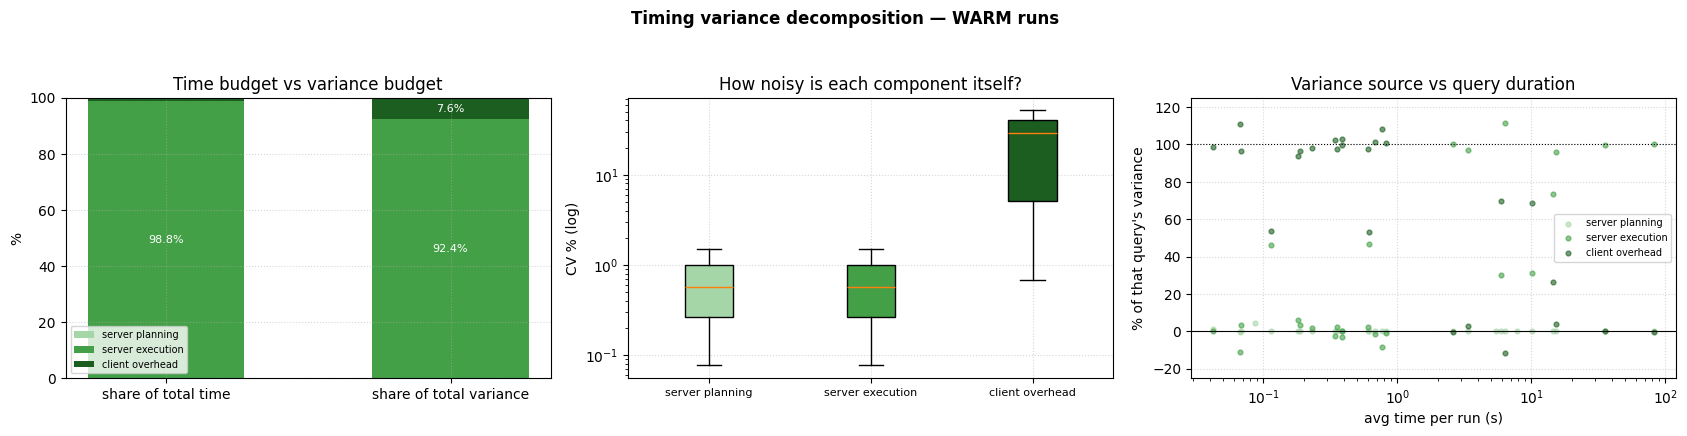

Most variable queries - where their variance comes from (WARM):
                        group            sql_file  mean_total  std_total  server planning  server execution  client overhead
         estat/03_join_method     large_merge.sql     15.1776     0.5290              0.0              96.0              4.0
         estat/01_scan_access      index_scan.sql     82.2696     0.1494              0.0             100.1             -0.1
         estat/03_join_method      large_hash.sql     14.5257     0.1002              0.0              73.7             26.3
                    warehouse  WindowFunction.sql      2.6059     0.0850              0.0             100.4             -0.4
             estat/08_sorting    sort_numeric.sql     35.1760     0.0795              0.0              99.8              0.2
             estat/08_sorting       sort_topn.sql      6.4091     0.0537              0.0             111.4            -11.4
      estat/02_filter_project low_selectivity.sql     10.1476

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

# --- 1. time share vs variance share ---
ax = axes[0]
time_share = [100 * vd[f"{c}_mean"].sum() / tot_time for c, _, _ in comps]
var_share = [100 * vd[f"{c}_cov"].sum() / tot_var for c, _, _ in comps]
xpos = np.arange(2)
bottom = np.zeros(2)
for (col, label, colour), ts, vs in zip(comps, time_share, var_share):
    vals = np.array([ts, vs])
    ax.bar(xpos, vals, bottom=bottom, color=colour, label=label, width=0.55)
    for xi, (val, bot) in enumerate(zip(vals, bottom)):
        if val > 4:
            ax.text(xi, bot + val / 2, f"{val:.1f}%", ha="center",
                    va="center", fontsize=8,
                    color="white" if colour != "#a5d6a7" else "black")
    bottom += vals
ax.set_xticks(xpos); ax.set_xticklabels(["share of total time",
                                         "share of total variance"])
ax.set_ylabel("%"); ax.set_ylim(0, 100)
ax.set_title("Time budget vs variance budget")
ax.legend(fontsize=7, loc="lower left")

# --- 2. per-component CV% distribution ---
ax = axes[1]
cvs = [(100 * vd[f"{c}_std"] / vd[f"{c}_mean"].replace(0, np.nan)).dropna()
       for c, _, _ in comps]
bp = ax.boxplot(cvs, vert=True, patch_artist=True, showfliers=False,
                tick_labels=[l for _, l, _ in comps])
for patch, (_, _, colour) in zip(bp["boxes"], comps):
    patch.set_facecolor(colour)
ax.set_yscale("log"); ax.set_ylabel("CV % (log)")
ax.set_title("How noisy is each component itself?")
ax.tick_params(axis="x", labelsize=8)

# --- 3. variance share vs runtime ---
ax = axes[2]
for col, label, colour in comps:
    ax.scatter(vd["mean_total"], 100 * vd[f"{col}_share"], s=12,
               alpha=0.6, color=colour, label=label)
ax.set_xscale("log"); ax.set_xlabel("avg time per run (s)")
ax.set_ylabel("% of that query's variance")
# a handful of queries have essentially zero variance, which sends their
# shares to +-1000%; clip the view to the meaningful range
ax.set_ylim(-25, 125)
ax.axhline(0, color="k", lw=0.8); ax.axhline(100, color="k", lw=0.8, ls=":")
ax.set_title("Variance source vs query duration")
ax.legend(fontsize=7, loc="center right")

for ax in axes:
    ax.grid(linestyle=":", alpha=0.5)
fig.suptitle("Timing variance decomposition — WARM runs", fontsize=12,
             fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

print("Most variable queries - where their variance comes from (WARM):")
top_var = vd.nlargest(12, "std_total")
show = top_var[["group", "sql_file", "mean_total", "std_total"]].copy()
for col, label, _ in comps:
    show[label] = (100 * top_var[f"{col}_share"]).round(1)
print(show.round(4).to_string(index=False))

### 8b. Same decomposition on the **cold** runs

The cold file records each cold execution's own planning / execution /
overhead split, so the identity `plan + exec + overhead = elapsed` holds per
run and the variance decomposes exactly the same way. This companion figure
(clearly titled **COLD**) is the cold counterpart to the warm one above.
Where a query has fewer than two cold runs it has no variance yet and is
skipped.

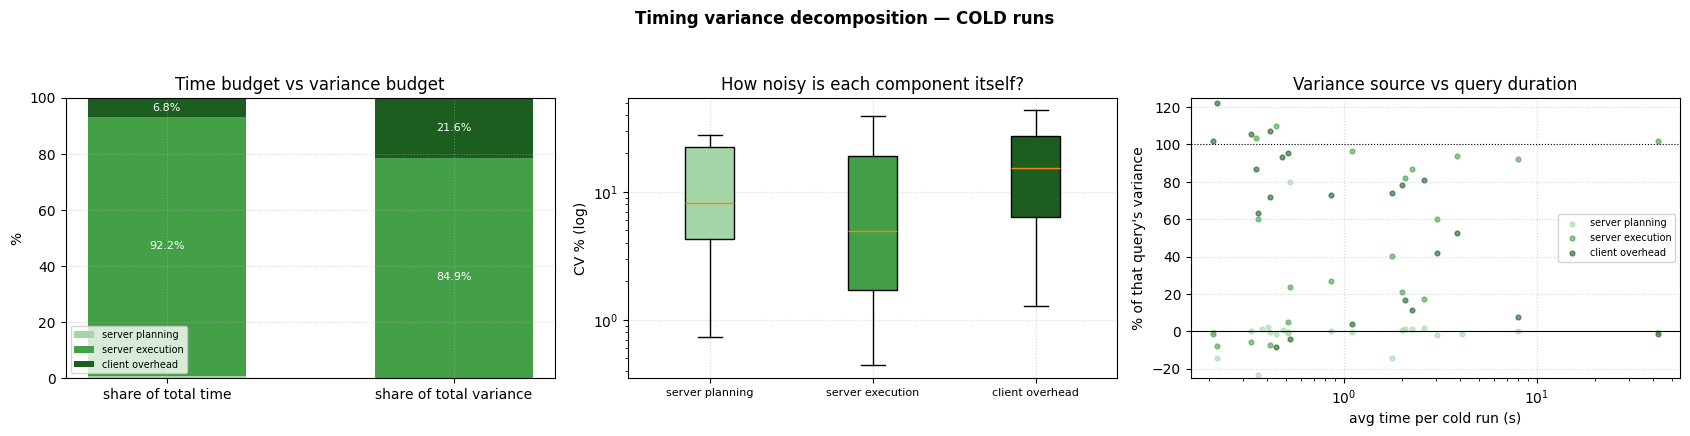

COLD: 28 quer(y/ies) with >=2 cold runs; dominant variance source:
server execution    15
client overhead     11
server planning      2

COLD - most variable queries:
                              group             sql_file  mean_total  std_total  server planning  server execution  client overhead
                   estat/08_sorting     sort_numeric.sql      7.9830     0.3134              0.1              92.0              7.9
               estat/01_scan_access       index_scan.sql     42.3965     0.1865             -0.4             101.8             -1.4
      warehouse/Core/01_scan_access         seq_scan.sql      0.3597     0.0861            -23.2              60.0             63.2
               estat/03_join_method       large_hash.sql      3.8506     0.0760            -46.1              93.7             52.4
          warehouse/Core/08_sorting     sort_numeric.sql      0.4134     0.0724             -0.1              -7.4            107.5
                          warehouse   Win

In [18]:
if not COLD_OK:
    print("No cold data -> no cold variance decomposition.")
else:
    rows = []
    for (coh, q), gr in cold_runs.groupby(["cohort", "query"]):
        if len(gr) < 2:
            continue
        T = gr["time_s"].to_numpy(dtype=float)
        var_T = T.var(ddof=1)
        rec = {"cohort": coh, "query": q, "n": len(gr), "mean_total": T.mean(),
               "std_total": T.std(ddof=1), "var_total": var_T}
        for col, _, _ in comps:
            x = gr[col].to_numpy(dtype=float)
            cov = np.cov(x, T, ddof=1)[0, 1]
            rec[f"{col}_mean"] = x.mean()
            rec[f"{col}_std"] = x.std(ddof=1)
            rec[f"{col}_cov"] = cov
            rec[f"{col}_share"] = cov / var_T if var_T > 0 else np.nan
        rows.append(rec)

    vdc = pd.DataFrame(rows)
    if vdc.empty:
        print("COLD: no (cohort, query) has >=2 cold runs yet - "
              "nothing to decompose.")
    else:
        vdc = vdc.set_index(KEY).join(cold.set_index(KEY)[["group", "sql_file"]])
        cshare = [f"{c}_share" for c, _, _ in comps]
        chas = vdc[cshare].notna().any(axis=1)
        ctot_time = vdc["mean_total"].sum()
        ctot_var = vdc["var_total"].sum()

        fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
        # 1. time budget vs variance budget
        ax = axes[0]
        tshare = [100 * vdc[f"{c}_mean"].sum() / ctot_time for c, _, _ in comps]
        vshare = [100 * vdc[f"{c}_cov"].sum() / ctot_var if ctot_var else 0
                  for c, _, _ in comps]
        xpos = np.arange(2); bottom = np.zeros(2)
        for (col, label, colour), ts, vs in zip(comps, tshare, vshare):
            vals = np.array([ts, vs])
            ax.bar(xpos, vals, bottom=bottom, color=colour, label=label, width=0.55)
            for xi, (val, bot) in enumerate(zip(vals, bottom)):
                if val > 4:
                    ax.text(xi, bot + val / 2, f"{val:.1f}%", ha="center",
                            va="center", fontsize=8,
                            color="white" if colour != "#a5d6a7" else "black")
            bottom += vals
        ax.set_xticks(xpos)
        ax.set_xticklabels(["share of total time", "share of total variance"])
        ax.set_ylabel("%"); ax.set_ylim(0, 100)
        ax.set_title("Time budget vs variance budget")
        ax.legend(fontsize=7, loc="lower left")
        # 2. per-component CV distribution
        ax = axes[1]
        cvs = [(100 * vdc[f"{c}_std"] / vdc[f"{c}_mean"].replace(0, np.nan)).dropna()
               for c, _, _ in comps]
        if any(len(c) for c in cvs):
            bp = ax.boxplot(cvs, vert=True, patch_artist=True, showfliers=False,
                            tick_labels=[l for _, l, _ in comps])
            for patch, (_, _, colour) in zip(bp["boxes"], comps):
                patch.set_facecolor(colour)
            ax.set_yscale("log")
        ax.set_ylabel("CV % (log)")
        ax.set_title("How noisy is each component itself?")
        ax.tick_params(axis="x", labelsize=8)
        # 3. variance share vs runtime
        ax = axes[2]
        for col, label, colour in comps:
            ax.scatter(vdc["mean_total"], 100 * vdc[f"{col}_share"], s=12,
                       alpha=0.6, color=colour, label=label)
        ax.set_xscale("log"); ax.set_xlabel("avg time per cold run (s)")
        ax.set_ylabel("% of that query's variance")
        ax.set_ylim(-25, 125)
        ax.axhline(0, color="k", lw=0.8); ax.axhline(100, color="k", lw=0.8, ls=":")
        ax.set_title("Variance source vs query duration")
        ax.legend(fontsize=7, loc="center right")
        for ax in axes:
            ax.grid(linestyle=":", alpha=0.5)
        fig.suptitle("Timing variance decomposition — COLD runs", fontsize=12,
                     fontweight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

        cdom = (vdc.loc[chas, cshare].idxmax(axis=1)
                .str.replace("_share", "", regex=False)
                .map({c: l for c, l, _ in comps}))
        print(f"COLD: {int(chas.sum())} quer(y/ies) with >=2 cold runs; "
              f"dominant variance source:")
        print(cdom.value_counts().to_string())
        print("\nCOLD - most variable queries:")
        ctop = vdc.nlargest(min(12, len(vdc)), "std_total")
        cshow = ctop[["group", "sql_file", "mean_total", "std_total"]].copy()
        for col, label, _ in comps:
            cshow[label] = (100 * ctop[f"{col}_share"]).round(1)
        print(cshow.round(4).to_string(index=False))

## 9. Does a longer runtime mean less variance?

Two different things can be meant by "less variance", and they point in
**opposite** directions, so both are measured:

* **relative** variance — CV% (`std / mean`): does a long query reproduce
  more *proportionally* consistently?
* **absolute** variance — the raw std in seconds: a 90 s query can wobble
  by far more milliseconds than a 40 ms one and still be tighter in %.

Association is measured with **Spearman rank correlation** (monotonic, and
robust to the heavy skew in runtimes), with a large-sample normal
approximation for the p-value. A log–log least-squares fit gives the
scaling exponent: `CV% ∝ runtime^slope`.

In [19]:
import math

def spearman(x, y):
    """Rank correlation + two-sided p (large-sample normal approximation)."""
    x, y = pd.Series(x).astype(float), pd.Series(y).astype(float)
    ok = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    n = int(ok.sum())
    if n < 3:
        return np.nan, n, np.nan
    rho = np.corrcoef(x[ok].rank(), y[ok].rank())[0, 1]
    z = rho * math.sqrt(n - 1)
    return rho, n, math.erfc(abs(z) / math.sqrt(2))


rv = data.dropna(subset=["cv_pct", "time_mean"]).copy()
rv = rv[rv["time_mean"] > 0]

print(f"{len(rv)} queries, runtime {rv['time_mean'].min():.4f}s "
      f"-> {rv['time_mean'].max():.1f}s\n")
print(f"{'relationship':<38}{'rho':>8}{'p':>12}   verdict")
print("-" * 78)
for label, ycol in (("runtime vs timing CV%", "cv_pct"),
                    ("runtime vs energy CV%", "energy_cv_pct"),
                    ("runtime vs min-max spread%", "spread_pct"),
                    ("runtime vs ABSOLUTE std (s)", "time_std")):
    rho, n, pval = spearman(rv["time_mean"], rv[ycol])
    verdict = ("less variance as runtime grows" if rho < -0.1 else
               "more variance as runtime grows" if rho > 0.1 else
               "no monotonic relationship")
    print(f"{label:<38}{rho:>+8.3f}{pval:>12.2e}   {verdict}")

# power-law fit  CV% ~ runtime^slope
fit = rv[(rv["cv_pct"] > 0)]
slope, intercept = np.polyfit(np.log10(fit["time_mean"]),
                              np.log10(fit["cv_pct"]), 1)
print(f"\nlog-log fit:  CV% ~ runtime^{slope:.3f}")

28 queries, runtime 0.0084s -> 16.5s

relationship                               rho           p   verdict
------------------------------------------------------------------------------
runtime vs timing CV%                   -0.543    4.78e-03   less variance as runtime grows
runtime vs energy CV%                   -0.380    4.84e-02   less variance as runtime grows
runtime vs min-max spread%              -0.539    5.09e-03   less variance as runtime grows
runtime vs ABSOLUTE std (s)             +0.648    7.67e-04   more variance as runtime grows

log-log fit:  CV% ~ runtime^-0.415


In [20]:
# ---- bucket by runtime so the trend is readable ----
EDGES = [0, 0.1, 0.3, 1, 3, 10, np.inf]
LABELS = ["<0.1s", "0.1-0.3s", "0.3-1s", "1-3s", "3-10s", ">10s"]
rv["bucket"] = pd.cut(rv["time_mean"], bins=EDGES, labels=LABELS, right=False)

summary = rv.groupby("bucket", observed=True).agg(
    queries=("cv_pct", "size"),
    median_time_s=("time_mean", "median"),
    median_CV_pct=("cv_pct", "median"),
    p90_CV_pct=("cv_pct", lambda s: s.quantile(0.90)),
    median_abs_std_ms=("time_std", lambda s: 1000 * s.median()),
    median_energy_CV=("energy_cv_pct", "median"),
).round(3)
print(summary.to_string())

          queries  median_time_s  median_CV_pct  p90_CV_pct  median_abs_std_ms  median_energy_CV
bucket                                                                                          
<0.1s          12          0.037          8.460      19.408              6.197             2.035
0.1-0.3s        5          0.137          1.639       4.687              2.311             1.421
0.3-1s          2          0.595          1.778       2.965              9.483             9.504
1-3s            6          1.419          0.427       0.764              6.528             0.704
3-10s           2          5.035          1.856       3.159             60.845             2.266
>10s            1         16.454          0.182       0.182             29.874             1.569


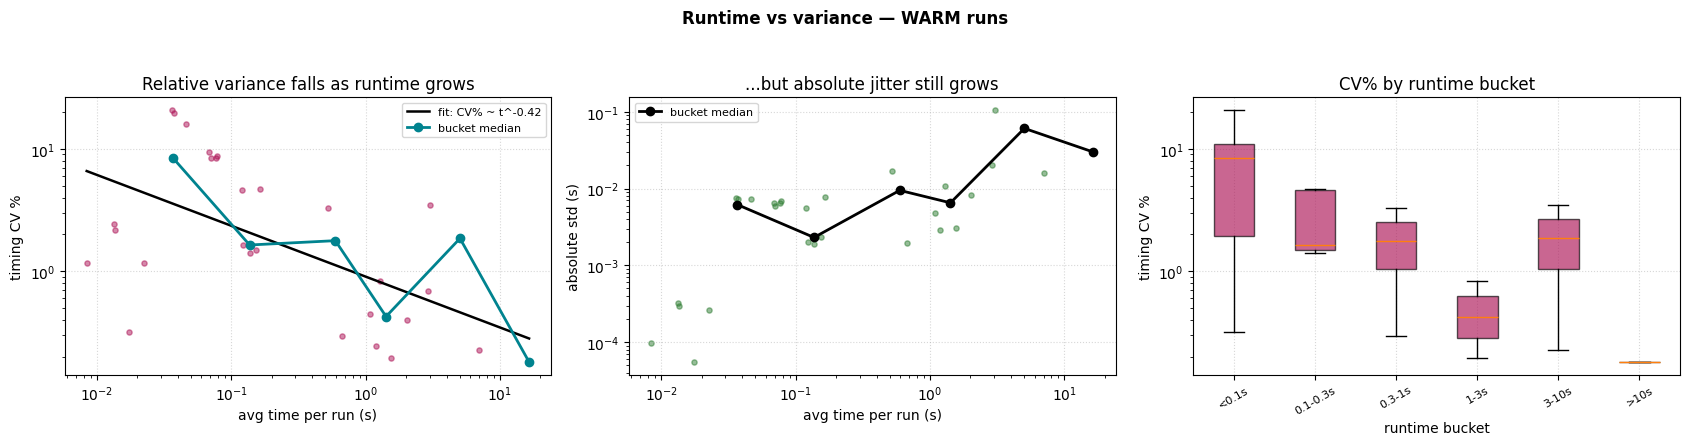

Relative:  rho = -0.543 (p = 4.8e-03)  -> longer queries are proportionally MORE reproducible
Absolute:  rho = +0.648 (p = 7.7e-04)  -> longer queries still wobble by more seconds
Least reproducible bucket: <0.1s (median CV 8.46%)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# --- 1. relative variance vs runtime (log-log) + fit ---
ax = axes[0]
ax.scatter(rv["time_mean"], rv["cv_pct"], s=14, alpha=0.5, color="#ad1457")
xs = np.logspace(np.log10(rv["time_mean"].min()),
                 np.log10(rv["time_mean"].max()), 50)
ax.plot(xs, 10 ** (intercept + slope * np.log10(xs)), color="black", lw=1.8,
        label=f"fit: CV% ~ t^{slope:.2f}")
med = rv.groupby("bucket", observed=True).agg(
    x=("time_mean", "median"), y=("cv_pct", "median"))
ax.plot(med["x"], med["y"], marker="o", color="#00838f", lw=2,
        label="bucket median")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("avg time per run (s)"); ax.set_ylabel("timing CV %")
ax.set_title("Relative variance falls as runtime grows")
ax.legend(fontsize=8)

# --- 2. absolute variance vs runtime ---
ax = axes[1]
ax.scatter(rv["time_mean"], rv["time_std"], s=14, alpha=0.5, color="#2e7d32")
meds = rv.groupby("bucket", observed=True).agg(
    x=("time_mean", "median"), y=("time_std", "median"))
ax.plot(meds["x"], meds["y"], marker="o", color="black", lw=2,
        label="bucket median")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("avg time per run (s)"); ax.set_ylabel("absolute std (s)")
ax.set_title("...but absolute jitter still grows")
ax.legend(fontsize=8)

# --- 3. bucketed CV distribution ---
ax = axes[2]
groups = [rv.loc[rv["bucket"] == b, "cv_pct"].dropna() for b in LABELS]
keep = [(b, g) for b, g in zip(LABELS, groups) if len(g)]
bp = ax.boxplot([g for _, g in keep], patch_artist=True, showfliers=False,
                tick_labels=[b for b, _ in keep])
for patch in bp["boxes"]:
    patch.set_facecolor("#ad1457"); patch.set_alpha(0.65)
ax.set_yscale("log"); ax.set_ylabel("timing CV %")
ax.set_xlabel("runtime bucket")
ax.set_title("CV% by runtime bucket")
ax.tick_params(axis="x", labelsize=8, rotation=30)

for ax in axes:
    ax.grid(linestyle=":", alpha=0.5)
fig.suptitle("Runtime vs variance — WARM runs", fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

# ---- verdict ----
rho_cv, _, p_cv = spearman(rv["time_mean"], rv["cv_pct"])
rho_sd, _, p_sd = spearman(rv["time_mean"], rv["time_std"])
worst = summary["median_CV_pct"].idxmax()
print(f"Relative:  rho = {rho_cv:+.3f} (p = {p_cv:.1e})  -> longer queries are "
      f"proportionally MORE reproducible")
print(f"Absolute:  rho = {rho_sd:+.3f} (p = {p_sd:.1e})  -> longer queries still "
      f"wobble by more seconds")
print(f"Least reproducible bucket: {worst} "
      f"(median CV {summary.loc[worst, 'median_CV_pct']:.2f}%)")

### 9b. Same runtime-vs-variance question on the **cold** runs

The cold counterpart (titled **COLD**), built from each query's cold runs.
With only a few cold runs per query the trend is noisier than the warm one,
but the same relative/absolute split and Spearman verdict are shown.

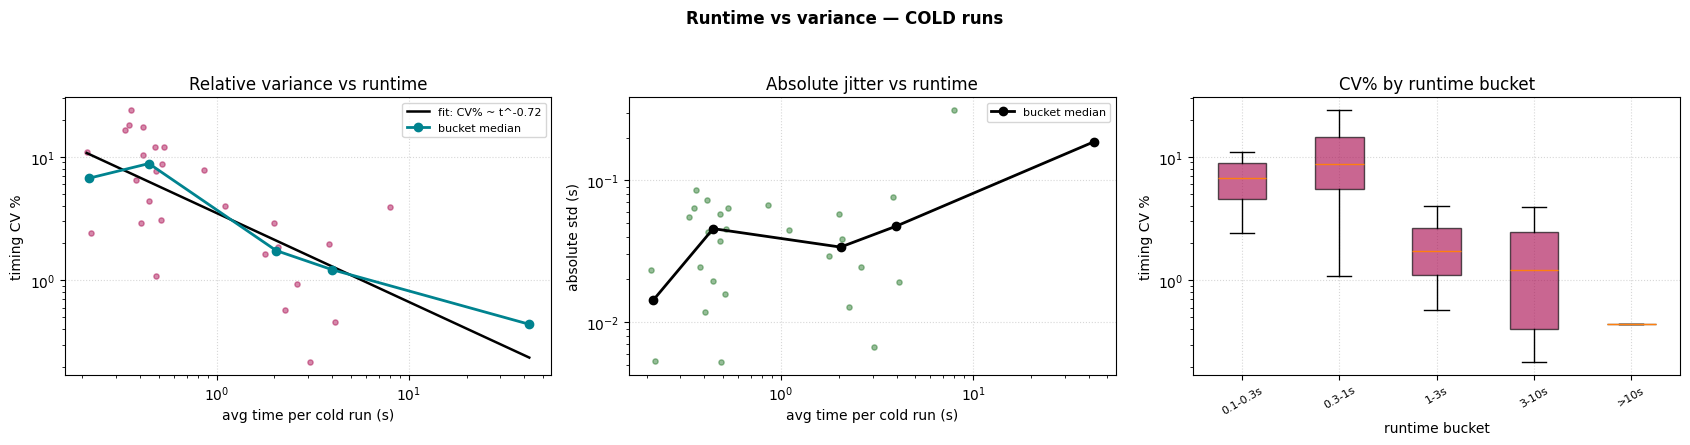

COLD  relative CV%: rho = -0.705 (p = 2.5e-04);  absolute std: rho = +0.162 (p = 4.0e-01)  over 28 cold queries


In [22]:
if not COLD_OK:
    print("No cold data -> no cold runtime-vs-variance figure.")
else:
    rvc = cold.dropna(subset=["cv_pct", "time_mean"]).copy()
    rvc = rvc[rvc["time_mean"] > 0]
    if len(rvc) < 3:
        print(f"COLD: only {len(rvc)} cold quer(y/ies) with variance - "
              "too few for the trend figure.")
    else:
        C_EDGES = [0, 0.1, 0.3, 1, 3, 10, np.inf]
        C_LABELS = ["<0.1s", "0.1-0.3s", "0.3-1s", "1-3s", "3-10s", ">10s"]
        rvc["bucket"] = pd.cut(rvc["time_mean"], bins=C_EDGES,
                               labels=C_LABELS, right=False)
        fitc = rvc[rvc["cv_pct"] > 0]
        if len(fitc) >= 2:
            slope_c, intercept_c = np.polyfit(np.log10(fitc["time_mean"]),
                                              np.log10(fitc["cv_pct"]), 1)
        else:
            slope_c = intercept_c = np.nan

        fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
        # 1. relative variance vs runtime
        ax = axes[0]
        ax.scatter(rvc["time_mean"], rvc["cv_pct"], s=14, alpha=0.5, color="#ad1457")
        if np.isfinite(slope_c):
            xs = np.logspace(np.log10(rvc["time_mean"].min()),
                             np.log10(rvc["time_mean"].max()), 50)
            ax.plot(xs, 10 ** (intercept_c + slope_c * np.log10(xs)),
                    color="black", lw=1.8, label=f"fit: CV% ~ t^{slope_c:.2f}")
        cmed = rvc.groupby("bucket", observed=True).agg(
            x=("time_mean", "median"), y=("cv_pct", "median"))
        ax.plot(cmed["x"], cmed["y"], marker="o", color="#00838f", lw=2,
                label="bucket median")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("avg time per cold run (s)"); ax.set_ylabel("timing CV %")
        ax.set_title("Relative variance vs runtime"); ax.legend(fontsize=8)
        # 2. absolute variance vs runtime
        ax = axes[1]
        ax.scatter(rvc["time_mean"], rvc["time_std"], s=14, alpha=0.5, color="#2e7d32")
        cmeds = rvc.groupby("bucket", observed=True).agg(
            x=("time_mean", "median"), y=("time_std", "median"))
        ax.plot(cmeds["x"], cmeds["y"], marker="o", color="black", lw=2,
                label="bucket median")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("avg time per cold run (s)"); ax.set_ylabel("absolute std (s)")
        ax.set_title("Absolute jitter vs runtime"); ax.legend(fontsize=8)
        # 3. bucketed CV distribution
        ax = axes[2]
        cgroups = [rvc.loc[rvc["bucket"] == b, "cv_pct"].dropna() for b in C_LABELS]
        keep = [(b, g) for b, g in zip(C_LABELS, cgroups) if len(g)]
        if keep:
            bp = ax.boxplot([g for _, g in keep], patch_artist=True,
                            showfliers=False, tick_labels=[b for b, _ in keep])
            for patch in bp["boxes"]:
                patch.set_facecolor("#ad1457"); patch.set_alpha(0.65)
        ax.set_yscale("log"); ax.set_ylabel("timing CV %"); ax.set_xlabel("runtime bucket")
        ax.set_title("CV% by runtime bucket")
        ax.tick_params(axis="x", labelsize=8, rotation=30)
        for ax in axes:
            ax.grid(linestyle=":", alpha=0.5)
        fig.suptitle("Runtime vs variance — COLD runs", fontsize=12,
                     fontweight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

        rho_cv_c, _, p_cv_c = spearman(rvc["time_mean"], rvc["cv_pct"])
        rho_sd_c, _, p_sd_c = spearman(rvc["time_mean"], rvc["time_std"])
        print(f"COLD  relative CV%: rho = {rho_cv_c:+.3f} (p = {p_cv_c:.1e});  "
              f"absolute std: rho = {rho_sd_c:+.3f} (p = {p_sd_c:.1e})  "
              f"over {len(rvc)} cold queries")

## 10. Statistics — power, variance & outliers

*(warm runs only — cold is covered by the companions in §8b and §9b.)*

* **Average power** = average package energy / average runtime (W).
* **Variance / deviation** across the measured runs of every query:
  std, coefficient of variation (CV% = std/mean) and min–max spread.
* **Outliers** via the 1.5 × IQR rule, plus trend checks.

In [23]:
st = data.copy()
st["power_w"] = st["avg_pkg_j"] / st["avg_time_s"]
st = st[st["avg_pkg_j"].notna() & (st["avg_time_s"] > 0)].dropna(subset=["power_w"])

p = st["power_w"]
print(f"Queries with valid average power: {len(p)}/{len(data)}")
print("\nAverage power (W)")
print(f"  mean   = {p.mean():8.2f}")
print(f"  median = {p.median():8.2f}")
print(f"  std    = {p.std():8.2f}")
print(f"  min    = {p.min():8.2f}  ({st.loc[p.idxmin(), 'sql_file']})")
print(f"  max    = {p.max():8.2f}  ({st.loc[p.idxmax(), 'sql_file']})")

print("\nMean power by group (top 10)")
print(st.groupby("group")["power_w"]
        .agg(count="count", mean_W="mean", std_W="std")
        .sort_values("mean_W", ascending=False).head(10).round(2).to_string())

Queries with valid average power: 28/28

Average power (W)
  mean   =    14.66
  median =    12.59
  std    =     4.61
  min    =     9.39  (seq_scan.sql)
  max    =    24.37  (large_merge.sql)

Mean power by group (top 10)
                                     count  mean_W  std_W
group                                                    
estat/06_join_chain                      1   22.00    NaN
estat/08_sorting                         2   21.98   0.28
estat/07_grouping_distinct               2   21.93   0.01
estat/03_join_method                     2   18.34   8.53
warehouse/Core/02_filter_projection      2   14.53   1.55
warehouse/Core/07_grouping_distinct      2   14.00   4.96
warehouse                                6   13.79   2.49
warehouse/Core/08_sorting                2   12.41   2.82
estat/02_filter_project                  2   11.90   0.09
estat/01_scan_access                     2   11.00   1.07


In [24]:
# ---- variance / deviation across the measured runs ----
v = data.dropna(subset=["cv_pct"])
print(f"Run-to-run variability over {len(v)} queries "
      f"({int(v['n_measured'].min())}-{int(v['n_measured'].max())} runs each)")
print("\nTiming CV% (std/mean of elapsed_sec)")
print(v["cv_pct"].describe(percentiles=[.5, .9, .95]).round(3).to_string())
print("\nEnergy CV% (std/mean of rapl_pkg_j)")
print(v["energy_cv_pct"].describe(percentiles=[.5, .9, .95]).round(3).to_string())

STABLE = 5.0
print(f"\nqueries with CV% < 1  : {int((v['cv_pct'] < 1).sum())}")
print(f"queries with CV% >= {STABLE:g}: {int((v['cv_pct'] >= STABLE).sum())} "
      f"(noisy - treat their numbers with care)")

print("\nLeast reproducible queries:")
print(v.nlargest(12, "cv_pct")[
    ["group", "sql_file", "time_mean", "time_std", "cv_pct",
     "spread_pct", "energy_cv_pct"]].round(3).to_string(index=False))

Run-to-run variability over 28 queries (3-3 runs each)

Timing CV% (std/mean of elapsed_sec)
count    28.000
mean      4.396
std       5.886
min       0.182
50%       1.572
90%      11.383
95%      18.453
max      20.790

Energy CV% (std/mean of rapl_pkg_j)
count    28.000
mean      2.299
std       3.403
min       0.300
50%       1.495
90%       3.780
95%       4.959
max      18.517

queries with CV% < 1  : 10
queries with CV% >= 5: 7 (noisy - treat their numbers with care)

Least reproducible queries:
                              group               sql_file  time_mean  time_std  cv_pct  spread_pct  energy_cv_pct
      warehouse/Core/01_scan_access           seq_scan.sql      0.036     0.008  20.790      37.394          3.630
                          warehouse    SelectiveFilter.sql      0.037     0.007  19.790      36.739          0.743
          warehouse/Core/08_sorting          sort_topn.sql      0.046     0.007  15.970      30.151          1.696
warehouse/Core/07_grouping_disti

IQR fence: [1.47, 26.49] W   ->  28 outlier(s)
group sql_file  avg_time_s  avg_pkg_j  power_w
  NaN      NaN         NaN        NaN   24.367
  NaN      NaN         NaN        NaN   22.181
  NaN      NaN         NaN        NaN   21.997
  NaN      NaN         NaN        NaN   21.941
  NaN      NaN         NaN        NaN   21.929
  NaN      NaN         NaN        NaN   21.786
  NaN      NaN         NaN        NaN   17.511
  NaN      NaN         NaN        NaN   16.976
  NaN      NaN         NaN        NaN   16.742
  NaN      NaN         NaN        NaN   15.633
  NaN      NaN         NaN        NaN   14.409
  NaN      NaN         NaN        NaN   13.434
  NaN      NaN         NaN        NaN   13.024
  NaN      NaN         NaN        NaN   12.669
  NaN      NaN         NaN        NaN   12.505

corr(power, runtime)  = +0.043
  |r| < 0.2 none | 0.2-0.5 weak | 0.5-0.8 moderate | > 0.8 strong
  (runtime vs variance is analysed in detail in section 9)


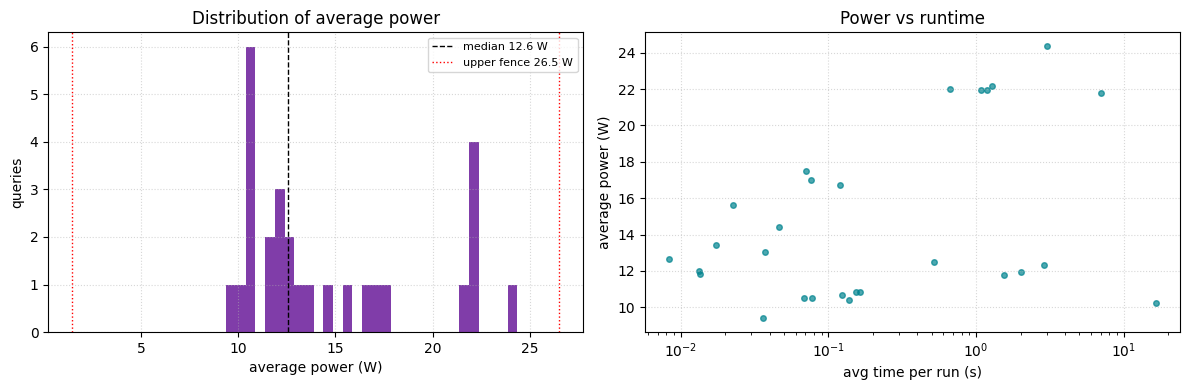

In [25]:
# ---- outliers + trends ----
q1, q3 = p.quantile(0.25), p.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = st[(p < lo) | (p > hi)].assign(power_w=p).sort_values("power_w",
                                                            ascending=False)
print(f"IQR fence: [{lo:.2f}, {hi:.2f}] W   ->  {len(out)} outlier(s)")
print(out[["group", "sql_file", "avg_time_s", "avg_pkg_j", "power_w"]]
      .head(15).round(3).to_string(index=False))

corr_rt = st["power_w"].corr(st["avg_time_s"])
print(f"\ncorr(power, runtime)  = {corr_rt:+.3f}")
print("  |r| < 0.2 none | 0.2-0.5 weak | 0.5-0.8 moderate | > 0.8 strong")
print("  (runtime vs variance is analysed in detail in section 9)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(p, bins=30, color="#6a1b9a", alpha=0.85)
axes[0].axvline(p.median(), color="k", ls="--", lw=1,
                label=f"median {p.median():.1f} W")
axes[0].axvline(hi, color="r", ls=":", lw=1, label=f"upper fence {hi:.1f} W")
axes[0].axvline(lo, color="r", ls=":", lw=1)
axes[0].set_xlabel("average power (W)"); axes[0].set_ylabel("queries")
axes[0].set_title("Distribution of average power"); axes[0].legend(fontsize=8)

axes[1].scatter(st["avg_time_s"], p, s=16, alpha=0.7, color="#00838f")
axes[1].set_xscale("log"); axes[1].set_xlabel("avg time per run (s)")
axes[1].set_ylabel("average power (W)"); axes[1].set_title("Power vs runtime")

for ax in axes:
    ax.grid(linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

## 11. Which queries are most affected by the Postgres version?

For every query measured under more than one `pg_version`, the **effect of
versioning** is the ratio between the slowest and fastest version:

$$\text{fold} = \frac{\max_v\ metric}{\min_v\ metric}$$

Each query's per-version values are drawn relative to its own fastest
version, so the fastest bar is always 1x and the others show the
multiplier. The queries with the biggest gap sit at the top — these are
where upgrading (or downgrading) Postgres changes runtime or energy the
most. A very large fold usually means a behavioural change between versions
(e.g. a planner change, or a function that behaves differently), not just
noise.

*(This compares whatever `pg_version`s are in the selected `RUN_IDS`; add
another version's run id to bring it into the comparison.)*

Postgres versions in play: ['14.23', '16.14', '18.4']
database sizes present: ['1 GB', '2 GB', '5 GB']
(each query is compared across versions WITHIN its own db size)


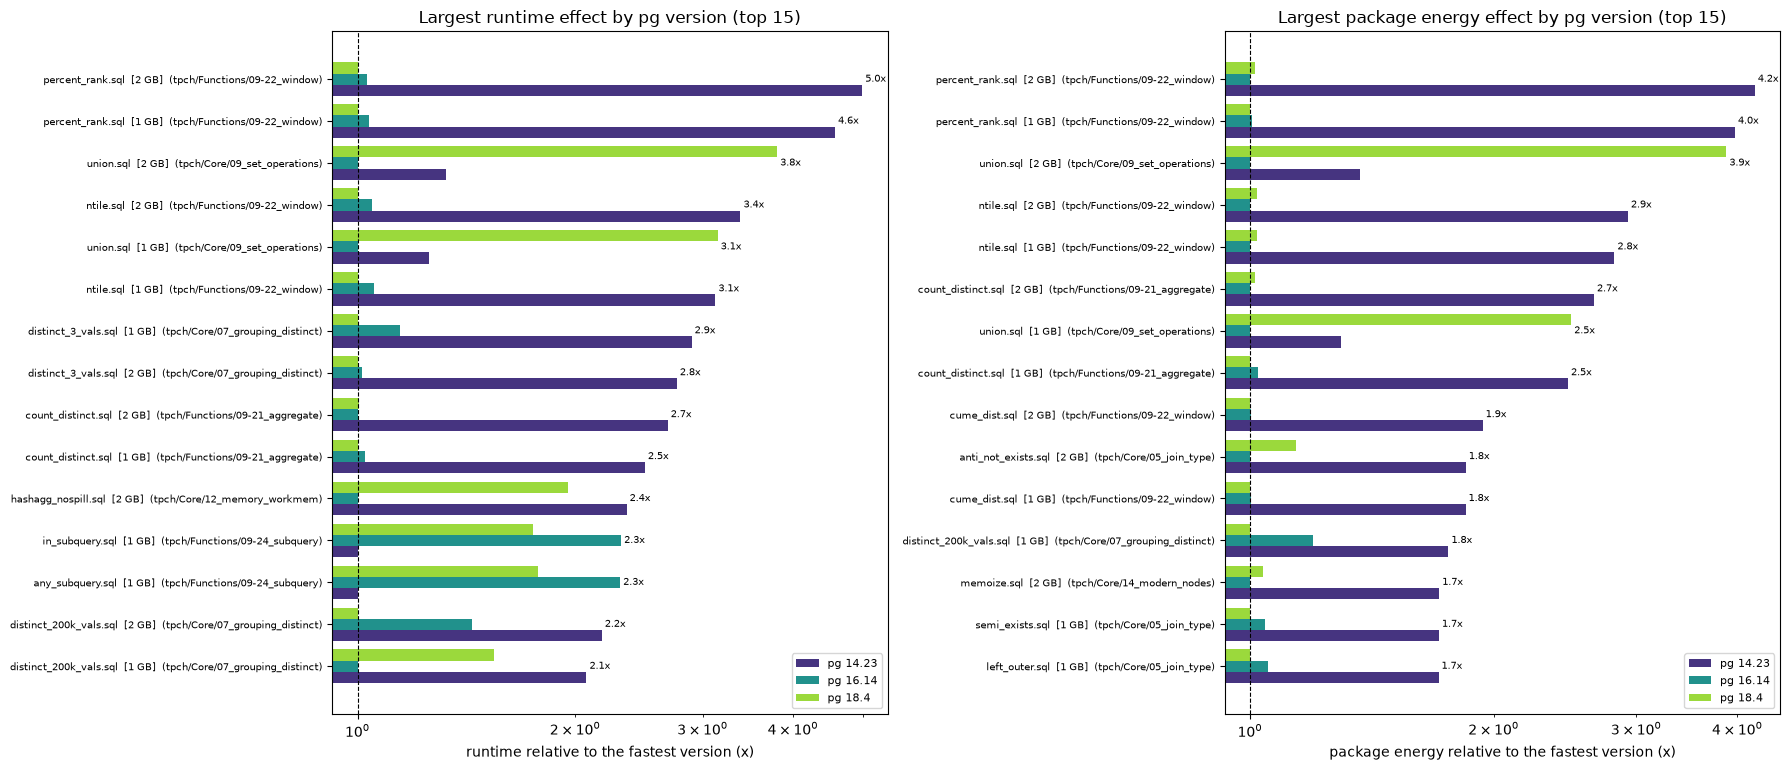


Top 15 queries by runtime sensitivity to pg version (seconds per copy):
                                                        query db_size               sql_file                          group  14.23  16.14  18.4  fold faster_in
         queries/tpch/Functions/09-22_window/percent_rank.sql    2 GB       percent_rank.sql    tpch/Functions/09-22_window 47.998  9.910 9.627 4.986      18.4
         queries/tpch/Functions/09-22_window/percent_rank.sql    1 GB       percent_rank.sql    tpch/Functions/09-22_window 21.982  4.986 4.809 4.572      18.4
                queries/tpch/Core/09_set_operations/union.sql    2 GB              union.sql    tpch/Core/09_set_operations  3.331  2.511 9.548 3.802     16.14
                queries/tpch/Functions/09-22_window/ntile.sql    2 GB              ntile.sql    tpch/Functions/09-22_window 20.697  6.398 6.117 3.383      18.4
                queries/tpch/Core/09_set_operations/union.sql    1 GB              union.sql    tpch/Core/09_set_operations  1.

In [ ]:
# # DONT RUN!! unless we add data between pg versions

# # map each cohort to its single Postgres version, then onto every row
# cohort_pg = timing.groupby("cohort")["pg_version"].agg(
#     lambda s: sorted(set(s.dropna()))[0])
# data["pg_version"] = data["cohort"].map(cohort_pg).astype(str)

# VERSIONS = sorted(data["pg_version"].dropna().unique())
# print(f"Postgres versions in play: {VERSIONS}")
# sizes = sorted(data["db_size"].dropna().unique())
# print(f"database sizes present: {sizes}")
# print("(each query is compared across versions WITHIN its own db size)")

# KEYCOLS = ["query", "db_size"]


# def version_effect(metric):
#     """pivot (query, db_size) x pg_version, keep rows seen in >=2 versions."""
#     piv = data.pivot_table(index=KEYCOLS, columns="pg_version",
#                            values=metric, aggfunc="mean")
#     piv = piv[piv.notna().sum(axis=1) >= 2]
#     piv = piv[(piv > 0).all(axis=1)]                 # ratios need positives
#     fold = piv.max(axis=1) / piv.min(axis=1)
#     return piv, fold.sort_values(ascending=False)


# meta = data.drop_duplicates(KEYCOLS).set_index(KEYCOLS)[["group", "sql_file"]]


# def row_label(k):
#     g, f = meta.loc[k, "group"], meta.loc[k, "sql_file"]
#     tag = f"  [{k[1]}]" if MULTI_SIZE else ""
#     return f"{f}{tag}  ({g})"


# TOP_N = 15
# _, fold0 = version_effect("avg_time_s")

# if len(VERSIONS) < 2 or len(fold0) == 0:
#     print("\nFewer than two versions share any query - nothing to compare. "
#           "Add another version's run id to RUN_IDS.")
# else:
#     colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(VERSIONS)))
#     panels = [("avg_time_s", "runtime"), ("avg_pkg_j", "package energy")]
#     fig, axes = plt.subplots(1, len(panels),
#                              figsize=(9 * len(panels), 0.42 * TOP_N + 1.5))

#     for ax, (metric, nice) in zip(axes, panels):
#         piv, fold = version_effect(metric)
#         top = fold.head(TOP_N).index[::-1]                 # biggest at top
#         rel = piv.loc[top].div(piv.loc[top].min(axis=1), axis=0)

#         ybase = np.arange(len(top))
#         bh = 0.8 / len(VERSIONS)
#         for j, ver in enumerate(VERSIONS):
#             off = (j - (len(VERSIONS) - 1) / 2) * bh
#             ax.barh(ybase + off, rel[ver].to_numpy(dtype=float), height=bh,
#                     color=colours[j], label=f"pg {ver}")

#         ax.axvline(1.0, color="k", lw=0.8, ls="--")
#         ax.set_xscale("log")
#         ax.set_xlabel(f"{nice} relative to the fastest version (x)")
#         ax.set_yticks(ybase)
#         ax.set_yticklabels([row_label(k) for k in top], fontsize=7)
#         for i, k in enumerate(top):
#             ax.text(fold[k], i, f" {fold[k]:.1f}x", va="center", fontsize=7)
#         ax.set_title(f"Largest {nice} effect by pg version (top {TOP_N})")
#         ax.legend(fontsize=8, loc="lower right")
#         ax.grid(axis="x", linestyle=":", alpha=0.5)

#     fig.tight_layout()
#     plt.show()

#     # printed leaderboard for runtime
#     piv, fold = version_effect("avg_time_s")
#     lead = piv.loc[fold.head(TOP_N).index].copy()
#     lead.insert(0, "sql_file", [meta.loc[k, "sql_file"] for k in lead.index])
#     lead.insert(1, "group", [meta.loc[k, "group"] for k in lead.index])
#     lead["fold"] = fold.head(TOP_N).to_numpy()
#     lead["faster_in"] = piv.loc[lead.index].idxmin(axis=1).to_numpy()
#     lead = lead.reset_index()
#     print(f"\nTop {TOP_N} queries by runtime sensitivity to pg version "
#           f"(seconds per copy):")
#     print(lead.round(3).to_string(index=False))

## 12. Workload & planner behaviour (new sample columns)

The samples CSV now records how much data each query actually touched
(`rows_processed`, `bytes_processed`), what the planner *expected*
(`rows_estimated` vs `rows_out`), the plan shape (`plan_nodes`,
`scan_nodes`) and parallelism (`workers_launched`). This lets us relate
energy to the volume of data moved, and spot where the planner
mis-estimates.

28 queries with workload data
energy vs bytes processed : Spearman rho = +0.931 (p=1.3e-06)
time   vs bytes processed : Spearman rho = +0.918
energy efficiency: median 239 J per GB processed (IQR 135-308)
parallel queries (workers_launched > 0): 13/28


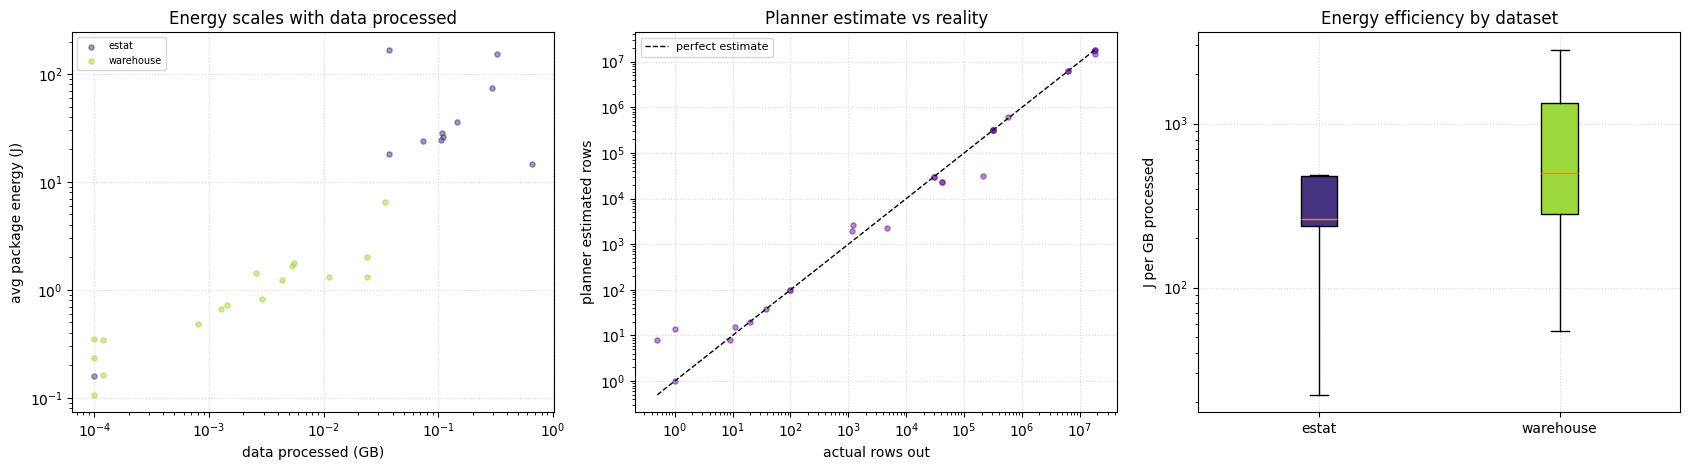


Worst planner mis-estimates (estimated / actual rows):
  dataset                               group               sql_file   rows_out  rows_estimated  est_ratio  avg_time_s
warehouse warehouse/Core/02_filter_projection   high_selectivity.sql        1.0            14.0      14.00        0.02
warehouse                           warehouse     WindowFunction.sql   214904.0         31885.0       0.15        0.52
warehouse                           warehouse    SelectiveFilter.sql     1213.0          2599.0       2.14        0.04
    estat             estat/02_filter_project   high_selectivity.sql     4664.0          2236.0       0.48        0.01
warehouse warehouse/Core/07_grouping_distinct distinct_high_card.sql    41334.0         22847.0       0.55        0.07
warehouse                           warehouse      FullTableScan.sql    41334.0         22847.0       0.55        0.16
    estat          estat/07_grouping_distinct distinct_high_card.sql     1180.0          1938.0       1.64     

In [27]:
if not HAS_WORKLOAD:
    print("This samples CSV has no workload columns - section skipped.")
else:
    w = data.dropna(subset=["bytes_processed"]).copy()
    w["gb_proc"] = w["bytes_processed"] / 1e9
    w["j_per_gb"] = w["avg_pkg_j"] / w["gb_proc"].replace(0, np.nan)
    w["est_ratio"] = w["rows_estimated"] / w["rows_out"].replace(0, np.nan)

    rho_e, _, p_e = spearman(w["bytes_processed"], w["avg_pkg_j"])
    rho_t, _, _ = spearman(w["bytes_processed"], w["avg_time_s"])
    eff = w[w["gb_proc"] > 0.01]["j_per_gb"]
    n_par = int((w["workers_launched"] > 0).sum())
    print(f"{len(w)} queries with workload data")
    print(f"energy vs bytes processed : Spearman rho = {rho_e:+.3f} (p={p_e:.1e})")
    print(f"time   vs bytes processed : Spearman rho = {rho_t:+.3f}")
    print(f"energy efficiency: median {eff.median():.0f} J per GB processed "
          f"(IQR {eff.quantile(.25):.0f}-{eff.quantile(.75):.0f})")
    print(f"parallel queries (workers_launched > 0): {n_par}/{len(w)}")

    # colour/group by dataset size when several are present, else by version
    #cat_col = "db_size" if MULTI_SIZE else "pg_version"
    cat_col = "dataset"
    pref = ""
    cats = sorted(w[cat_col].dropna().unique())
    #pref = "" if MULTI_SIZE else "pg "
    #if MULTI_SIZE:
    #    cats = sorted(w[cat_col].dropna().unique(),
    #                  key=lambda l: float(re.match(r"([\d.]+)", str(l)).group(1)))
    #else:
    #    cats = sorted(w[cat_col].dropna().unique())
    colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(cats)))

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    # 1. energy vs data processed
    ax = axes[0]
    for cv, c in zip(cats, colours):
        s = w[w[cat_col] == cv]
        ax.scatter(s["gb_proc"].clip(lower=1e-4), s["avg_pkg_j"], s=14,
                   alpha=0.5, color=c, label=f"{pref}{cv}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("data processed (GB)"); ax.set_ylabel("avg package energy (J)")
    ax.set_title("Energy scales with data processed"); ax.legend(fontsize=7)

    # 2. planner estimate vs actual rows
    ax = axes[1]
    act = w["rows_out"].clip(lower=0.5)
    est = w["rows_estimated"].clip(lower=0.5)
    ax.scatter(act, est, s=14, alpha=0.5, color="#6a1b9a")
    lim = [min(act.min(), est.min()), max(act.max(), est.max())]
    ax.plot(lim, lim, "k--", lw=1, label="perfect estimate")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("actual rows out"); ax.set_ylabel("planner estimated rows")
    ax.set_title("Planner estimate vs reality"); ax.legend(fontsize=8)

    # 3. energy efficiency by dataset (or version)
    ax = axes[2]
    eff_by = [w.loc[w[cat_col] == cv, "j_per_gb"].replace(
        [np.inf, -np.inf], np.nan).dropna() for cv in cats]
    keep = [(cv, e) for cv, e in zip(cats, eff_by) if len(e)]
    bp = ax.boxplot([e for _, e in keep], patch_artist=True, showfliers=False,
                    tick_labels=[f"{pref}{cv}" for cv, _ in keep])
    for patch, c in zip(bp["boxes"], colours):
        patch.set_facecolor(c)
    ax.set_yscale("log"); ax.set_ylabel("J per GB processed")
    ax.set_title(f"Energy efficiency by dataset")

    for ax in axes:
        ax.grid(linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

    mis = w.dropna(subset=["est_ratio"])
    mis = mis[mis["est_ratio"] > 0].assign(
        log_err=lambda d: np.abs(np.log10(d["est_ratio"])))
    top = mis.nlargest(12, "log_err")[
        ["dataset", "group", "sql_file", "rows_out", "rows_estimated",
         "est_ratio", "avg_time_s"]]
    print("\nWorst planner mis-estimates (estimated / actual rows):")
    print(top.round(2).to_string(index=False))

## 13. Database catalog — table & index sizes

The catalog files record the on-disk size of every relation (tables `r`,
indexes `i`) for each dataset size. This shows the real database footprint
behind each scale factor and how it grows from one dataset to the next.

Database footprint per dataset :
                                               heap  index  total  tables
dataset                     run_id                                       
query_catalog_estat.csv     E10DBED08E2A894C  1.387  1.452  2.839     6.0
query_catalog_warehouse.csv F0835FB40824C98A  0.023  0.012  0.035     3.0

overall index overhead: 103.8% of heap size


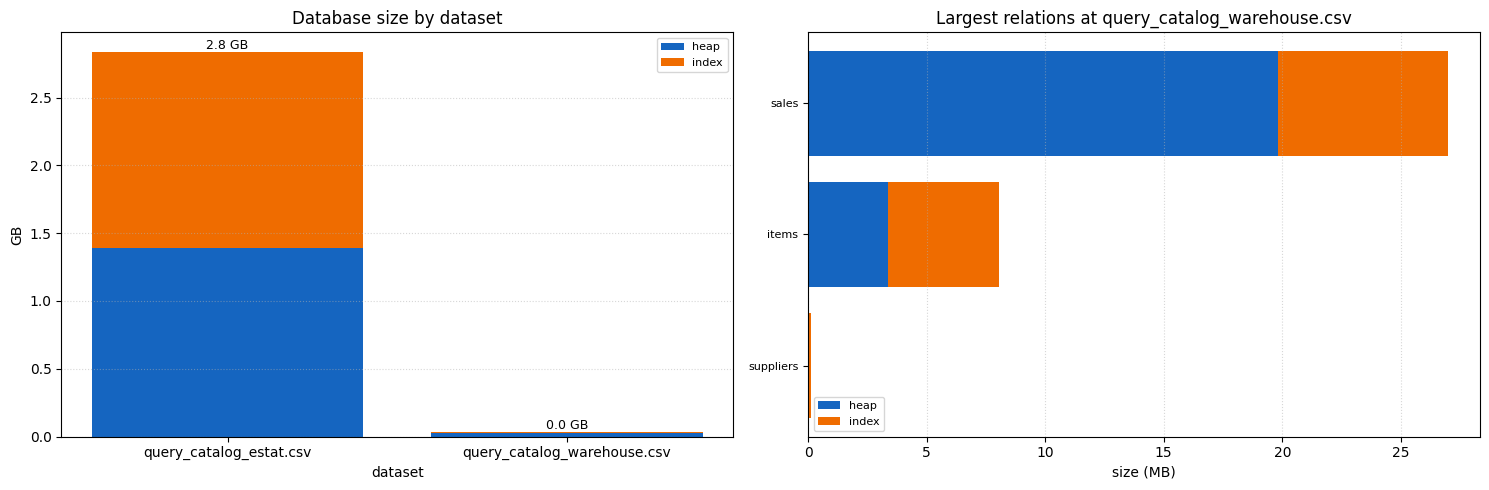

In [28]:
if catalog_all is None:
    print("No catalog file was found - section skipped.")
else:
    cat = catalog_all.copy()
    for c in ["reltuples", "relpages", "heap_bytes", "index_bytes", "total_bytes"]:
        cat[c] = pd.to_numeric(cat[c], errors="coerce")
    cat = cat[cat["run_id"].isin(set(timing["run_id"]))].copy()  # analysed runs
    cat["pg_version"] = cat["pg_version"].astype(str)
    tables = cat[cat["relkind"] == "r"].copy()

    def size_key(lbl):
        m = re.match(r"([\d.]+)", str(lbl))
        return float(m.group(1)) if m else 0.0

    # DB footprint per dataset: sum tables within each run
    per = (tables.groupby(["dataset", "run_id"])
           .agg(heap=("heap_bytes", "sum"), index=("index_bytes", "sum"),
                total=("total_bytes", "sum"), tables=("relname", "nunique"))
           .groupby(level=[0, 1]).mean())          # avg across runs of a size+ver
    per_gb = (per[["heap", "index", "total"]] / 1e9).round(3)
    per_gb["tables"] = per["tables"].round(0)
    print("Database footprint per dataset :")
    print(per_gb.to_string())
    idx_ratio = 100 * tables["index_bytes"].sum() / tables["heap_bytes"].sum()
    print(f"\noverall index overhead: {idx_ratio:.1f}% of heap size")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. total DB size by dataset size (mean across versions), heap+index
    ax = axes[0]
    sizes = sorted(tables["dataset"].dropna().unique())
    per_size = (tables.groupby(["dataset", "run_id"])
                .agg(heap=("heap_bytes", "sum"), index=("index_bytes", "sum"))
                .groupby(level=0).mean())
    heap = [per_size.loc[s, "heap"] / 1e9 for s in sizes]
    idx = [per_size.loc[s, "index"] / 1e9 for s in sizes]
    x = np.arange(len(sizes))
    ax.bar(x, heap, color="#1565c0", label="heap")
    ax.bar(x, idx, bottom=heap, color="#ef6c00", label="index")
    for xi, (h, i) in enumerate(zip(heap, idx)):
        ax.text(xi, h + i, f"{h + i:.1f} GB", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(sizes)
    ax.set_ylabel("GB"); ax.set_xlabel("dataset")
    ax.set_title("Database size by dataset")
    ax.legend(fontsize=8)

    # 2. largest relations at the biggest dataset size
    ax = axes[1]
    biggest = sizes[-1]
    big = (tables[tables["dataset"] == biggest].groupby("relname")
           .agg(heap=("heap_bytes", "max"), index=("index_bytes", "max"),
                total=("total_bytes", "max"))
           .nlargest(12, "total").iloc[::-1])
    y = np.arange(len(big))
    ax.barh(y, big["heap"] / 1e6, color="#1565c0", label="heap")
    ax.barh(y, big["index"] / 1e6, left=big["heap"] / 1e6, color="#ef6c00",
            label="index")
    ax.set_yticks(y); ax.set_yticklabels(big.index, fontsize=8)
    ax.set_xlabel("size (MB)")
    ax.set_title(f"Largest relations at {biggest}")
    ax.legend(fontsize=8)

    axes[0].grid(axis="y", linestyle=":", alpha=0.5)
    axes[1].grid(axis="x", linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

## 14. Which relations do queries target?

The samples `relations` column lists the tables and indexes each query
touches (`;`-separated). Counting distinct queries per relation shows which
parts of the schema the benchmark actually exercises.

28 queries touch 10 real relations (9 tables, 1 indexes); 0 also hit derived/subquery relations
real relations per query: median 1, max 6

most-targeted:
                                                           name  kind  n_queries
                                                          sales table         17
                                             fact_capital_stock table         11
                                                          items table          7
                                                        dim_geo table          3
                                                      suppliers table          3
                                                      dim_asset table          1
                                                    dim_na_item table          1
fact_capital_stock_year_geo_id_unit_id_nace_id_asset_id_na__key index          1


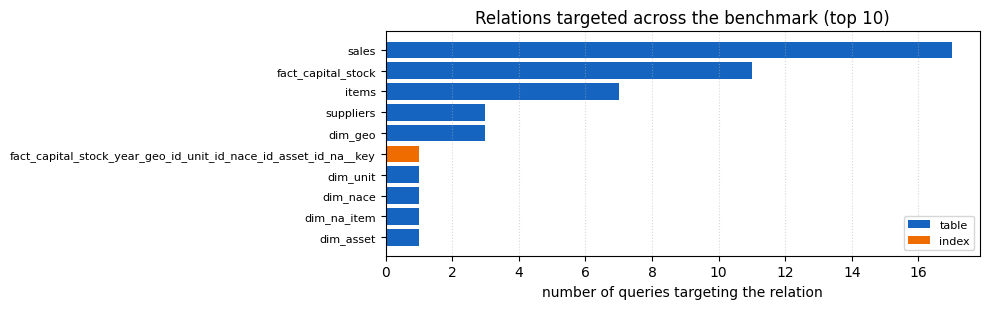

In [29]:
if "relations" not in meas.columns:
    print("This samples CSV has no 'relations' column - section skipped.")
else:
    # one relations value per query (nearly constant across runs)
    rel = meas.drop_duplicates("query")[["query", "relations"]].dropna()
    ex = rel.assign(name=rel["relations"].str.split(r"[;,]")).explode("name")
    ex["name"] = ex["name"].str.strip()
    ex = ex[ex["name"] != ""]

    # classify against the catalog; anything unknown (CTE/subquery aliases
    # like *SELECT*, VALUES, numeric ids) is plan-internal "derived"
    if catalog_all is not None:
        tset = set(catalog_all.loc[catalog_all["relkind"] == "r", "relname"])
        iset = set(catalog_all.loc[catalog_all["relkind"] == "i", "relname"])
        ex["kind"] = np.where(ex["name"].isin(tset), "table",
                     np.where(ex["name"].isin(iset), "index", "derived"))
    else:
        ex["kind"] = np.where(ex["name"].str.startswith("idx"), "index", "table")

    real = ex[ex["kind"] != "derived"]
    n_derived_q = ex.loc[ex["kind"] == "derived", "query"].nunique()

    counts = (real.groupby(["name", "kind"]).size()
              .reset_index(name="n_queries").sort_values("n_queries"))
    per_query = real.groupby("query").size()
    print(f"{rel['query'].nunique()} queries touch {real['name'].nunique()} "
          f"real relations "
          f"({counts['kind'].eq('table').sum()} tables, "
          f"{counts['kind'].eq('index').sum()} indexes); "
          f"{n_derived_q} also hit derived/subquery relations")
    print(f"real relations per query: median {int(per_query.median())}, "
          f"max {int(per_query.max())}")
    print(f"\nmost-targeted:\n"
          f"{counts.sort_values('n_queries', ascending=False).head(8).to_string(index=False)}")

    colour = {"table": "#1565c0", "index": "#ef6c00"}
    top = counts.tail(25)                            # keep the chart short
    fig, ax = plt.subplots(figsize=(10, max(3, 0.32 * len(top))))
    ax.barh(np.arange(len(top)), top["n_queries"],
            color=[colour[k] for k in top["kind"]])
    ax.set_yticks(np.arange(len(top)))
    ax.set_yticklabels(top["name"], fontsize=8)
    ax.set_xlabel("number of queries targeting the relation")
    ax.set_title(f"Relations targeted across the benchmark (top {len(top)})")
    handles = [Patch(facecolor=c, label=k) for k, c in colour.items()]
    ax.legend(handles=handles, fontsize=8, loc="lower right")
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

## 15. Caching effect — fixed vs marginal cost (slope file)

Running a query as a batch of *n* copies and fitting

$$\text{total} = \text{intercept} + \text{slope}\times n$$

separates two costs:

* **intercept** — the one-time cost paid once per batch: query planning,
  connection setup, and the **cold buffer cache** on the first copy;
* **slope** — the *warm* marginal cost of one more copy, once the data is
  already cached.

So `slope` is what a query costs when its data is hot, and
`intercept / wall_small` is the fraction of a single cold run that caching
removes on repeat. A query with a big **warm speedup** (`wall_small /
slope`) benefits a lot from caching; one where `slope` dominates does
real work on every execution and barely benefits.

In [30]:
if slope_all is None:
    print("No slope file was found - section skipped.")
else:
    sl = slope_all[slope_all["run_id"].isin(set(timing["run_id"]))].copy()
    scol = ["n_small", "n_large", "wall_small_sec", "wall_large_sec",
            "slope_wall_sec", "intercept_wall_sec", "pkg_small_j",
            "pkg_large_j", "slope_pkg_j", "intercept_pkg_j", "failed"]
    for c in scol:
        sl[c] = pd.to_numeric(sl[c], errors="coerce")
    sl = sl[sl["failed"].fillna(0) == 0]
    sl["cohort"] = sl["run_id"].map(run2cohort)
    sl["sql_file"] = sl["query"].astype(str).str.split("/").str[-1]
    sl["dataset"] = sl["cohort"].map(cohort_dataset)
    #sl["db_size"] = sl["cohort"].map(cohort_size)

    # per (cohort, query) averages, plus pg / size tags
    g = sl.groupby(["cohort", "query"]).agg(
        sql_file=("sql_file", "first"), #pg=("pg_version", "first"),
        #db_size=("db_size", "first"),
        dataset=("dataset", "first"),
        wall_small=("wall_small_sec", "mean"),
        slope_wall=("slope_wall_sec", "mean"),
        intercept_wall=("intercept_wall_sec", "mean"),
        slope_pkg=("slope_pkg_j", "mean"),
        intercept_pkg=("intercept_pkg_j", "mean"),
        pkg_small=("pkg_small_j", "mean")).reset_index()
    g = g[(g["slope_wall"] > 0) & (g["wall_small"] > 0)]
    g["warm_speedup"] = g["wall_small"] / g["slope_wall"]
    g["fixed_frac"] = (g["intercept_wall"] / g["wall_small"]).clip(0, 1)

    # per (query, size) pooled view for the curves / summary (not across sizes)
    gq = g.groupby(["query", "dataset"]).agg(
        sql_file=("sql_file", "first"),
        wall_small=("wall_small", "mean"), slope_wall=("slope_wall", "mean"),
        intercept_wall=("intercept_wall", "mean"),
        warm_speedup=("warm_speedup", "mean")).reset_index()
    gq["label"] = gq["sql_file"] + (("  [" + gq["dataset"] + "]")
                                    if MULTI_DATASET else "")

    n_cache = int((gq["warm_speedup"] >= 2).sum())
    print(f"{len(gq)} queries fitted")
    print(f"warm speedup (cold single / warm marginal): "
          f"median {gq['warm_speedup'].median():.1f}x, "
          f"p90 {gq['warm_speedup'].quantile(.9):.1f}x, "
          f"max {gq['warm_speedup'].max():.0f}x")
    print(f"cache-sensitive queries (>=2x warm speedup): {n_cache}/{len(gq)}")
    print(f"median fixed-cost fraction of a cold run: {g['fixed_frac'].median():.2f}")

27 queries fitted
warm speedup (cold single / warm marginal): median 1.5x, p90 4.6x, max 11x
cache-sensitive queries (>=2x warm speedup): 7/27
median fixed-cost fraction of a cold run: 0.33


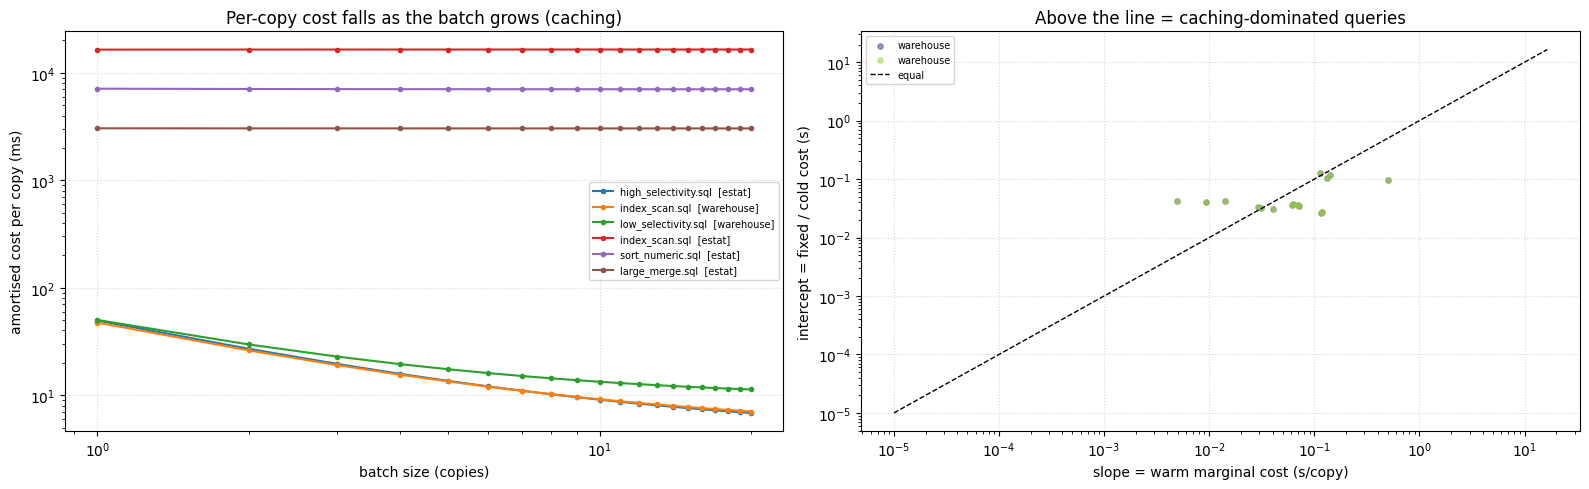

In [31]:
if slope_all is not None:
    vers = sorted(g["dataset"].dropna().unique())
    colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(vers)))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --- 1. amortisation curves for a few representative queries ---
    ax = axes[0]
    reps = pd.concat([gq.nlargest(3, "warm_speedup"),
                      gq.nlargest(3, "slope_wall")]).drop_duplicates(
                          ["query", "dataset"])
    ns = np.arange(1, 21)
    for _, r in reps.iterrows():
        per_copy = r["intercept_wall"] / ns + r["slope_wall"]
        ax.plot(ns, per_copy * 1000, marker=".", label=r["label"])
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("batch size (copies)")
    ax.set_ylabel("amortised cost per copy (ms)")
    ax.set_title("Per-copy cost falls as the batch grows (caching)")
    ax.legend(fontsize=7)

    # --- 2. fixed (intercept) vs marginal (slope) wall time ---
    ax = axes[1]
    for ver, c in zip(vers, colours):
        s = g[g["dataset"] == ds]
        ax.scatter(s["slope_wall"].clip(lower=1e-5),
                   s["intercept_wall"].clip(lower=1e-5),
                   s=14, alpha=0.5, color=c, label= ds)
    lim = [1e-5, max(g["slope_wall"].max(), g["intercept_wall"].max())]
    ax.plot(lim, lim, "k--", lw=1, label="equal")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("slope = warm marginal cost (s/copy)")
    ax.set_ylabel("intercept = fixed / cold cost (s)")
    ax.set_title("Above the line = caching-dominated queries")
    ax.legend(fontsize=7)

    for ax in axes:
        ax.grid(linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

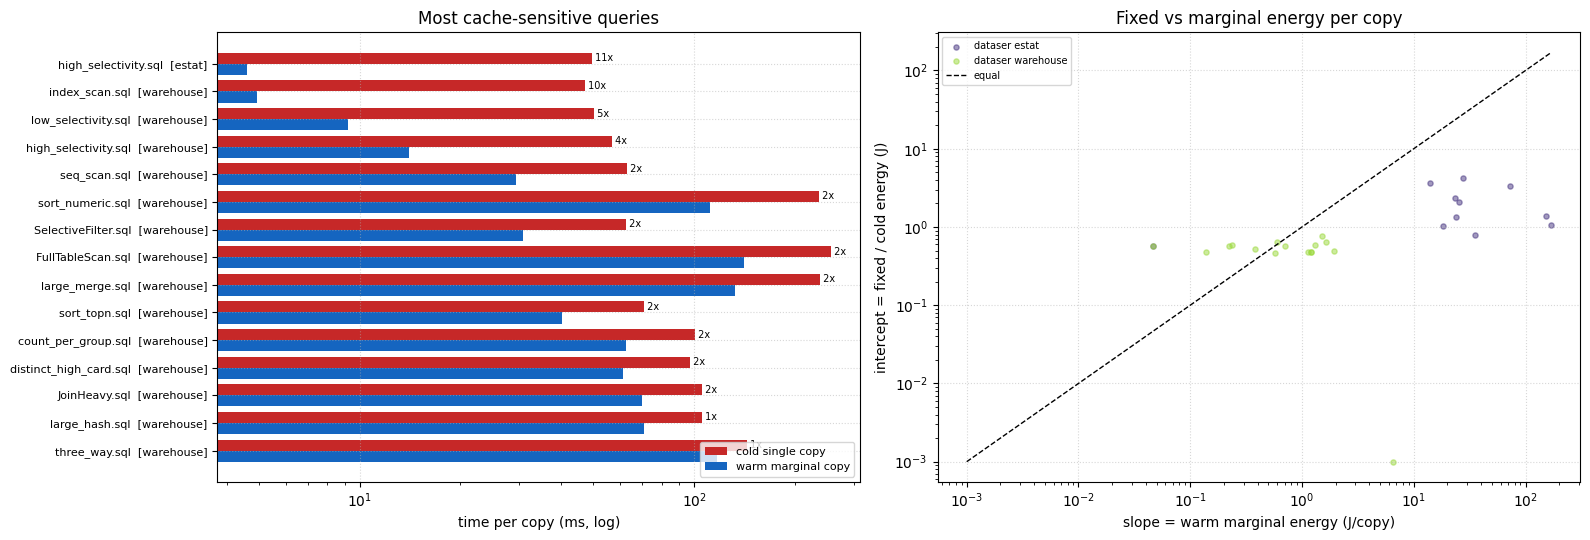

Most cache-sensitive queries (largest warm speedup):
              sql_file   dataset  warm_speedup  wall_small_ms  slope_ms
  high_selectivity.sql     estat          11.0          49.48     4.587
        index_scan.sql warehouse          10.0          47.33     4.927
   low_selectivity.sql warehouse           5.0          50.10     9.250
  high_selectivity.sql warehouse           4.0          56.72    14.058
          seq_scan.sql warehouse           2.0          63.20    29.406
      sort_numeric.sql warehouse           2.0         236.77   112.003
   SelectiveFilter.sql warehouse           2.0          62.58    30.872
     FullTableScan.sql warehouse           2.0         256.46   140.837
       large_merge.sql warehouse           2.0         238.57   132.245
         sort_topn.sql warehouse           2.0          70.99    40.265
   count_per_group.sql warehouse           2.0         100.52    62.781
distinct_high_card.sql warehouse           2.0          97.44    61.296


In [33]:
if slope_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

    # --- 1. most cache-sensitive queries: cold single vs warm marginal ---
    ax = axes[0]
    top = gq.nlargest(15, "warm_speedup").iloc[::-1]
    y = np.arange(len(top)); h = 0.4
    ax.barh(y + h/2, top["wall_small"] * 1000, height=h,
            color="#c62828", label="cold single copy")
    ax.barh(y - h/2, top["slope_wall"] * 1000, height=h,
            color="#1565c0", label="warm marginal copy")
    for i, sp in enumerate(top["warm_speedup"]):
        ax.text(top["wall_small"].iloc[i] * 1000, i + h/2,
                f" {sp:.0f}x", va="center", fontsize=7)
    ax.set_xscale("log"); ax.set_yticks(y)
    ax.set_yticklabels(top["label"], fontsize=8)
    ax.set_xlabel("time per copy (ms, log)")
    ax.set_title("Most cache-sensitive queries")
    ax.legend(fontsize=8, loc="lower right")

    # --- 2. fixed vs marginal ENERGY per copy ---
    ax = axes[1]
    vers = sorted(g["dataset"].dropna().unique())
    colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(vers)))
    for ver, c in zip(vers, colours):
        s = g[g["dataset"] == ver]
        ax.scatter(s["slope_pkg"].clip(lower=1e-3),
                   s["intercept_pkg"].clip(lower=1e-3),
                   s=14, alpha=0.5, color=c, label=f"dataser {ver}")
    lim = [1e-3, max(g["slope_pkg"].max(), g["intercept_pkg"].max())]
    ax.plot(lim, lim, "k--", lw=1, label="equal")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("slope = warm marginal energy (J/copy)")
    ax.set_ylabel("intercept = fixed / cold energy (J)")
    ax.set_title("Fixed vs marginal energy per copy")
    ax.legend(fontsize=7)

    for ax in axes:
        ax.grid(linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

    print("Most cache-sensitive queries (largest warm speedup):")
    cols = (["sql_file", "dataset"] if MULTI_DATASET else ["sql_file"])
    show = gq.nlargest(12, "warm_speedup")[
        cols + ["wall_small", "slope_wall", "warm_speedup"]].copy()
    show["wall_small_ms"] = (show.pop("wall_small") * 1000).round(2)
    show["slope_ms"] = (show.pop("slope_wall") * 1000).round(3)
    show["warm_speedup"] = show["warm_speedup"].round(0)
    print(show.to_string(index=False))

## 16. Shortest queries

The fastest queries by per-copy runtime. Runtime depends on the dataset
size, so queries are ranked **within each db size** (averaged across the
pg versions of that size). These trivial queries sit near the measurement
floor (~40 ms of fixed per-call overhead), which is why they are also the
most cache-sensitive (section 15).

In [ ]:
TOP_N = 20
grp = ["dataset", "group", "sql_file"] if MULTI_DATASET else ["group", "sql_file"]
agg = (data.groupby(grp).agg(
          time_ms=("avg_time_s", lambda s: 1000 * s.mean()),
          pkg_j=("avg_pkg_j", "mean"))
          #versions=("pg_version", "nunique"))
       .reset_index())
agg["time_ms"] = agg["time_ms"].round(2)
agg["pkg_j"] = agg["pkg_j"].round(3)

# assemble the shortest set: top-N within each size (or overall)
if MULTI_DATASET:
    order = sorted(agg["dataset"].unique())
                  # key=lambda l: float(re.match(r"([\d.]+)", str(l)).group(1)))
    short = pd.concat([agg[agg["dataset"] == s].sort_values("time_ms").head(TOP_N)
                       for s in order], ignore_index=True)
else:
    short = agg.sort_values("time_ms").head(TOP_N).reset_index(drop=True)

print(f"{TOP_N} shortest queries by mean per-copy runtime"
      f"{' (per dataset size)' if MULTI_DATASET else ''}:")
print(short.to_string(index=False))

# --- copy-paste block for Google Sheets --------------------------------
# tab-separated: pasting into a cell splits automatically across columns.
# Also written to shortest_runtimes.csv next to the notebook.
short.to_csv("shortest_runtimes_estatwarehouse.csv", index=False)
print("\n" + "=" * 70)
print("COPY THE LINES BELOW into Google Sheets (tab-separated -> columns):")
print("=" * 70)
print(short.to_csv(sep="\t", index=False).strip())
print("=" * 70)
print("(also saved as shortest_runtimes_estatwarehouse.csv for File > Import)")

20 shortest queries by mean per-copy runtime (per dataset size):
  dataset                               group               sql_file  time_ms   pkg_j
    estat             estat/02_filter_project   high_selectivity.sql    13.57   0.161
    estat                 estat/06_join_chain     star_join_full.sql   668.68  14.709
    estat          estat/07_grouping_distinct    count_per_group.sql  1082.93  23.748
    estat          estat/07_grouping_distinct distinct_high_card.sql  1184.74  25.994
    estat                    estat/08_sorting          sort_topn.sql  1281.82  28.432
    estat                estat/01_scan_access           seq_scan.sql  1555.94  18.290
    estat             estat/02_filter_project    low_selectivity.sql  2029.52  24.280
    estat                estat/03_join_method         large_hash.sql  2905.15  35.759
    estat                estat/03_join_method        large_merge.sql  3035.51  73.967
    estat                    estat/08_sorting       sort_numeric.sql  7035.

### 16b. Shortest **cold** queries

The cold counterpart of section 16, ranked from the cold runs and written to
`shortest_runtimes_cold.csv` (kept separate from the warm file).

In [ ]:
if not COLD_OK:
    print("No cold data -> no cold shortest-query table.")
else:
    TOP_N = 20
    MSC = cold["dataset"].nunique() > 1
    grp = ["dataset", "group", "sql_file"] if MSC else ["group", "sql_file"]
    aggc = (cold.groupby(grp).agg(
                time_ms=("avg_time_s", lambda s: 1000 * s.mean()),
                pkg_j=("avg_pkg_j", "mean"))
                .reset_index())
                #versions=("pg_version", "nunique")).reset_index())
    aggc["time_ms"] = aggc["time_ms"].round(2)
    aggc["pkg_j"] = aggc["pkg_j"].round(3)
    if MSC:
        order = sorted(aggc["dataset"].unique())
                       #key=lambda l: float(re.match(r"([\d.]+)", str(l)).group(1)))
        shortc = pd.concat([aggc[aggc["dataset"] == s].sort_values("time_ms").head(TOP_N)
                            for s in order], ignore_index=True)
    else:
        shortc = aggc.sort_values("time_ms").head(TOP_N).reset_index(drop=True)
    print(f"[COLD] {TOP_N} shortest cold queries by mean per-run runtime"
          f"{' (per dataset size)' if MSC else ''}:")
    print(shortc.to_string(index=False))
    shortc.to_csv("shortest_runtimes_cold_estatwarehouse.csv", index=False)
    print("\n" + "=" * 70)
    print("COPY (COLD) INTO Google Sheets (tab-separated -> columns):")
    print("=" * 70)
    print(shortc.to_csv(sep="\t", index=False).strip())
    print("=" * 70)
    print("(also saved as shortest_runtimes_cold_estatwarehouse.csv)")

[COLD] 20 shortest cold queries by mean per-run runtime (per dataset size):
  dataset                               group               sql_file  time_ms   pkg_j
    estat             estat/02_filter_project   high_selectivity.sql  1105.82   3.100
    estat                 estat/06_join_chain     star_join_full.sql  1783.64  27.030
    estat          estat/07_grouping_distinct    count_per_group.sql  1997.20  36.286
    estat          estat/07_grouping_distinct distinct_high_card.sql  2089.30  39.788
    estat                    estat/08_sorting          sort_topn.sql  2256.19  41.317
    estat                estat/01_scan_access           seq_scan.sql  2611.76  25.969
    estat             estat/02_filter_project    low_selectivity.sql  3052.87  31.577
    estat                estat/03_join_method         large_hash.sql  3850.65  43.638
    estat                estat/03_join_method        large_merge.sql  4121.64  85.558
    estat                    estat/08_sorting       sort_numeric

## 17. Scale effect — how results change with database size

The mirror of section 11: instead of comparing Postgres versions at a fixed
size, this compares **database sizes** for the same query and version. For
every query measured at more than one size, the **scale effect** is the
ratio between its largest-size and smallest-size cost:

$$\text{fold} = \frac{\max_{size}\ metric}{\min_{size}\ metric}$$

Each query's per-size values are drawn relative to its smallest size, so the
smallest bar is 1x and larger datasets show the multiplier. Queries whose
cost grows fastest with data volume sit at the top.

In [ ]:
# # have updated but no meaningful data without scaling #DONT RUN

# if not MULTI_DATASET:
#     print("Only one database size present - nothing to compare. "
#           "Add a query_*_tpch2 / tpch5 dataset to enable this.")
# else:
#     SIZES = sorted(data["dataset"].dropna().unique(),
#                    key=lambda l: float(re.match(r"([\d.]+)", str(l)).group(1)))
#     SKEY = ["query", "dataset"]

#     def scale_effect(metric):
#         piv = data.pivot_table(index=SKEY, columns="dataset",
#                                values=metric, aggfunc="mean").reindex(columns=SIZES)
#         piv = piv[piv.notna().sum(axis=1) >= 2]
#         fold = (piv.max(axis=1) / piv.min(axis=1)).sort_values(ascending=False)
#         return piv, fold

#     smeta = data.drop_duplicates(SKEY).set_index(SKEY)[["group", "sql_file"]]

#     def slabel(k):
#         return f"{smeta.loc[k, 'sql_file']}  [{k[1]}]  ({smeta.loc[k, 'group']})"

#     TOP_N = 15
#     _, fold0 = scale_effect("avg_time_s")
#     if len(fold0) == 0:
#         print("No query is present at more than one size yet.")
#     else:
#         cmap = plt.cm.plasma(np.linspace(0.15, 0.8, len(SIZES)))
#         panels = [("avg_time_s", "runtime"), ("avg_pkg_j", "package energy")]
#         fig, axes = plt.subplots(1, len(panels),
#                                  figsize=(9 * len(panels), 0.42 * TOP_N + 1.5))

#         for ax, (metric, nice) in zip(axes, panels):
#             piv, fold = scale_effect(metric)
#             top = fold.head(TOP_N).index[::-1]
#             rel = piv.loc[top].div(piv.loc[top].min(axis=1), axis=0)
#             ybase = np.arange(len(top)); bh = 0.8 / len(SIZES)
#             for j, sz in enumerate(SIZES):
#                 off = (j - (len(SIZES) - 1) / 2) * bh
#                 ax.barh(ybase + off, rel[sz].to_numpy(dtype=float), height=bh,
#                         color=cmap[j], label=sz)
#             ax.axvline(1.0, color="k", lw=0.8, ls="--")
#             ax.set_xscale("log")
#             ax.set_xlabel(f"{nice} relative to the smallest size (x)")
#             ax.set_yticks(ybase)
#             ax.set_yticklabels([slabel(k) for k in top], fontsize=7)
#             for i, k in enumerate(top):
#                 ax.text(fold[k], i, f" {fold[k]:.1f}x", va="center", fontsize=7)
#             ax.set_title(f"Largest {nice} effect by db size (top {TOP_N})")
#             ax.legend(fontsize=8, loc="lower right")
#             ax.grid(axis="x", linestyle=":", alpha=0.5)

#         fig.tight_layout(); plt.show()

#         piv, fold = scale_effect("avg_time_s")
#         lead = piv.loc[fold.head(TOP_N).index].copy()
#         lead.insert(0, "sql_file", [smeta.loc[k, "sql_file"] for k in lead.index])
#         lead.insert(1, "group", [smeta.loc[k, "group"] for k in lead.index])
#         lead.insert(2, "dataset", [k[1] for k in lead.index])
#         lead["fold"] = fold.head(TOP_N).to_numpy()
#         lead = lead.reset_index(drop=True)
#         print(f"Top {TOP_N} queries by runtime sensitivity to database size "
#               f"(seconds per copy):")
#         print(lead.round(3).to_string(index=False))

AttributeError: 'NoneType' object has no attribute 'group'

### 17b. Scale effect on the **cold** runs

The cold counterpart of section 17. Needs cold runs at more than one database
size; with the current single-size cold run it just says so, and the figure
appears automatically once cold data spans several sizes.

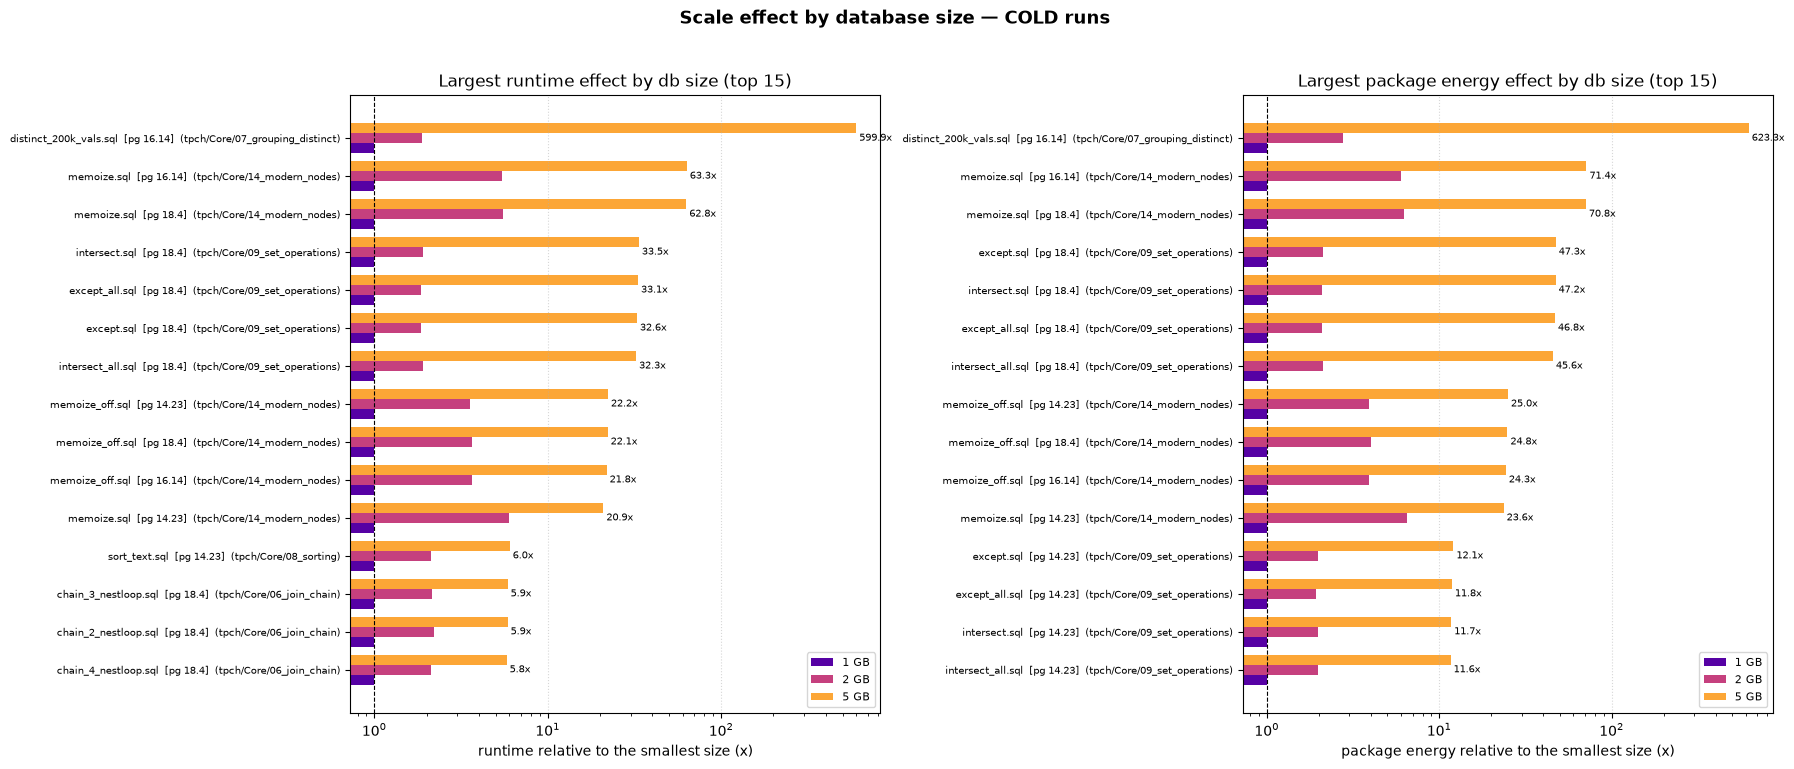

In [ ]:
# if not COLD_OK:
#     print("No cold data -> no cold scale-effect figure.")
# elif cold["db_size"].nunique() < 2:
#     print(f"[COLD] only one cold database size present "
#           f"({sorted(cold['db_size'].unique())}) - nothing to compare. "
#           "The cold scale-effect figure appears once cold runs exist at >1 size.")
# else:
#     src = cold
#     SIZES = sorted(src["db_size"].dropna().unique(),
#                    key=lambda l: float(re.match(r"([\d.]+)", str(l)).group(1)))
#     SKEY = ["query", "pg_version"]

#     def scale_effect(metric):
#         piv = src.pivot_table(index=SKEY, columns="db_size",
#                               values=metric, aggfunc="mean").reindex(columns=SIZES)
#         piv = piv[piv.notna().sum(axis=1) >= 2]
#         fold = (piv.max(axis=1) / piv.min(axis=1)).sort_values(ascending=False)
#         return piv, fold

#     smeta = src.drop_duplicates(SKEY).set_index(SKEY)[["group", "sql_file"]]

#     def slabel(k):
#         return f"{smeta.loc[k, 'sql_file']}  [pg {k[1]}]  ({smeta.loc[k, 'group']})"

#     TOP_N = 15
#     _, fold0 = scale_effect("avg_time_s")
#     if len(fold0) == 0:
#         print("[COLD] no cold query present at more than one size yet.")
#     else:
#         cmap = plt.cm.plasma(np.linspace(0.15, 0.8, len(SIZES)))
#         panels = [("avg_time_s", "runtime"), ("avg_pkg_j", "package energy")]
#         fig, axes = plt.subplots(1, len(panels),
#                                  figsize=(9 * len(panels), 0.42 * TOP_N + 1.5))
#         for ax, (metric, nice) in zip(axes, panels):
#             piv, fold = scale_effect(metric)
#             top = fold.head(TOP_N).index[::-1]
#             rel = piv.loc[top].div(piv.loc[top].min(axis=1), axis=0)
#             ybase = np.arange(len(top)); bh = 0.8 / len(SIZES)
#             for j, sz in enumerate(SIZES):
#                 off = (j - (len(SIZES) - 1) / 2) * bh
#                 ax.barh(ybase + off, rel[sz].to_numpy(dtype=float), height=bh,
#                         color=cmap[j], label=sz)
#             ax.axvline(1.0, color="k", lw=0.8, ls="--"); ax.set_xscale("log")
#             ax.set_xlabel(f"{nice} relative to the smallest size (x)")
#             ax.set_yticks(ybase)
#             ax.set_yticklabels([slabel(k) for k in top], fontsize=7)
#             for i, k in enumerate(top):
#                 ax.text(fold[k], i, f" {fold[k]:.1f}x", va="center", fontsize=7)
#             ax.set_title(f"Largest {nice} effect by db size (top {TOP_N})")
#             ax.legend(fontsize=8, loc="lower right")
#             ax.grid(axis="x", linestyle=":", alpha=0.5)
#         fig.suptitle("Scale effect by database size — COLD runs", fontsize=13,
#                      fontweight="bold")
#         fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 18. Time → RAPL scale — does energy track runtime?

Sections 11 and 17 scaled by Postgres version and by database size. This one
scales by **runtime itself**. For every query we take the cohort where it ran
**fastest** and the cohort where it ran **slowest**, and compare how much the
runtime multiplied against how much the **package energy** multiplied over the
same two cohorts:

$$\text{runtime fold} = \frac{t_{\max}}{t_{\min}}, \qquad
  \text{energy fold} = \frac{J_{pkg}\,(t_{\max})}{J_{pkg}\,(t_{\min})}$$

If energy scaled purely with time (constant average power) the two bars would
match. A **shorter** energy bar means the slow cohort ran at *lower* average
power; a **taller** one means it drew *more* power per second. Two panels show
the queries with the **largest** and the **smallest** runtime multiples.

In [46]:
tr = data[["query", "sql_file", "group", "dataset",
           "avg_time_s", "avg_pkg_j"]].copy()
tr = tr.dropna(subset=["avg_time_s", "avg_pkg_j"])
tr = tr[(tr["avg_time_s"] > 0) & (tr["avg_pkg_j"] > 0)]

# one runtime/energy per cohort (query x version x size), then per query pick
# the fastest and slowest cohort and read energy at those same two points.
coh = (tr.groupby(["query", "sql_file", "group", "dataset"],
                  as_index=False)[["avg_time_s", "avg_pkg_j"]].mean())

rows = []
for q, g in coh.groupby("query"):
    if len(g) < 2:
        continue
    lo = g.loc[g["avg_time_s"].idxmin()]
    hi = g.loc[g["avg_time_s"].idxmax()]
    t_fold = hi["avg_time_s"] / lo["avg_time_s"]
    j_fold = hi["avg_pkg_j"] / lo["avg_pkg_j"]
print(coh.groupby("query").size().value_counts())    

    #rows.append({
    #    "query": q, "sql_file": lo["sql_file"], "group": lo["group"],
    #    "t_fold": t_fold, "j_fold": j_fold, "power_ratio": j_fold / t_fold,
    #    "fast": f"pg {lo['pg_version']} / {lo['db_size']}  ({lo['avg_time_s']:.3g}s)",
    #    "slow": f"pg {hi['pg_version']} / {hi['db_size']}  ({hi['avg_time_s']:.3g}s)",
    #})

# sc = pd.DataFrame(rows)
# sc = sc[sc["t_fold"] > 1.0 + 1e-9]          # need a real spread in runtime

# if sc.empty:
#     print("No query spans more than one runtime yet "
#           "(need >=2 cohorts with different runtimes).")
# else:
#     sc = sc.sort_values("t_fold", ascending=False).reset_index(drop=True)
#     TOP_N = min(15, len(sc))
#     panels = [("Largest runtime multiples", sc.head(TOP_N)),
#               ("Smallest runtime multiples", sc.tail(TOP_N))]

#     fig, axes = plt.subplots(1, 2, figsize=(18, 0.42 * TOP_N + 1.5))
#     for ax, (title, sub) in zip(np.atleast_1d(axes), panels):
#         sub = sub.sort_values("t_fold")     # largest ends up at the top
#         y = np.arange(len(sub)); bh = 0.4
#         ax.barh(y + bh / 2, sub["t_fold"].to_numpy(dtype=float), height=bh,
#                 color="#4c72b0", label="runtime fold")
#         ax.barh(y - bh / 2, sub["j_fold"].to_numpy(dtype=float), height=bh,
#                 color="#dd8452", label="pkg energy fold")
#         ax.axvline(1.0, color="k", lw=0.8, ls="--")
#         ax.set_xscale("log")
#         ax.set_yticks(y)
#         ax.set_yticklabels([f"{r.sql_file} ({r.group})" for r in sub.itertuples()],
#                            fontsize=7)
#         for i, r in enumerate(sub.itertuples()):
#             ax.text(r.t_fold, i + bh / 2, f" {r.t_fold:.1f}x", va="center", fontsize=6)
#             ax.text(r.j_fold, i - bh / 2, f" {r.j_fold:.1f}x", va="center", fontsize=6)
#         ax.set_xlabel("multiple (slowest cohort / fastest cohort)")
#         ax.set_title(f"{title} (top {TOP_N})")
#         ax.legend(fontsize=8, loc="lower right")
#         ax.grid(axis="x", linestyle=":", alpha=0.5)
#     fig.tight_layout(); plt.show()

#     print("Runtime vs package-energy multiple per query "
#           "(power_ratio < 1 => slow cohort ran at lower average power):")
#     print(sc[["sql_file", "group", "fast", "slow",
#               "t_fold", "j_fold", "power_ratio"]].round(2).to_string(index=False))

1    28
Name: count, dtype: int64


### 18b. Time → RAPL scale on the **cold** runs

The cold counterpart of section 18 (titled **COLD**): for each query, the
fastest vs slowest **cold** cohort, comparing the runtime multiple against the
package-energy multiple.

In [48]:
if not COLD_OK:
    print("No cold data -> no cold time->RAPL scale figure.")
else:
    tr = cold[["query", "sql_file", "group", "dataset",
               "avg_time_s", "avg_pkg_j"]].copy()
    tr = tr.dropna(subset=["avg_time_s", "avg_pkg_j"])
    tr = tr[(tr["avg_time_s"] > 0) & (tr["avg_pkg_j"] > 0)]
    coh = (tr.groupby(["query", "sql_file", "group", "dataset"],
                      as_index=False)[["avg_time_s", "avg_pkg_j"]].mean())
    rows = []
    for q, g in coh.groupby("query"):
        if len(g) < 2:
            continue
        lo = g.loc[g["avg_time_s"].idxmin()]; hi = g.loc[g["avg_time_s"].idxmax()]
    print(coh.groupby("query").size().value_counts())    
    #     rows.append({
    #         "query": q, "sql_file": lo["sql_file"], "group": lo["group"],
    #         "t_fold": hi["avg_time_s"] / lo["avg_time_s"],
    #         "j_fold": hi["avg_pkg_j"] / lo["avg_pkg_j"],
    #         "power_ratio": (hi["avg_pkg_j"] / lo["avg_pkg_j"]) /
    #                        (hi["avg_time_s"] / lo["avg_time_s"]),
    #         "fast": f"pg {lo['pg_version']} / {lo['db_size']}  ({lo['avg_time_s']:.3g}s)",
    #         "slow": f"pg {hi['pg_version']} / {hi['db_size']}  ({hi['avg_time_s']:.3g}s)"})
    # sc = pd.DataFrame(rows)
    # sc = sc[sc["t_fold"] > 1.0 + 1e-9] if len(sc) else sc
    # if len(sc) == 0:
    #     print("[COLD] no cold query spans more than one runtime yet "
    #           "(need >=2 cold cohorts with different runtimes).")
    # else:
    #     sc = sc.sort_values("t_fold", ascending=False).reset_index(drop=True)
    #     TOP_N = min(15, len(sc))
    #     panels = [("Largest runtime multiples", sc.head(TOP_N)),
    #               ("Smallest runtime multiples", sc.tail(TOP_N))]
    #     fig, axes = plt.subplots(1, 2, figsize=(18, 0.42 * TOP_N + 1.5))
    #     for ax, (title, sub) in zip(np.atleast_1d(axes), panels):
    #         sub = sub.sort_values("t_fold"); y = np.arange(len(sub)); bh = 0.4
    #         ax.barh(y + bh / 2, sub["t_fold"].to_numpy(dtype=float), height=bh,
    #                 color="#4c72b0", label="runtime fold")
    #         ax.barh(y - bh / 2, sub["j_fold"].to_numpy(dtype=float), height=bh,
    #                 color="#dd8452", label="pkg energy fold")
    #         ax.axvline(1.0, color="k", lw=0.8, ls="--"); ax.set_xscale("log")
    #         ax.set_yticks(y)
    #         ax.set_yticklabels([f"{r.sql_file} ({r.group})" for r in sub.itertuples()],
    #                            fontsize=7)
    #         for i, r in enumerate(sub.itertuples()):
    #             ax.text(r.t_fold, i + bh / 2, f" {r.t_fold:.1f}x", va="center", fontsize=6)
    #             ax.text(r.j_fold, i - bh / 2, f" {r.j_fold:.1f}x", va="center", fontsize=6)
    #         ax.set_xlabel("multiple (slowest cohort / fastest cohort)")
    #         ax.set_title(f"{title} (top {TOP_N})")
    #         ax.legend(fontsize=8, loc="lower right")
    #         ax.grid(axis="x", linestyle=":", alpha=0.5)
    #     fig.suptitle("Time -> RAPL scale — COLD runs", fontsize=13, fontweight="bold")
    #     fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
    #     print("[COLD] runtime vs package-energy multiple per query:")
    #     print(sc[["sql_file", "group", "fast", "slow",
    #               "t_fold", "j_fold", "power_ratio"]].round(2).to_string(index=False))

1    28
Name: count, dtype: int64


## 19. Power per cohort — highest & lowest

Organised **by cohort** this time. Within every cohort we rank its queries by
average package power,

$$P = \frac{J_{pkg}}{t}\quad[\text{watts}],$$

and give each cohort its own block. The **left** panel keeps the
`N_PER_COHORT` **highest**-power queries of each cohort (cohorts ordered by
their peak draw); the **right** panel keeps the **lowest**-power queries
(cohorts ordered by their floor). **Dotted lines** separate one cohort from
the next, and each block is labelled with its cohort. Set
`N_PER_COHORT = None` to show every query in each cohort.

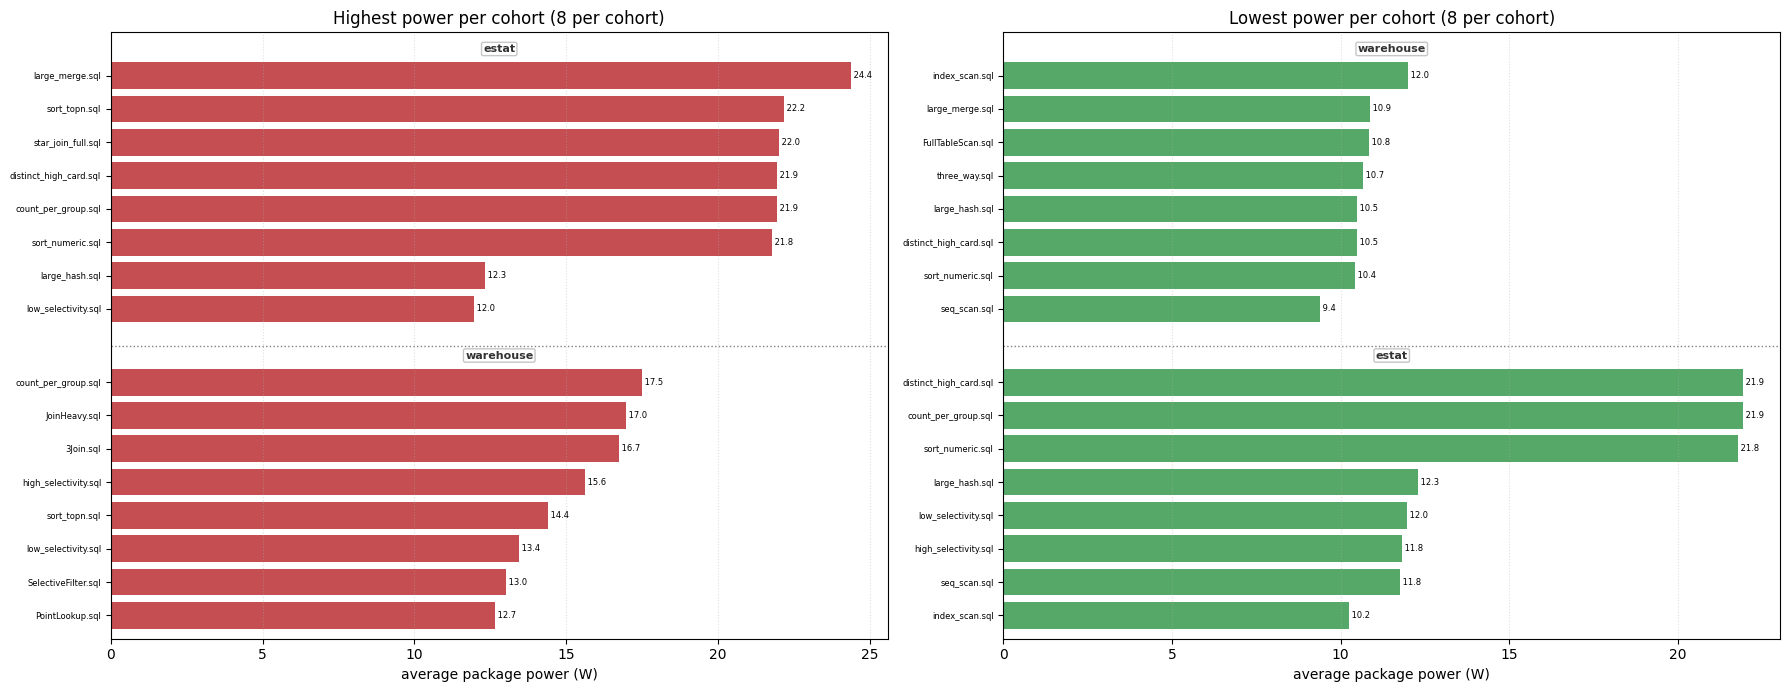

Package power ranges from 9.4 W to 24.4 W across 2 cohorts / 28 cohort-queries (median 12.6 W).


In [49]:
import matplotlib.transforms as mtrans

N_PER_COHORT = 8   # queries shown per cohort in each panel (set None to show all)

pw = data[["cohort", "query", "sql_file", "group",
           "avg_time_s", "avg_pkg_j"]].copy()
pw = pw.dropna(subset=["avg_time_s", "avg_pkg_j"])
pw = pw[(pw["avg_time_s"] > 0) & (pw["avg_pkg_j"] > 0)]
pw["watt"] = pw["avg_pkg_j"] / pw["avg_time_s"]

# one power value per (cohort, query)
pwc = (pw.groupby(["cohort", "query", "sql_file", "group"],
                  as_index=False)["watt"].mean())

if pwc.empty:
    print("No cohort has both energy and runtime measured.")
else:
    def blocks_for(kind):
        # kind "top": keep each cohort's highest-power queries; "bottom": lowest
        out = []
        for coh, g in pwc.groupby("cohort"):
            g = g.sort_values("watt", ascending=(kind == "bottom"))
            out.append((coh, g if N_PER_COHORT is None else g.head(N_PER_COHORT)))
        # cohort with the most extreme draw ends up drawn at the top
        out.sort(key=lambda b: b[1]["watt"].max() if kind == "top"
                 else b[1]["watt"].min(), reverse=(kind == "bottom"))
        return out

    def draw(ax, kind, title, colour):
        blocks = blocks_for(kind)
        trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)
        y, ticks, labels = 0, [], []
        for bi, (coh, sel) in enumerate(blocks):
            sel = sel.sort_values("watt")          # low -> high going upward
            for _, r in sel.iterrows():
                ax.barh(y, r["watt"], color=colour)
                ax.text(r["watt"], y, f" {r['watt']:.1f}", va="center", fontsize=6)
                ticks.append(y); labels.append(r["sql_file"]); y += 1
            ax.text(0.5, y - 0.35, coh, transform=trans, fontsize=8,
                    fontweight="bold", color="#333", va="bottom", ha="center",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white",
                              ec="0.7", alpha=0.75))
            if bi < len(blocks) - 1:
                ax.axhline(y + 0.1, ls=":", lw=1.0, color="0.5")
            y += 1.2                                # gap between cohorts
        ax.set_ylim(-0.7, y - 0.9)
        ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=6)
        ax.set_xlabel("average package power (W)")
        n = "all" if N_PER_COHORT is None else N_PER_COHORT
        ax.set_title(f"{title} ({n} per cohort)")
        ax.grid(axis="x", linestyle=":", alpha=0.4)

    ncoh = pwc["cohort"].nunique()
    per = pwc.groupby("cohort").size()
    shown = per if N_PER_COHORT is None else per.clip(upper=N_PER_COHORT)
    height = min(60, max(6, 0.3 * (int(shown.sum()) + 1.2 * ncoh) + 1.5))

    fig, axes = plt.subplots(1, 2, figsize=(18, height))
    draw(axes[0], "top", "Highest power per cohort", "#c44e52")
    draw(axes[1], "bottom", "Lowest power per cohort", "#55a868")
    fig.tight_layout(); plt.show()

    print(f"Package power ranges from {pwc['watt'].min():.1f} W to "
          f"{pwc['watt'].max():.1f} W across {ncoh} cohorts / {len(pwc)} "
          f"cohort-queries (median {pwc['watt'].median():.1f} W).")

### 19b. Power per cohort on the **cold** runs

The cold counterpart of section 19 (titled **COLD**): highest / lowest power
queries within each cold cohort.

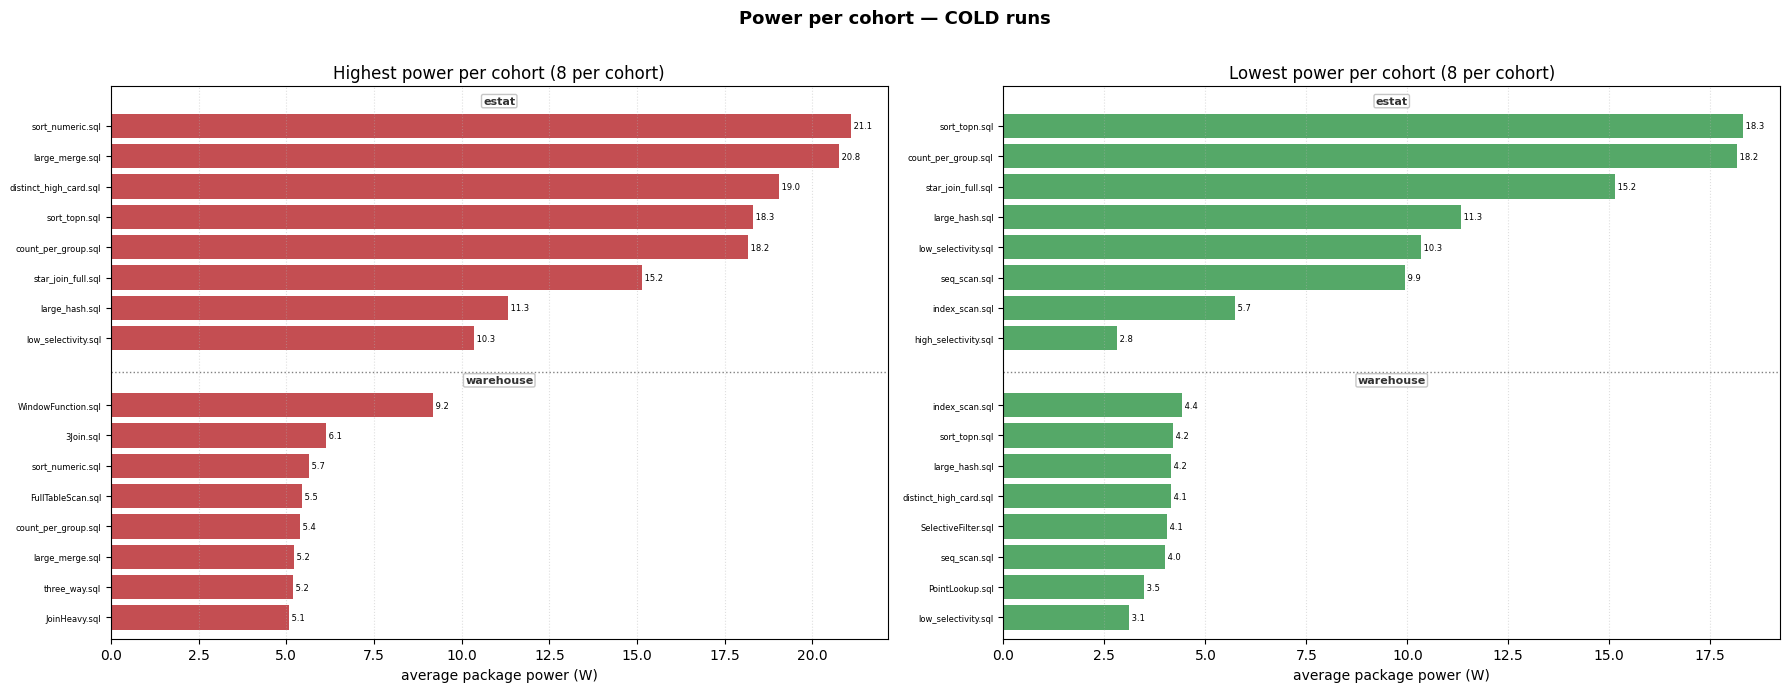

[COLD] package power 2.8-21.1 W across 2 cohorts / 28 cohort-queries (median 5.4 W).


In [50]:
if not COLD_OK:
    print("No cold data -> no cold power-per-cohort figure.")
else:
    import matplotlib.transforms as mtrans
    N_PER_COHORT = 8
    pw = cold[["cohort", "query", "sql_file", "group",
               "avg_time_s", "avg_pkg_j"]].copy()
    pw = pw.dropna(subset=["avg_time_s", "avg_pkg_j"])
    pw = pw[(pw["avg_time_s"] > 0) & (pw["avg_pkg_j"] > 0)]
    pw["watt"] = pw["avg_pkg_j"] / pw["avg_time_s"]
    pwc = pw.groupby(["cohort", "query", "sql_file", "group"],
                     as_index=False)["watt"].mean()
    if pwc.empty:
        print("[COLD] no cold cohort has both energy and runtime measured.")
    else:
        def blocks_for(kind):
            out = []
            for coh, g in pwc.groupby("cohort"):
                g = g.sort_values("watt", ascending=(kind == "bottom"))
                out.append((coh, g if N_PER_COHORT is None else g.head(N_PER_COHORT)))
            out.sort(key=lambda b: b[1]["watt"].max() if kind == "top"
                     else b[1]["watt"].min(), reverse=(kind == "bottom"))
            return out

        def draw(ax, kind, title, colour):
            blocks = blocks_for(kind)
            trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)
            y, ticks, labels = 0, [], []
            for bi, (coh, sel) in enumerate(blocks):
                sel = sel.sort_values("watt")
                for _, r in sel.iterrows():
                    ax.barh(y, r["watt"], color=colour)
                    ax.text(r["watt"], y, f" {r['watt']:.1f}", va="center", fontsize=6)
                    ticks.append(y); labels.append(r["sql_file"]); y += 1
                ax.text(0.5, y - 0.35, coh, transform=trans, fontsize=8,
                        fontweight="bold", color="#333", va="bottom", ha="center",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white",
                                  ec="0.7", alpha=0.75))
                if bi < len(blocks) - 1:
                    ax.axhline(y + 0.1, ls=":", lw=1.0, color="0.5")
                y += 1.2
            ax.set_ylim(-0.7, y - 0.9)
            ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=6)
            ax.set_xlabel("average package power (W)")
            n = "all" if N_PER_COHORT is None else N_PER_COHORT
            ax.set_title(f"{title} ({n} per cohort)")
            ax.grid(axis="x", linestyle=":", alpha=0.4)

        ncoh = pwc["cohort"].nunique(); per = pwc.groupby("cohort").size()
        shown = per if N_PER_COHORT is None else per.clip(upper=N_PER_COHORT)
        height = min(60, max(6, 0.3 * (int(shown.sum()) + 1.2 * ncoh) + 1.5))
        fig, axes = plt.subplots(1, 2, figsize=(18, height))
        draw(axes[0], "top", "Highest power per cohort", "#c44e52")
        draw(axes[1], "bottom", "Lowest power per cohort", "#55a868")
        fig.suptitle("Power per cohort — COLD runs", fontsize=13, fontweight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()
        print(f"[COLD] package power {pwc['watt'].min():.1f}-{pwc['watt'].max():.1f} W "
              f"across {ncoh} cohorts / {len(pwc)} cohort-queries "
              f"(median {pwc['watt'].median():.1f} W).")

## 20. Power by query — all cohorts of the top / bottom queries

Section 19 fixed the **cohort** and looked across its queries. This flips it:
we find the single highest-power `(query, cohort)` point, take **that query**,
and put **all of its cohorts** on the plot as one block — every size/version
of the peak query sits together. That query is then removed and we move to the
next highest remaining point, and so on (equivalently: queries ranked by their
peak-power cohort). The right panel does the same from the lowest-power point.
Blocks are separated by **dotted lines** and labelled by query.

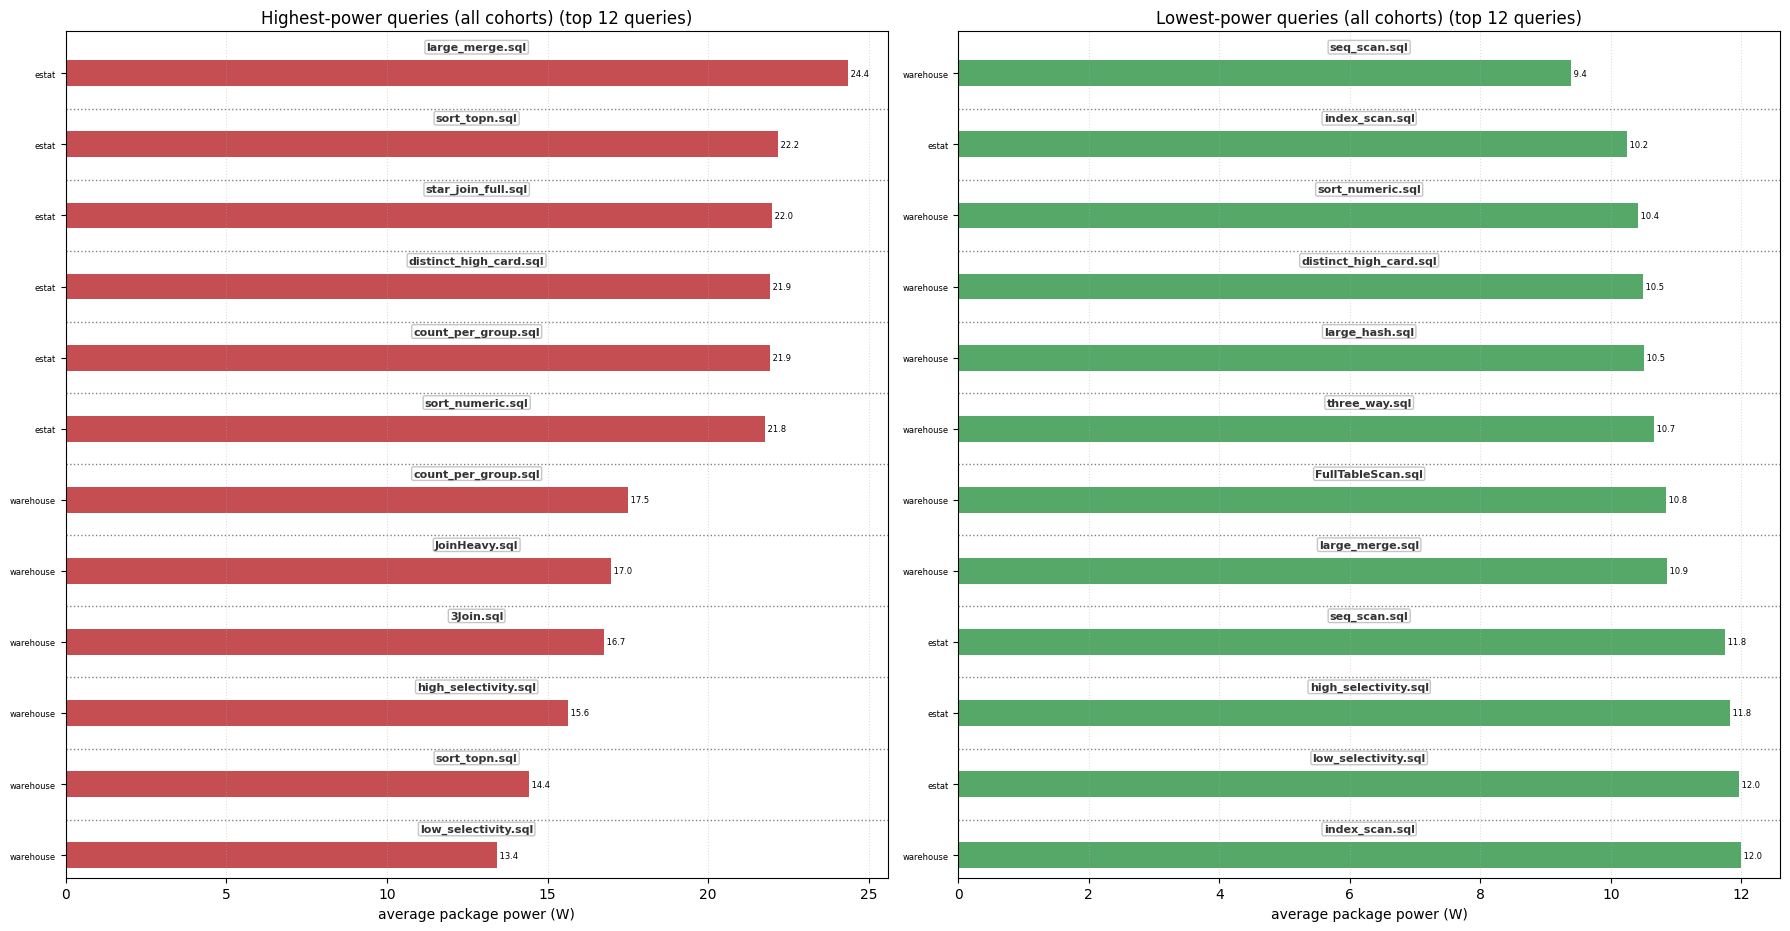

In [51]:
import matplotlib.transforms as mtrans

N_QUERIES = 12   # query blocks shown per panel

pw = data[["cohort", "query", "sql_file", "group",
           "avg_time_s", "avg_pkg_j"]].copy()
pw = pw.dropna(subset=["avg_time_s", "avg_pkg_j"])
pw = pw[(pw["avg_time_s"] > 0) & (pw["avg_pkg_j"] > 0)]
pw["watt"] = pw["avg_pkg_j"] / pw["avg_time_s"]
pwc = (pw.groupby(["cohort", "query", "sql_file", "group"],
                  as_index=False)["watt"].mean())

if pwc.empty:
    print("No cohort has both energy and runtime measured.")
else:
    # each query's peak (highest) and floor (lowest) power over its cohorts
    qstats = pwc.groupby(["query", "sql_file"])["watt"].agg(peak="max", floor="min")

    def qblocks(kind):
        order = (qstats.sort_values("peak", ascending=False) if kind == "top"
                 else qstats.sort_values("floor", ascending=True))
        picked = list(order.head(N_QUERIES).index)      # (query, sql_file) tuples
        blocks = [(sf, pwc[pwc["query"] == q].sort_values("watt"))
                  for q, sf in picked]
        return blocks[::-1]                             # most extreme at the top

    def draw(ax, kind, title, colour):
        blocks = qblocks(kind)
        trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)
        y, ticks, labels = 0, [], []
        for bi, (sf, sel) in enumerate(blocks):
            for _, r in sel.iterrows():
                ax.barh(y, r["watt"], color=colour)
                ax.text(r["watt"], y, f" {r['watt']:.1f}", va="center", fontsize=6)
                ticks.append(y); labels.append(r["cohort"]); y += 1
            ax.text(0.5, y - 0.35, sf, transform=trans, fontsize=8,
                    fontweight="bold", color="#333", va="bottom", ha="center",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white",
                              ec="0.7", alpha=0.75))
            if bi < len(blocks) - 1:
                ax.axhline(y + 0.1, ls=":", lw=1.0, color="0.5")
            y += 1.2
        ax.set_ylim(-0.7, y - 0.9)
        ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=6)
        ax.set_xlabel("average package power (W)")
        ax.set_title(f"{title} (top {min(N_QUERIES, len(qstats))} queries)")
        ax.grid(axis="x", linestyle=":", alpha=0.4)

    nq = min(N_QUERIES, len(qstats))
    total = max(sum(len(b[1]) for b in qblocks("top")),
                sum(len(b[1]) for b in qblocks("bottom")))
    height = min(60, max(6, 0.3 * (total + 1.2 * nq) + 1.5))

    fig, axes = plt.subplots(1, 2, figsize=(18, height))
    draw(axes[0], "top", "Highest-power queries (all cohorts)", "#c44e52")
    draw(axes[1], "bottom", "Lowest-power queries (all cohorts)", "#55a868")
    fig.tight_layout(); plt.show()

### 20b. Power by query on the **cold** runs

The cold counterpart of section 20 (titled **COLD**): the highest / lowest
power queries, each shown with all of its cold cohorts.

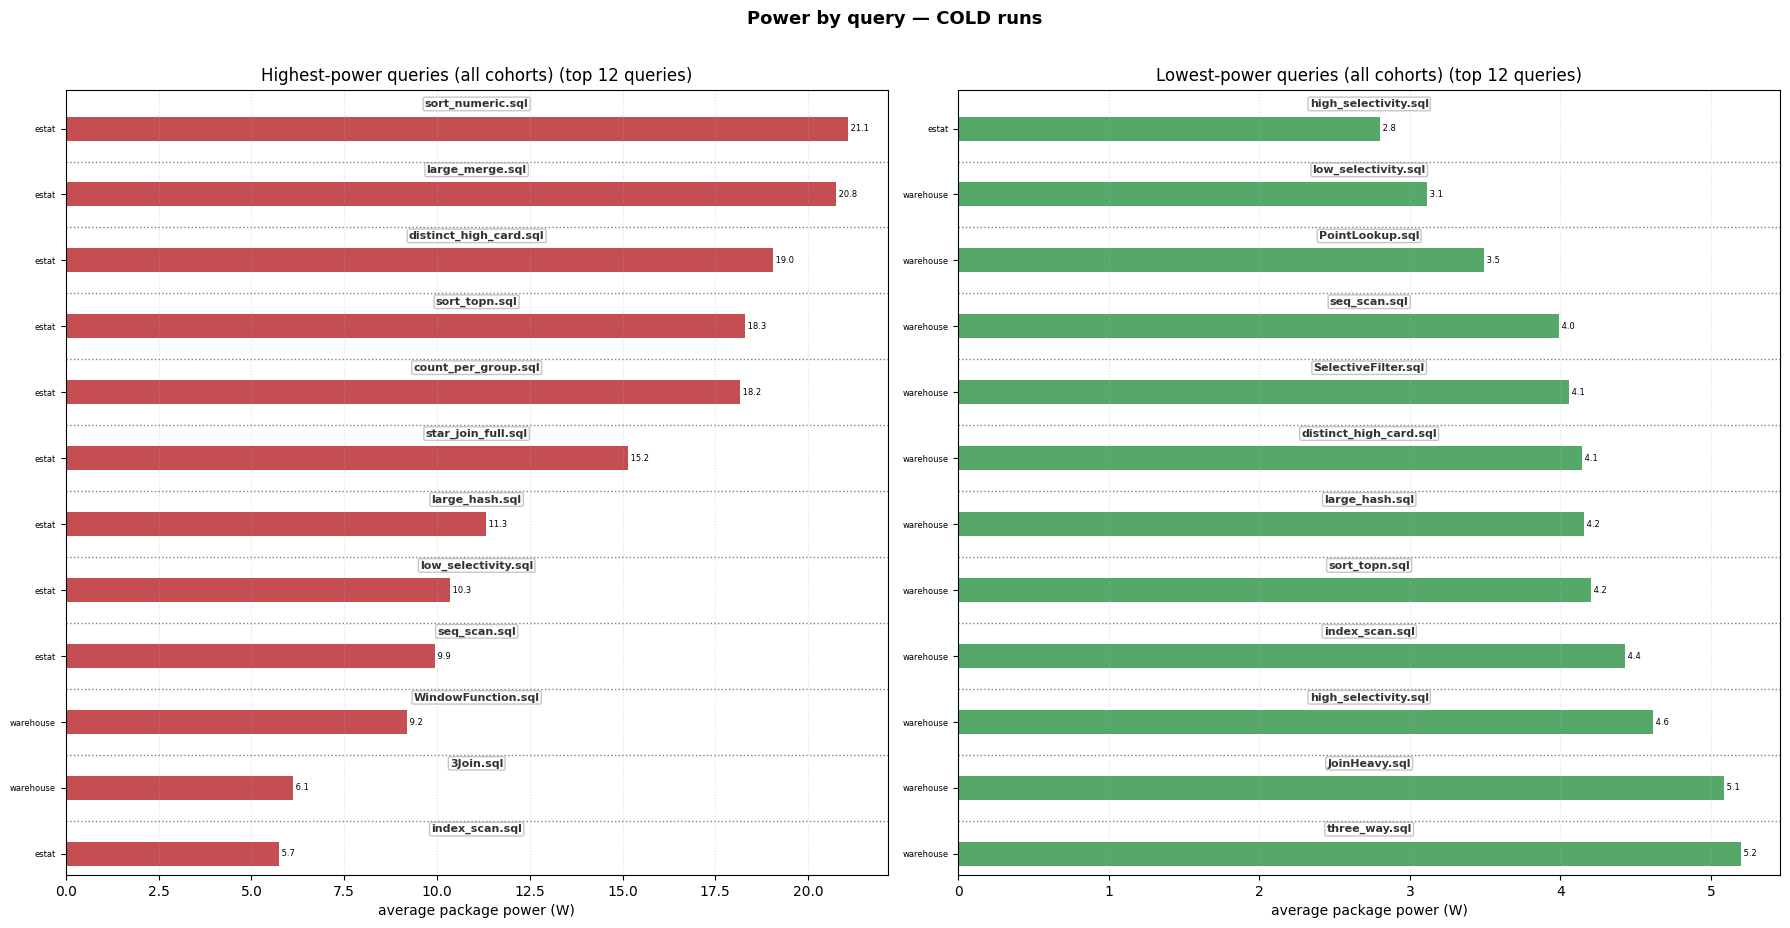

In [52]:
if not COLD_OK:
    print("No cold data -> no cold power-by-query figure.")
else:
    import matplotlib.transforms as mtrans
    N_QUERIES = 12
    pw = cold[["cohort", "query", "sql_file", "group",
               "avg_time_s", "avg_pkg_j"]].copy()
    pw = pw.dropna(subset=["avg_time_s", "avg_pkg_j"])
    pw = pw[(pw["avg_time_s"] > 0) & (pw["avg_pkg_j"] > 0)]
    pw["watt"] = pw["avg_pkg_j"] / pw["avg_time_s"]
    pwc = pw.groupby(["cohort", "query", "sql_file", "group"],
                     as_index=False)["watt"].mean()
    if pwc.empty:
        print("[COLD] no cold cohort has both energy and runtime measured.")
    else:
        qstats = pwc.groupby(["query", "sql_file"])["watt"].agg(peak="max", floor="min")

        def qblocks(kind):
            order = (qstats.sort_values("peak", ascending=False) if kind == "top"
                     else qstats.sort_values("floor", ascending=True))
            picked = list(order.head(N_QUERIES).index)
            blocks = [(sf, pwc[pwc["query"] == q].sort_values("watt"))
                      for q, sf in picked]
            return blocks[::-1]

        def draw(ax, kind, title, colour):
            blocks = qblocks(kind)
            trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)
            y, ticks, labels = 0, [], []
            for bi, (sf, sel) in enumerate(blocks):
                for _, r in sel.iterrows():
                    ax.barh(y, r["watt"], color=colour)
                    ax.text(r["watt"], y, f" {r['watt']:.1f}", va="center", fontsize=6)
                    ticks.append(y); labels.append(r["cohort"]); y += 1
                ax.text(0.5, y - 0.35, sf, transform=trans, fontsize=8,
                        fontweight="bold", color="#333", va="bottom", ha="center",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white",
                                  ec="0.7", alpha=0.75))
                if bi < len(blocks) - 1:
                    ax.axhline(y + 0.1, ls=":", lw=1.0, color="0.5")
                y += 1.2
            ax.set_ylim(-0.7, y - 0.9)
            ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=6)
            ax.set_xlabel("average package power (W)")
            ax.set_title(f"{title} (top {min(N_QUERIES, len(qstats))} queries)")
            ax.grid(axis="x", linestyle=":", alpha=0.4)

        nq = min(N_QUERIES, len(qstats))
        total = max(sum(len(b[1]) for b in qblocks("top")),
                    sum(len(b[1]) for b in qblocks("bottom")))
        height = min(60, max(6, 0.3 * (total + 1.2 * nq) + 1.5))
        fig, axes = plt.subplots(1, 2, figsize=(18, height))
        draw(axes[0], "top", "Highest-power queries (all cohorts)", "#c44e52")
        draw(axes[1], "bottom", "Lowest-power queries (all cohorts)", "#55a868")
        fig.suptitle("Power by query — COLD runs", fontsize=13, fontweight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## 21. Postgres version summary — which version is best?

A head-to-head of the Postgres versions on **performance** (runtime) and
**energy**. Totals only mean something when the versions ran the *same* work,
so the comparison is restricted to the **comparable set**: every
`(query, database size)` that was measured on **all** versions. Over that set
we report, per version:

* **total runtime** and **total energy** (the full comparable sweep), plus each
  as a multiple of the best version (`x vs best`);
* **average power** = total energy / total runtime;
* a **geometric-mean** per-query ratio to the per-query best — this is the
  *typical* slowdown / energy overhead a version carries, so a handful of huge
  queries can't dominate the verdict (1.00 = fastest/leanest on average).

It then breaks the same totals down **by database size** and **by subfolder**,
and tallies which version wins each subfolder.

In [ ]:
# dv = data[["pg_version", "db_size", "group", "query", "sql_file",
#            "avg_time_s", "avg_pkg_j"]].copy()
# dv = dv.dropna(subset=["avg_time_s", "avg_pkg_j"])
# dv = dv[(dv["avg_time_s"] > 0) & (dv["avg_pkg_j"] > 0)]

# def _vkey(v):
#     return [int(x) for x in str(v).split(".") if x.isdigit()]
# VERSIONS = sorted(dv["pg_version"].unique(), key=_vkey)

# if len(VERSIONS) < 2:
#     print(f"Only one Postgres version present ({VERSIONS}); nothing to compare.")
# else:
#     # comparable set: (query, size) measured on EVERY version
#     key = ["query", "db_size"]
#     seen = dv.groupby(key)["pg_version"].nunique()
#     common = seen[seen == len(VERSIONS)].reset_index()[key]
#     comp = dv.merge(common, on=key, how="inner")

#     agg = comp.groupby("pg_version").agg(
#         queries=("query", "nunique"),
#         total_runtime_s=("avg_time_s", "sum"),
#         total_energy_j=("avg_pkg_j", "sum"),
#     ).reindex(VERSIONS)
#     agg["avg_power_w"] = agg["total_energy_j"] / agg["total_runtime_s"]
#     agg["runtime_vs_best"] = agg["total_runtime_s"] / agg["total_runtime_s"].min()
#     agg["energy_vs_best"] = agg["total_energy_j"] / agg["total_energy_j"].min()

#     # per-query geometric-mean ratio to the per-key best
#     tpiv = comp.pivot_table(index=key, columns="pg_version",
#                             values="avg_time_s").reindex(columns=VERSIONS)
#     epiv = comp.pivot_table(index=key, columns="pg_version",
#                             values="avg_pkg_j").reindex(columns=VERSIONS)
#     geo_t = np.exp(np.log(tpiv.div(tpiv.min(axis=1), axis=0)).mean())
#     geo_e = np.exp(np.log(epiv.div(epiv.min(axis=1), axis=0)).mean())
#     agg["geomean_slowdown"] = geo_t
#     agg["geomean_energy_ratio"] = geo_e

#     print(f"Comparable set: {len(common)} (query, size) pairs measured on all "
#           f"{len(VERSIONS)} versions.\n")
#     show = agg.copy()
#     show.index = [f"pg {v}" for v in show.index]
#     print(show.round({"total_runtime_s": 1, "total_energy_j": 0, "avg_power_w": 1,
#                       "runtime_vs_best": 3, "energy_vs_best": 3,
#                       "geomean_slowdown": 3, "geomean_energy_ratio": 3}).to_string())

#     best_perf = agg["total_runtime_s"].idxmin()
#     best_energy = agg["total_energy_j"].idxmin()
#     best_power = agg["avg_power_w"].idxmin()
#     print("\nVERDICT (over the comparable set):")
#     print(f"  fastest total runtime : pg {best_perf} "
#           f"({agg.loc[best_perf, 'total_runtime_s']:.1f}s, "
#           f"{agg['runtime_vs_best'].max():.2f}x separates best from worst)")
#     print(f"  lowest total energy   : pg {best_energy} "
#           f"({agg.loc[best_energy, 'total_energy_j']:.0f} J)")
#     print(f"  lowest average power  : pg {best_power} "
#           f"({agg.loc[best_power, 'avg_power_w']:.1f} W)")
#     print(f"  typical per query     : pg {geo_t.idxmin()} fastest "
#           f"(geomean slowdown {geo_t.min():.3f}); "
#           f"pg {geo_e.idxmin()} leanest (geomean energy {geo_e.min():.3f})")

#     # context only: each version's own full sweep (different query sets / sizes)
#     own = dv.groupby("pg_version").agg(
#         queries=("query", "nunique"),
#         total_runtime_s=("avg_time_s", "sum"),
#         total_energy_j=("avg_pkg_j", "sum")).reindex(VERSIONS)
#     own.index = [f"pg {v}" for v in own.index]
#     print("\nContext - each version's own full sweep "
#           "(NOT apples-to-apples: different query sets/sizes):")
#     print(own.round(1).to_string())

Comparable set: 1056 (query, size) pairs measured on all 3 versions.

          queries  total_runtime_s  total_energy_j  avg_power_w  runtime_vs_best  energy_vs_best  geomean_slowdown  geomean_energy_ratio
pg 14.23      524           5517.9         70010.0         12.7            1.154            1.09             1.141                 1.069
pg 16.14      524           5112.6         64879.0         12.7            1.069            1.01             1.104                 1.026
pg 18.4       524           4782.7         64206.0         13.4            1.000            1.00             1.019                 1.038

VERDICT (over the comparable set):
  fastest total runtime : pg 18.4 (4782.7s, 1.15x separates best from worst)
  lowest total energy   : pg 18.4 (64206 J)
  lowest average power  : pg 14.23 (12.7 W)
  typical per query     : pg 18.4 fastest (geomean slowdown 1.019); pg 16.14 leanest (geomean energy 1.026)

Context - each version's own full sweep (NOT apples-to-apples: different

In [ ]:
# if len(VERSIONS) >= 2:
#     SZ = sorted(comp["db_size"].unique(),
#                 key=lambda l: float(re.match(r"([\d.]+)", str(l)).group(1)))

#     size_rt = comp.pivot_table(index="db_size", columns="pg_version",
#                                values="avg_time_s", aggfunc="sum").reindex(
#                                    index=SZ, columns=VERSIONS)
#     size_en = comp.pivot_table(index="db_size", columns="pg_version",
#                                values="avg_pkg_j", aggfunc="sum").reindex(
#                                    index=SZ, columns=VERSIONS)
#     size_rt.columns = [f"pg {v}" for v in size_rt.columns]
#     size_en.columns = [f"pg {v}" for v in size_en.columns]
#     print("Total runtime (s) by database size x version (comparable set):")
#     print(size_rt.round(2).to_string())
#     print("\nTotal package energy (J) by database size x version:")
#     print(size_en.round(0).to_string())

#     # subfolder winners
#     rt_g = comp.pivot_table(index="group", columns="pg_version",
#                             values="avg_time_s", aggfunc="sum").reindex(columns=VERSIONS)
#     en_g = comp.pivot_table(index="group", columns="pg_version",
#                             values="avg_pkg_j", aggfunc="sum").reindex(columns=VERSIONS)
#     winners = pd.DataFrame({
#         "fastest_version": ["pg " + str(v) for v in rt_g.idxmin(axis=1)],
#         "runtime_spread_x": (rt_g.max(axis=1) / rt_g.min(axis=1)).round(2),
#         "leanest_version": ["pg " + str(v) for v in en_g.idxmin(axis=1)],
#         "energy_spread_x": (en_g.max(axis=1) / en_g.min(axis=1)).round(2),
#     }, index=rt_g.index).sort_values("runtime_spread_x", ascending=False)
#     print("\nPer-subfolder winners (comparable set):")
#     print(winners.to_string())
#     print("\nSubfolder wins by fastest version:")
#     print(winners["fastest_version"].value_counts().to_string())
#     print("Subfolder wins by leanest (energy) version:")
#     print(winners["leanest_version"].value_counts().to_string())

Total runtime (s) by database size x version (comparable set):
         pg 14.23  pg 16.14  pg 18.4
db_size                             
1 GB      1804.81   1682.67  1565.23
2 GB      3682.15   3396.54  3186.35
5 GB        30.91     33.41    31.12

Total package energy (J) by database size x version:
         pg 14.23  pg 16.14  pg 18.4
db_size                             
1 GB      22860.0   21347.0  20794.0
2 GB      46784.0   43160.0  43000.0
5 GB        366.0     371.0    412.0

Per-subfolder winners (comparable set):
                                      fastest_version  runtime_spread_x leanest_version  energy_spread_x
group                                                                                                   
tpch/Core/00_baseline                         pg 18.4              1.42        pg 14.23             1.07
tpch/Functions/09-03_math                     pg 18.4              1.41         pg 18.4             1.34
tpch/Core/08_sorting                         pg 16.1

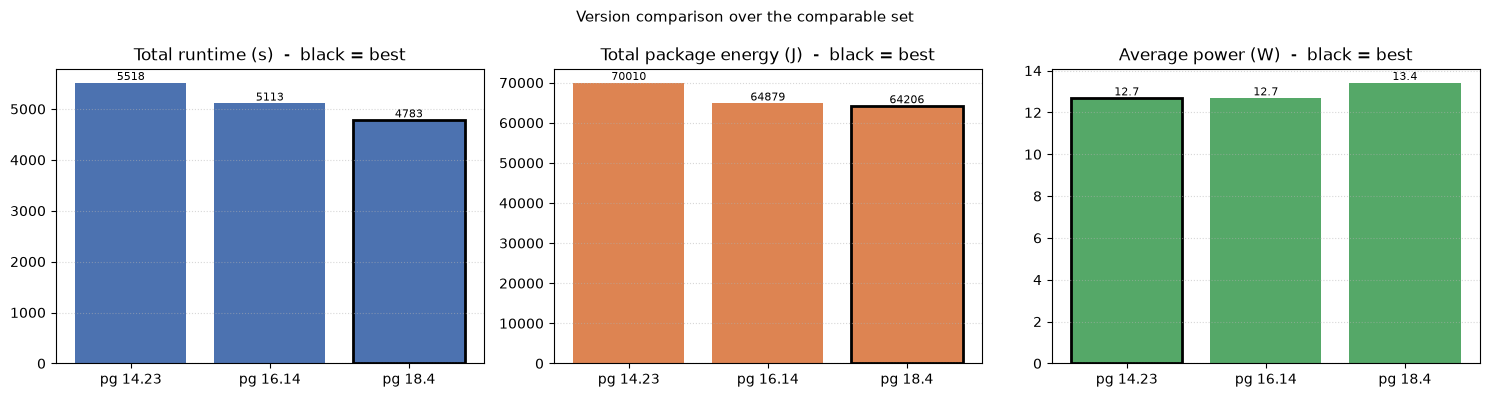

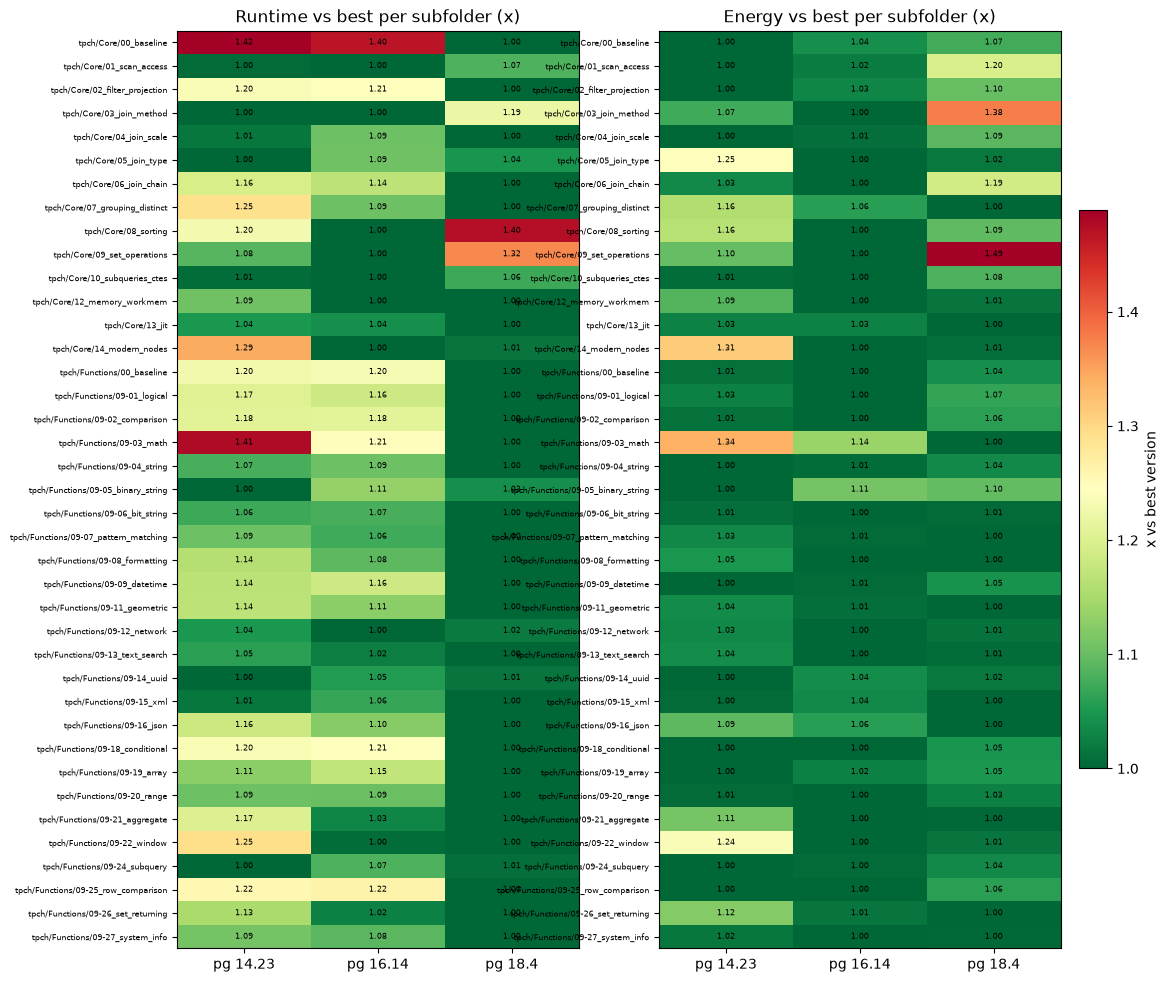

In [ ]:
# if len(VERSIONS) >= 2:
#     vlab = [f"pg {v}" for v in VERSIONS]
#     x = np.arange(len(VERSIONS))

#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     for ax, col, title, colour, unit in [
#         (axes[0], "total_runtime_s", "Total runtime", "#4c72b0", "s"),
#         (axes[1], "total_energy_j", "Total package energy", "#dd8452", "J"),
#         (axes[2], "avg_power_w", "Average power", "#55a868", "W")]:
#         vals = agg[col].to_numpy(dtype=float)
#         best = np.nanargmin(vals)
#         bars = ax.bar(x, vals, color=colour)
#         bars[best].set_edgecolor("black"); bars[best].set_linewidth(2)
#         for i, v in enumerate(vals):
#             ax.text(i, v, f"{v:.0f}" if unit != "W" else f"{v:.1f}",
#                     ha="center", va="bottom", fontsize=8)
#         ax.set_xticks(x); ax.set_xticklabels(vlab)
#         ax.set_title(f"{title} ({unit})  -  black = best")
#         ax.grid(axis="y", linestyle=":", alpha=0.5)
#     fig.suptitle("Version comparison over the comparable set", fontsize=11)
#     fig.tight_layout(); plt.show()

#     def heat(ax, piv, title):
#         rel = piv.div(piv.min(axis=1), axis=0)
#         rel = rel.loc[sorted(rel.index)]      # subfolders A->Z (top to bottom)
#         arr = rel.to_numpy(dtype=float)
#         vmax = max(1.05, min(3.0, np.nanmax(arr)))
#         im = ax.imshow(arr, aspect="auto", cmap="RdYlGn_r", vmin=1.0, vmax=vmax)
#         ax.set_xticks(range(len(VERSIONS)))
#         ax.set_xticklabels([f"pg {v}" for v in VERSIONS])
#         ax.set_yticks(range(len(rel)))
#         ax.set_yticklabels(rel.index, fontsize=6)
#         for i in range(arr.shape[0]):
#             for j in range(arr.shape[1]):
#                 ax.text(j, i, f"{arr[i, j]:.2f}", ha="center", va="center",
#                         fontsize=6)
#         ax.set_title(title)
#         return im

#     ng = comp["group"].nunique()
#     fig, axes = plt.subplots(1, 2, figsize=(12, max(3, 0.28 * ng + 1)))
#     heat(axes[0], rt_g, "Runtime vs best per subfolder (x)")
#     im = heat(axes[1], en_g, "Energy vs best per subfolder (x)")
#     fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02, label="x vs best version")
#     plt.show()

### 21b. Version summary on the **cold** runs

The cold counterpart of section 21 (titled **COLD**): the comparable-set
totals, per-version verdict, and the two subfolder heatmaps, computed from the
cold runs.

[COLD] comparable set: 1625 (query, size) pairs on all 3 versions

          queries  total_runtime_s  total_energy_j  avg_power_w  runtime_vs_best  energy_vs_best  geomean_slowdown  geomean_energy_ratio
pg 14.23      577          16650.8        213952.0         12.8            1.161           1.069             1.212                 1.070
pg 16.14      577          17205.7        218918.0         12.7            1.200           1.094             1.189                 1.040
pg 18.4       577          14339.3        200099.0         14.0            1.000           1.000             1.020                 1.031

[COLD] VERDICT:
  fastest total runtime : pg 18.4
  lowest total energy   : pg 18.4
  lowest average power  : pg 16.14


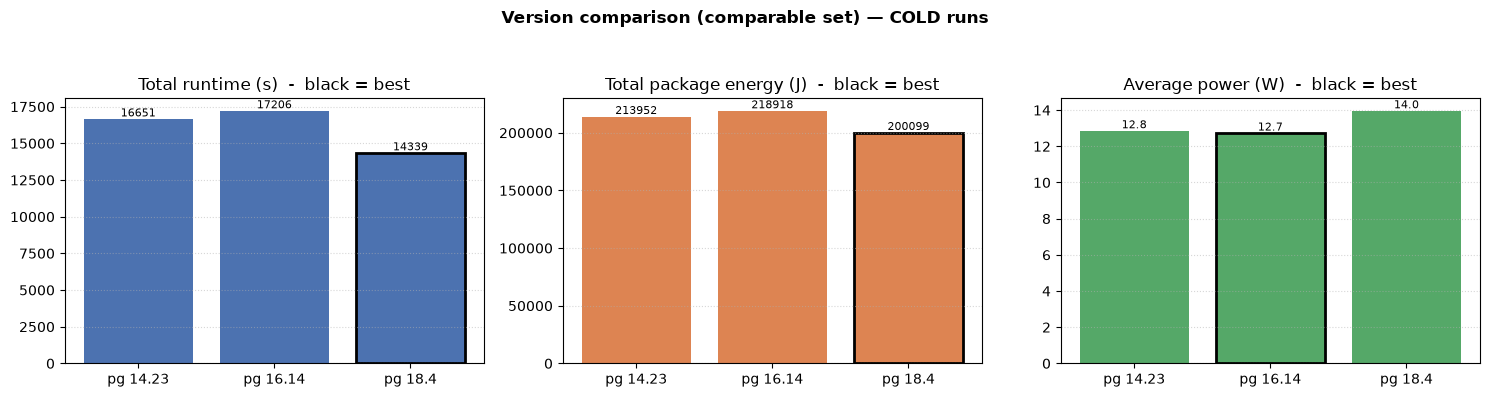

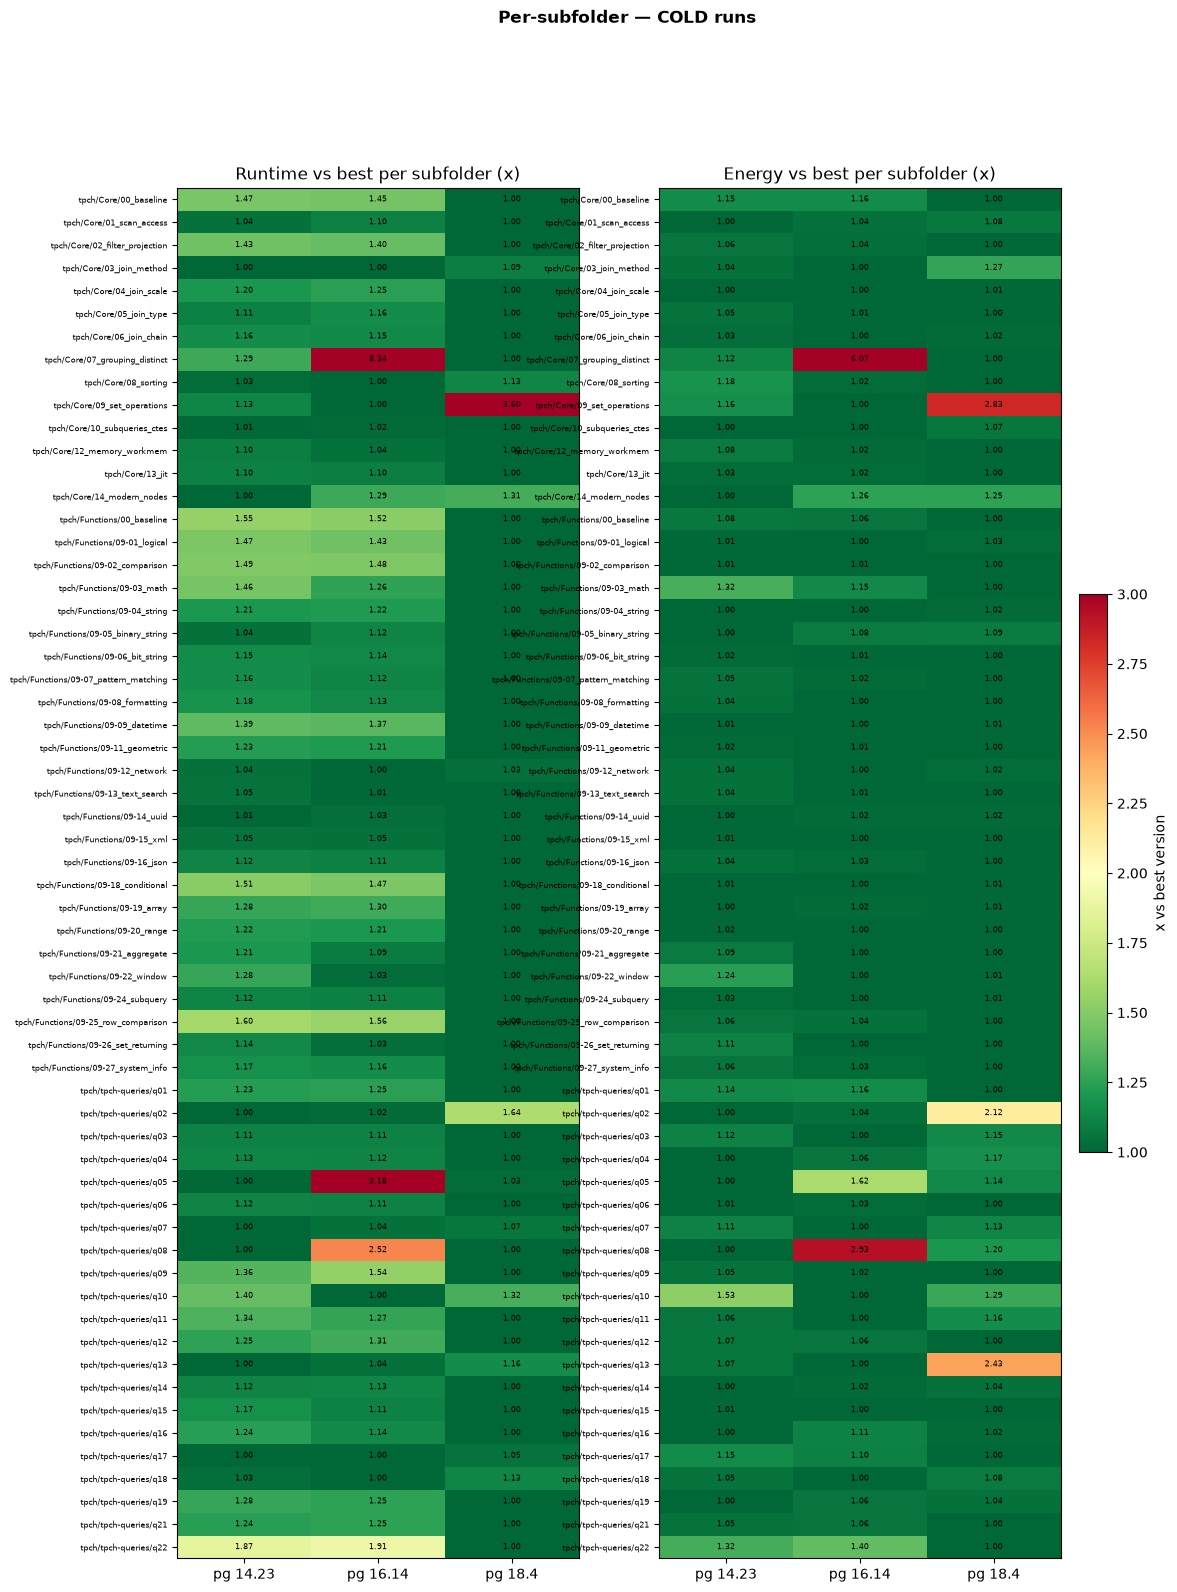

In [ ]:
# if not COLD_OK:
#     print("No cold data -> no cold version comparison.")
# else:
#     cdv = cold[["pg_version", "db_size", "group", "query",
#                 "avg_time_s", "avg_pkg_j"]].copy()
#     cdv = cdv.dropna(subset=["avg_time_s", "avg_pkg_j"])
#     cdv = cdv[(cdv["avg_time_s"] > 0) & (cdv["avg_pkg_j"] > 0)]

#     def _vk(v):
#         return [int(x) for x in str(v).split(".") if x.isdigit()]
#     CVERS = sorted(cdv["pg_version"].unique(), key=_vk)

#     if len(CVERS) < 2:
#         print(f"[COLD] only one version present ({CVERS}); nothing to compare.")
#     else:
#         key = ["query", "db_size"]
#         seen = cdv.groupby(key)["pg_version"].nunique()
#         common = seen[seen == len(CVERS)].reset_index()[key]
#         comp = cdv.merge(common, on=key, how="inner")
#         agg = comp.groupby("pg_version").agg(
#             queries=("query", "nunique"),
#             total_runtime_s=("avg_time_s", "sum"),
#             total_energy_j=("avg_pkg_j", "sum")).reindex(CVERS)
#         agg["avg_power_w"] = agg["total_energy_j"] / agg["total_runtime_s"]
#         agg["runtime_vs_best"] = agg["total_runtime_s"] / agg["total_runtime_s"].min()
#         agg["energy_vs_best"] = agg["total_energy_j"] / agg["total_energy_j"].min()
#         tpiv = comp.pivot_table(index=key, columns="pg_version",
#                                 values="avg_time_s").reindex(columns=CVERS)
#         epiv = comp.pivot_table(index=key, columns="pg_version",
#                                 values="avg_pkg_j").reindex(columns=CVERS)
#         agg["geomean_slowdown"] = np.exp(np.log(tpiv.div(tpiv.min(axis=1), axis=0)).mean())
#         agg["geomean_energy_ratio"] = np.exp(np.log(epiv.div(epiv.min(axis=1), axis=0)).mean())
#         show = agg.copy(); show.index = [f"pg {v}" for v in show.index]
#         print(f"[COLD] comparable set: {len(common)} (query, size) pairs on all "
#               f"{len(CVERS)} versions\n")
#         print(show.round({"total_runtime_s": 1, "total_energy_j": 0, "avg_power_w": 1,
#                           "runtime_vs_best": 3, "energy_vs_best": 3,
#                           "geomean_slowdown": 3, "geomean_energy_ratio": 3}).to_string())
#         print("\n[COLD] VERDICT:")
#         print(f"  fastest total runtime : pg {agg['total_runtime_s'].idxmin()}")
#         print(f"  lowest total energy   : pg {agg['total_energy_j'].idxmin()}")
#         print(f"  lowest average power  : pg {agg['avg_power_w'].idxmin()}")

#         vlab = [f"pg {v}" for v in CVERS]; x = np.arange(len(CVERS))
#         fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#         for ax, col, title, colour, unit in [
#                 (axes[0], "total_runtime_s", "Total runtime", "#4c72b0", "s"),
#                 (axes[1], "total_energy_j", "Total package energy", "#dd8452", "J"),
#                 (axes[2], "avg_power_w", "Average power", "#55a868", "W")]:
#             vals = agg[col].to_numpy(dtype=float); best = np.nanargmin(vals)
#             bars = ax.bar(x, vals, color=colour)
#             bars[best].set_edgecolor("black"); bars[best].set_linewidth(2)
#             for i, v in enumerate(vals):
#                 ax.text(i, v, f"{v:.0f}" if unit != "W" else f"{v:.1f}",
#                         ha="center", va="bottom", fontsize=8)
#             ax.set_xticks(x); ax.set_xticklabels(vlab)
#             ax.set_title(f"{title} ({unit})  -  black = best")
#             ax.grid(axis="y", linestyle=":", alpha=0.5)
#         fig.suptitle("Version comparison (comparable set) — COLD runs",
#                      fontsize=12, fontweight="bold")
#         fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

#         rt_g = comp.pivot_table(index="group", columns="pg_version",
#                                 values="avg_time_s", aggfunc="sum").reindex(columns=CVERS)
#         en_g = comp.pivot_table(index="group", columns="pg_version",
#                                 values="avg_pkg_j", aggfunc="sum").reindex(columns=CVERS)

#         def heat(ax, piv, title):
#             rel = piv.div(piv.min(axis=1), axis=0)
#             rel = rel.loc[sorted(rel.index)]
#             arr = rel.to_numpy(dtype=float)
#             vmax = max(1.05, min(3.0, np.nanmax(arr)))
#             im = ax.imshow(arr, aspect="auto", cmap="RdYlGn_r", vmin=1.0, vmax=vmax)
#             ax.set_xticks(range(len(CVERS)))
#             ax.set_xticklabels([f"pg {v}" for v in CVERS])
#             ax.set_yticks(range(len(rel))); ax.set_yticklabels(rel.index, fontsize=6)
#             for i in range(arr.shape[0]):
#                 for j in range(arr.shape[1]):
#                     ax.text(j, i, f"{arr[i, j]:.2f}", ha="center", va="center", fontsize=6)
#             ax.set_title(title)
#             return im

#         ng = comp["group"].nunique()
#         fig, axes = plt.subplots(1, 2, figsize=(12, max(3, 0.28 * ng + 1)))
#         heat(axes[0], rt_g, "Runtime vs best per subfolder (x)")
#         im = heat(axes[1], en_g, "Energy vs best per subfolder (x)")
#         fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02, label="x vs best version")
#         fig.suptitle("Per-subfolder — COLD runs", fontsize=12, fontweight="bold")
#         plt.show()

## 22. Version win counts — how many queries each version wins

*(warm runs only.)*

Section 21 compared **totals**; this counts, query by query, **how many
queries each version is fastest / leanest on**. Over the same comparable set
(every `(query, size)` measured on all versions), each query is awarded to the
version with the lowest runtime (and, separately, lowest energy) — but only if
it beats the runner-up by more than **`WIN_MARGIN_PCT`** (default 2%). If the
versions are within that margin the query is a **tie** — too close to call,
which is the honest verdict here given there isn't enough data for a real
significance test.

The margin is **relative** — `runner_up / best − 1` — so it scales the same
way for a 3 ms query and a 30 s one; a fixed *absolute* threshold would make
tiny queries look decisive and huge ones look tied.

In [ ]:
# WIN_MARGIN_PCT = 2.0   # a version must beat the runner-up by >this % to "win"

# dv2 = data[["pg_version", "db_size", "group", "query",
#             "avg_time_s", "avg_pkg_j"]].copy()
# dv2 = dv2.dropna(subset=["avg_time_s", "avg_pkg_j"])
# dv2 = dv2[(dv2["avg_time_s"] > 0) & (dv2["avg_pkg_j"] > 0)]


# def _vk(v):
#     return [int(x) for x in str(v).split(".") if x.isdigit()]


# VER = sorted(dv2["pg_version"].unique(), key=_vk)

# if len(VER) < 2:
#     print(f"Only one Postgres version present ({VER}); nothing to compare.")
# else:
#     KEY2 = ["query", "db_size"]
#     seen = dv2.groupby(KEY2)["pg_version"].nunique()
#     common = seen[seen == len(VER)].reset_index()[KEY2]
#     cmp2 = dv2.merge(common, on=KEY2, how="inner")
#     key_group = cmp2.drop_duplicates(KEY2).set_index(KEY2)["group"]
#     thr = 1.0 + WIN_MARGIN_PCT / 100.0
#     verarr = np.array(VER, dtype=object)

#     def decide(metric):
#         """Per query: winning version by >margin, else 'tie'. Also the margins."""
#         piv = cmp2.pivot_table(index=KEY2, columns="pg_version",
#                                values=metric, aggfunc="mean").reindex(columns=VER)
#         piv = piv.dropna()                       # need every version present
#         arr = piv.to_numpy(dtype=float)
#         order = np.argsort(arr, axis=1)
#         rows = np.arange(len(arr))
#         best = arr[rows, order[:, 0]]
#         runner = arr[rows, order[:, 1]]
#         margin = runner / best - 1.0             # relative gap to runner-up
#         decided = runner > best * thr
#         winner = np.where(decided, verarr[order[:, 0]], "tie")
#         wins = pd.Series(winner, index=piv.index)
#         return wins, pd.Series(margin, index=piv.index)

#     wins_t, marg_t = decide("avg_time_s")
#     wins_e, marg_e = decide("avg_pkg_j")
#     cnt_t, cnt_e = wins_t.value_counts(), wins_e.value_counts()
#     n_t, n_e = len(wins_t), len(wins_e)

#     idx = [f"pg {v}" for v in VER] + ["tie"]
#     keys = list(VER) + ["tie"]
#     summ = pd.DataFrame(index=idx)
#     summ["runtime_wins"] = [int(cnt_t.get(k, 0)) for k in keys]
#     summ["runtime_%"] = (100 * summ["runtime_wins"] / n_t).round(1)
#     summ["energy_wins"] = [int(cnt_e.get(k, 0)) for k in keys]
#     summ["energy_%"] = (100 * summ["energy_wins"] / n_e).round(1)
#     print(f"Comparable queries: {n_t} (runtime), {n_e} (energy); "
#           f"win margin > {WIN_MARGIN_PCT:g}%")
#     print(f"median winning margin: runtime {100 * marg_t[wins_t != 'tie'].median():.1f}%, "
#           f"energy {100 * marg_e[wins_e != 'tie'].median():.1f}%\n")
#     print(summ.to_string())

#     dec_t = cnt_t.drop("tie", errors="ignore")
#     dec_e = cnt_e.drop("tie", errors="ignore")
#     print("\nVERDICT (queries won, ties excluded):")
#     print(f"  fastest on the most queries : pg {dec_t.idxmax()} "
#           f"({int(dec_t.max())}/{n_t}, {100 * dec_t.max() / n_t:.0f}%)")
#     print(f"  leanest on the most queries : pg {dec_e.idxmax()} "
#           f"({int(dec_e.max())}/{n_e}, {100 * dec_e.max() / n_e:.0f}%)")
#     print(f"  ties (too close to call)    : runtime {int(cnt_t.get('tie', 0))}, "
#           f"energy {int(cnt_e.get('tie', 0))}")

Comparable queries: 1056 (runtime), 1056 (energy); win margin > 2%
median winning margin: runtime 10.7%, energy 3.9%

          runtime_wins  runtime_%  energy_wins  energy_%
pg 14.23            49        4.6          109      10.3
pg 16.14            65        6.2          189      17.9
pg 18.4            732       69.3          222      21.0
tie                210       19.9          536      50.8

VERDICT (queries won, ties excluded):
  fastest on the most queries : pg 18.4 (732/1056, 69%)
  leanest on the most queries : pg 18.4 (222/1056, 21%)
  ties (too close to call)    : runtime 210, energy 536


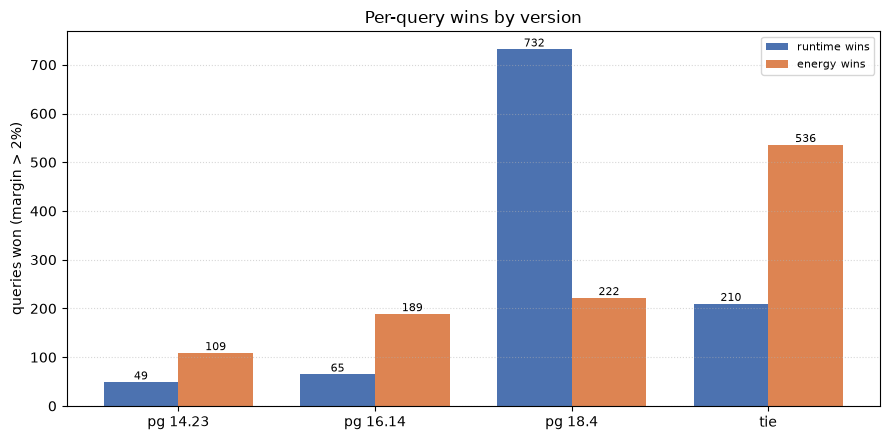

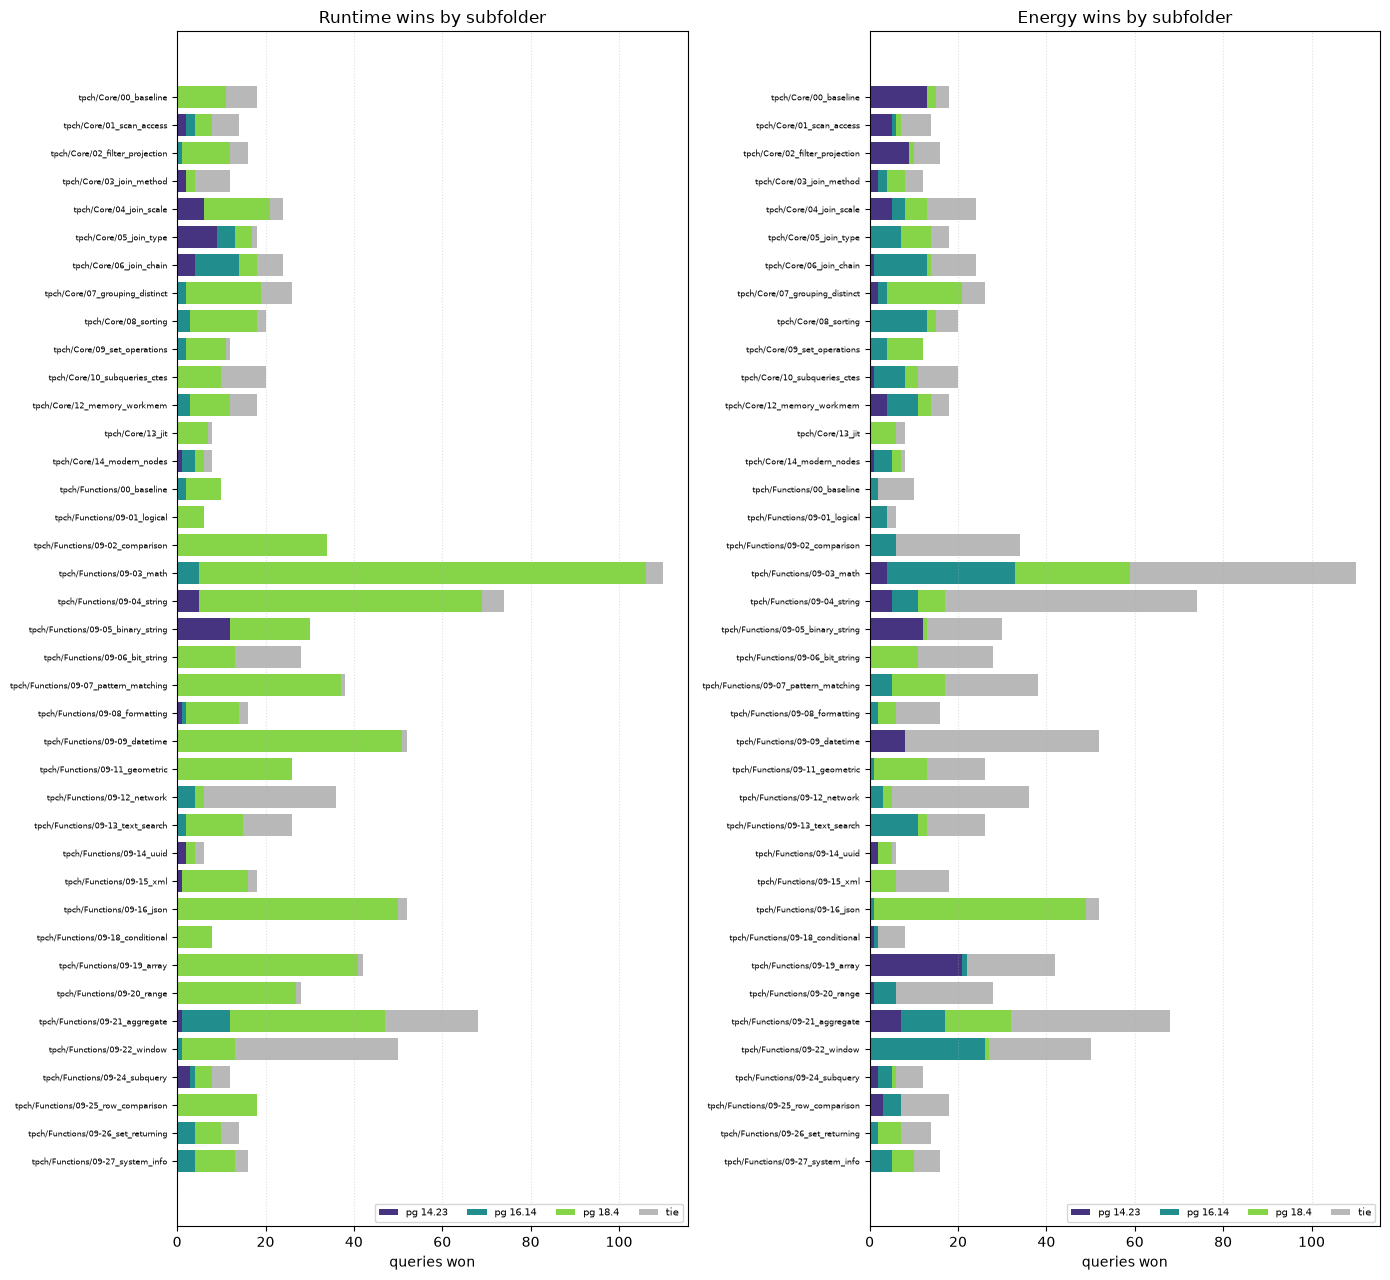

In [ ]:
# if len(VER) >= 2:
#     vcolor = dict(zip(VER, plt.cm.viridis(np.linspace(0.15, 0.82, len(VER)))))
#     vcolor["tie"] = (0.72, 0.72, 0.72, 1.0)

#     # --- overall win counts: runtime vs energy, per version (+tie) ---
#     fig, ax = plt.subplots(figsize=(9, 4.5))
#     x = np.arange(len(keys)); w = 0.38
#     rt = [int(cnt_t.get(k, 0)) for k in keys]
#     en = [int(cnt_e.get(k, 0)) for k in keys]
#     ax.bar(x - w / 2, rt, w, color="#4c72b0", label="runtime wins")
#     ax.bar(x + w / 2, en, w, color="#dd8452", label="energy wins")
#     for xi, (a, b) in enumerate(zip(rt, en)):
#         ax.text(xi - w / 2, a, str(a), ha="center", va="bottom", fontsize=8)
#         ax.text(xi + w / 2, b, str(b), ha="center", va="bottom", fontsize=8)
#     ax.set_xticks(x); ax.set_xticklabels(idx)
#     ax.set_ylabel(f"queries won (margin > {WIN_MARGIN_PCT:g}%)")
#     ax.set_title("Per-query wins by version")
#     ax.legend(fontsize=8); ax.grid(axis="y", linestyle=":", alpha=0.5)
#     fig.tight_layout(); plt.show()

#     # --- per-subfolder win breakdown (stacked counts) ---
#     def group_table(wins):
#         w = pd.DataFrame({"winner": wins})
#         w["group"] = key_group.reindex(w.index).to_numpy()
#         t = w.groupby(["group", "winner"]).size().unstack(fill_value=0)
#         cols = [v for v in VER if v in t.columns]
#         if "tie" in t.columns:
#             cols += ["tie"]
#         return t[cols]

#     gt_t, gt_e = group_table(wins_t), group_table(wins_e)
#     order_idx = gt_t.reindex(sorted(gt_t.index)).index
#     ng = len(order_idx)
#     fig, axes = plt.subplots(1, 2, figsize=(14, max(3, 0.3 * ng + 1.2)))
#     for ax, gt, title in ((axes[0], gt_t, "Runtime wins by subfolder"),
#                           (axes[1], gt_e, "Energy wins by subfolder")):
#         gt = gt.reindex(order_idx, fill_value=0)
#         y = np.arange(ng); left = np.zeros(ng)
#         for col in gt.columns:
#             vals = gt[col].to_numpy(dtype=float)
#             ax.barh(y, vals, left=left, color=vcolor[col],
#                     label=("tie" if col == "tie" else f"pg {col}"))
#             left += vals
#         ax.set_yticks(y); ax.set_yticklabels(order_idx, fontsize=6)
#         ax.invert_yaxis()                     # subfolders A->Z, top to bottom
#         ax.set_xlabel("queries won"); ax.set_title(title)
#         ax.legend(fontsize=7, ncol=len(gt.columns), loc="lower right")
#         ax.grid(axis="x", linestyle=":", alpha=0.4)
#     fig.tight_layout(); plt.show()

### 22b. Version win counts on the **cold** runs

The cold counterpart of section 22 (titled **COLD**): per-query wins by version
(with the same relative `WIN_MARGIN_PCT` tie threshold), and the per-subfolder
win breakdown.

[COLD] comparable queries: 1625 (runtime), 1625 (energy); win margin > 2%

          runtime_wins  runtime_%  energy_wins  energy_%
pg 14.23            55        3.4          125       7.7
pg 16.14           121        7.4          245      15.1
pg 18.4           1235       76.0          507      31.2
tie                214       13.2          748      46.0


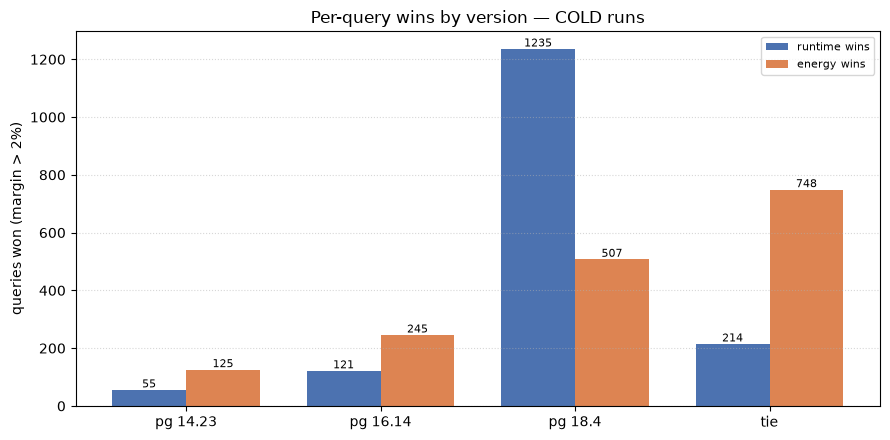

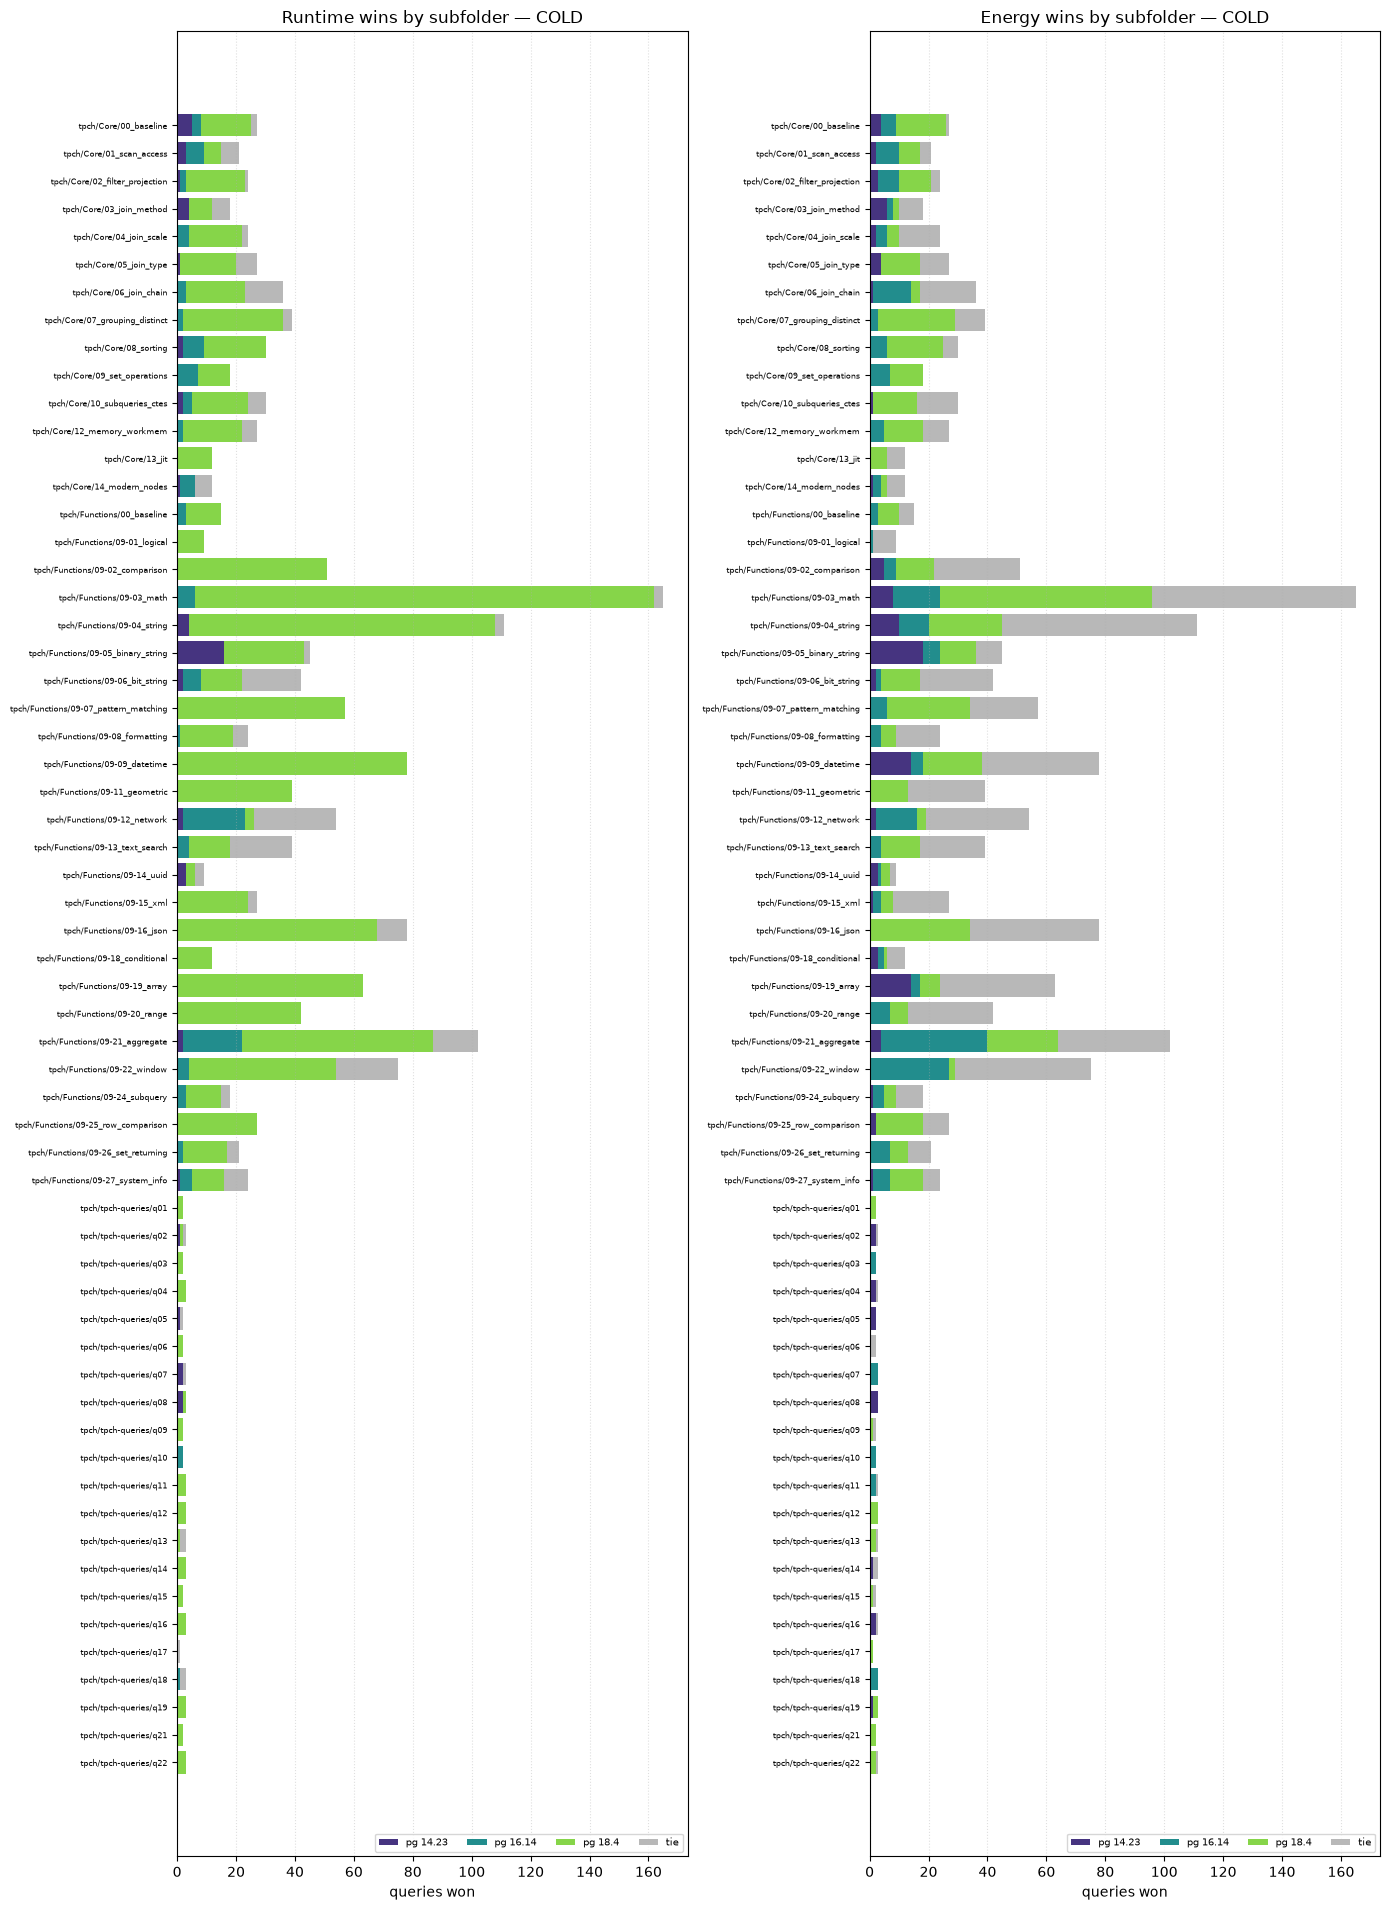

In [ ]:
# if not COLD_OK:
#     print("No cold data -> no cold win-count figures.")
# else:
#     WIN_MARGIN_PCT = 2.0
#     cdv = cold[["pg_version", "db_size", "group", "query",
#                 "avg_time_s", "avg_pkg_j"]].copy()
#     cdv = cdv.dropna(subset=["avg_time_s", "avg_pkg_j"])
#     cdv = cdv[(cdv["avg_time_s"] > 0) & (cdv["avg_pkg_j"] > 0)]

#     def _vk(v):
#         return [int(x) for x in str(v).split(".") if x.isdigit()]
#     VER = sorted(cdv["pg_version"].unique(), key=_vk)

#     if len(VER) < 2:
#         print(f"[COLD] only one version present ({VER}); nothing to compare.")
#     else:
#         KEY2 = ["query", "db_size"]
#         seen = cdv.groupby(KEY2)["pg_version"].nunique()
#         common = seen[seen == len(VER)].reset_index()[KEY2]
#         cmp2 = cdv.merge(common, on=KEY2, how="inner")
#         key_group = cmp2.drop_duplicates(KEY2).set_index(KEY2)["group"]
#         thr = 1.0 + WIN_MARGIN_PCT / 100.0
#         verarr = np.array(VER, dtype=object)

#         def decide(metric):
#             piv = cmp2.pivot_table(index=KEY2, columns="pg_version",
#                                    values=metric, aggfunc="mean").reindex(columns=VER).dropna()
#             arr = piv.to_numpy(dtype=float)
#             order = np.argsort(arr, axis=1); rows = np.arange(len(arr))
#             best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
#             winner = np.where(runner > best * thr, verarr[order[:, 0]], "tie")
#             return pd.Series(winner, index=piv.index)

#         wins_t = decide("avg_time_s"); wins_e = decide("avg_pkg_j")
#         cnt_t, cnt_e = wins_t.value_counts(), wins_e.value_counts()
#         n_t, n_e = len(wins_t), len(wins_e)
#         keys = list(VER) + ["tie"]; idx = [f"pg {v}" for v in VER] + ["tie"]
#         summ = pd.DataFrame(index=idx)
#         summ["runtime_wins"] = [int(cnt_t.get(k, 0)) for k in keys]
#         summ["runtime_%"] = (100 * summ["runtime_wins"] / n_t).round(1)
#         summ["energy_wins"] = [int(cnt_e.get(k, 0)) for k in keys]
#         summ["energy_%"] = (100 * summ["energy_wins"] / n_e).round(1)
#         print(f"[COLD] comparable queries: {n_t} (runtime), {n_e} (energy); "
#               f"win margin > {WIN_MARGIN_PCT:g}%\n")
#         print(summ.to_string())

#         vcolor = dict(zip(VER, plt.cm.viridis(np.linspace(0.15, 0.82, len(VER)))))
#         vcolor["tie"] = (0.72, 0.72, 0.72, 1.0)
#         fig, ax = plt.subplots(figsize=(9, 4.5))
#         x = np.arange(len(keys)); w = 0.38
#         rt = [int(cnt_t.get(k, 0)) for k in keys]
#         en = [int(cnt_e.get(k, 0)) for k in keys]
#         ax.bar(x - w / 2, rt, w, color="#4c72b0", label="runtime wins")
#         ax.bar(x + w / 2, en, w, color="#dd8452", label="energy wins")
#         for xi, (a, b) in enumerate(zip(rt, en)):
#             ax.text(xi - w / 2, a, str(a), ha="center", va="bottom", fontsize=8)
#             ax.text(xi + w / 2, b, str(b), ha="center", va="bottom", fontsize=8)
#         ax.set_xticks(x); ax.set_xticklabels(idx)
#         ax.set_ylabel(f"queries won (margin > {WIN_MARGIN_PCT:g}%)")
#         ax.set_title("Per-query wins by version — COLD runs")
#         ax.legend(fontsize=8); ax.grid(axis="y", linestyle=":", alpha=0.5)
#         fig.tight_layout(); plt.show()

#         def group_table(wins):
#             w = pd.DataFrame({"winner": wins})
#             w["group"] = key_group.reindex(w.index).to_numpy()
#             t = w.groupby(["group", "winner"]).size().unstack(fill_value=0)
#             cols = [v for v in VER if v in t.columns]
#             if "tie" in t.columns:
#                 cols += ["tie"]
#             return t[cols]

#         gt_t, gt_e = group_table(wins_t), group_table(wins_e)
#         order_idx = sorted(set(gt_t.index) | set(gt_e.index)); ng = len(order_idx)
#         fig, axes = plt.subplots(1, 2, figsize=(14, max(3, 0.3 * ng + 1.2)))
#         for ax, gt, title in ((axes[0], gt_t, "Runtime wins by subfolder — COLD"),
#                               (axes[1], gt_e, "Energy wins by subfolder — COLD")):
#             gt = gt.reindex(order_idx, fill_value=0)
#             y = np.arange(ng); left = np.zeros(ng)
#             for col in gt.columns:
#                 vals = gt[col].to_numpy(dtype=float)
#                 ax.barh(y, vals, left=left, color=vcolor.get(col, (0.72, 0.72, 0.72, 1.0)),
#                         label=("tie" if col == "tie" else f"pg {col}"))
#                 left += vals
#             ax.set_yticks(y); ax.set_yticklabels(order_idx, fontsize=6)
#             ax.invert_yaxis()
#             ax.set_xlabel("queries won"); ax.set_title(title)
#             ax.legend(fontsize=7, ncol=max(1, len(gt.columns)), loc="lower right")
#             ax.grid(axis="x", linestyle=":", alpha=0.4)
#         fig.tight_layout(); plt.show()